# 1\. 라이브러리 호출 및 데이터 확인

In [ ]:
!pip install koreanize-matplotlib -q
!pip install catboost -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from itertools import product
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('/content/bank_marketing.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,4,-1,0,unknown,no


In [ ]:
df.shape

(45211, 16)

- 약 4.5만 개의 고객 관측치와 16개 변수를 가진다.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  y          45211 non-null  object
dtypes: int64(6), object(10)
memory usage: 5.5+ MB


- null값이 존재하지 않는 것으로 보인다.

In [ ]:
df.describe()

,age,balance,day,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000


- age와 day는 비교적 안정적인 분포를 보였으나 balance, campaign, pdays, previous는 한쪽으로 치우친 분포를 보였다.
- 특히 campaign은 대부분의 고객이 3회 이하의 연락을 받았지만 최대 63회까지 연락한 사례가 있었고, previous 역시 대부분은 0회였지만 일부 극단적으로 큰 값이 존재하였다.

- pdays는 중앙값과 75% 지점이 모두 -1로 나타났는데 이는 대부분의 고객이 이전 캠페인에서 연락받은 적이 없다는 것을 의미한다.

# 2\. 데이터 전처리

## 2-1. 중복값 확인

In [ ]:
df.duplicated().sum()

np.int64(16)

- 중복값이 16건 있다.

In [ ]:
df[df.duplicated(keep=False)].sort_values(df.columns.tolist())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
12754,25,blue-collar,married,primary,no,0,no,no,cellular,7,jul,1,-1,0,unknown,no
12939,25,blue-collar,married,primary,no,0,no,no,cellular,7,jul,1,-1,0,unknown,no
22343,30,technician,single,tertiary,no,0,no,no,cellular,22,aug,2,-1,0,unknown,no
22418,30,technician,single,tertiary,no,0,no,no,cellular,22,aug,2,-1,0,unknown,no
22577,30,technician,single,tertiary,no,0,no,no,cellular,22,aug,2,-1,0,unknown,no
22093,31,management,single,tertiary,no,0,no,no,cellular,21,aug,2,-1,0,unknown,no
22157,31,management,single,tertiary,no,0,no,no,cellular,21,aug,2,-1,0,unknown,no
22318,32,management,single,tertiary,no,0,no,no,cellular,22,aug,2,-1,0,unknown,no
22445,32,management,single,tertiary,no,0,no,no,cellular,22,aug,2,-1,0,unknown,no
23835,32,management,single,tertiary,no,0,no,no,cellular,29,aug,2,-1,0,unknown,no


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

- 한 행이 한 고객의 한 관측치이기 때문에 중복값 16건은 제거한다.

In [ ]:
df.duplicated().sum()

np.int64(0)

## 2-2. 결측값 확인 (빈 값)

info()에서 모든 컬럼이 non-null로 나온걸 확인하여 문자열 컬럼에 빈값이 숨어있는지 확인한다.

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
blank_check = {}

for col in df.columns:
    if df[col].dtype == 'object':
        blank_count = df[col].astype(str).str.strip().eq('').sum()
        blank_check[col] = blank_count

blank_df = pd.DataFrame.from_dict(
    blank_check,
    orient='index',
    columns=['빈 문자열 개수']
)

blank_df

,빈 문자열 개수
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
poutcome,0
y,0


- 문자열 컬럼에 결측값이나 빈 값은 없다.

## 2-3. 이상치 확인

**2-3-1. 히스토그램 시각화**

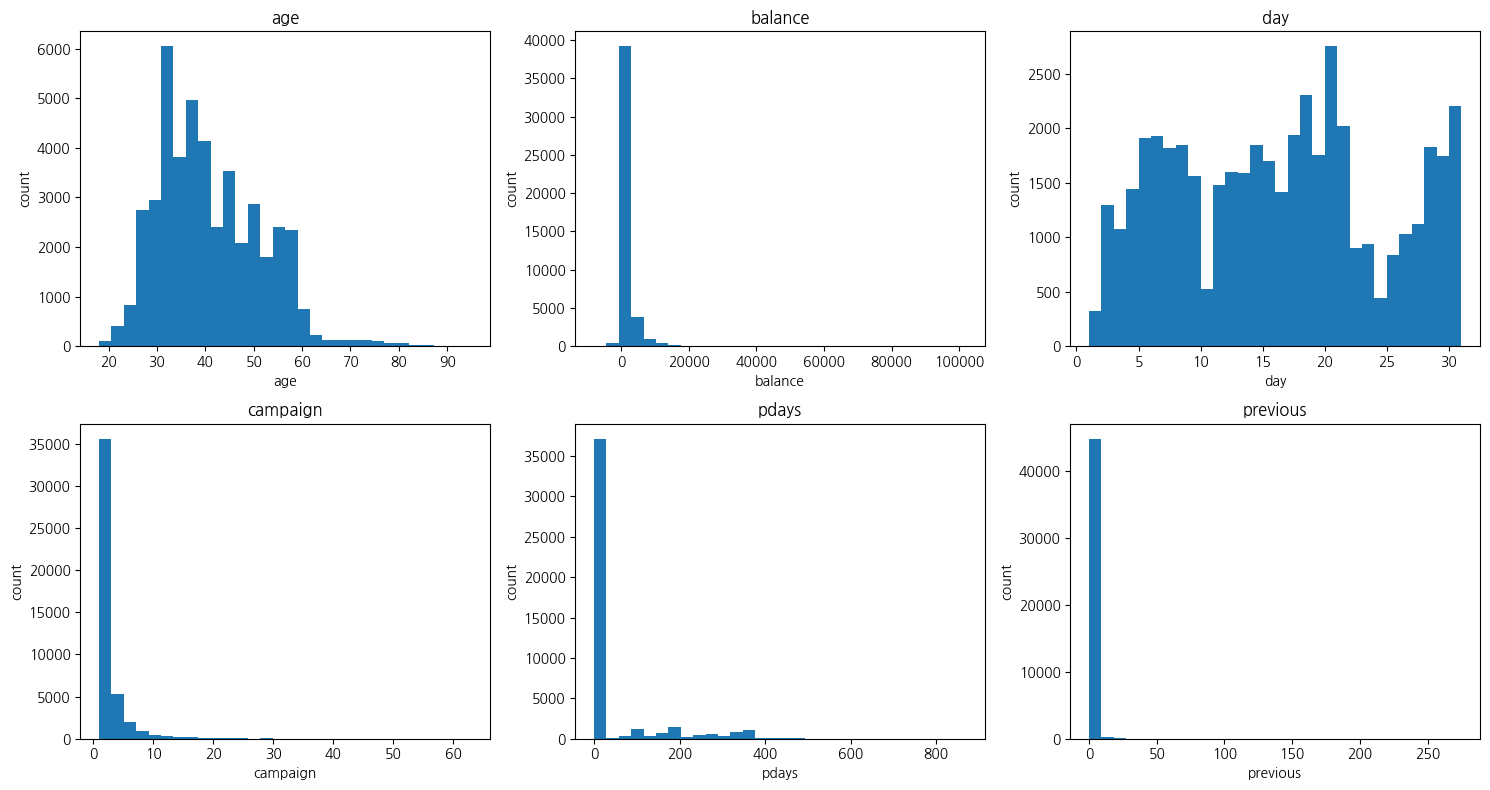

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- age
  - 고객 나이는 주로 30~50대 구간에 많이 분포되어 있다.
  - 60대 이상 고객도 일부 존재하지만 전체적으로는 중장년층 고객 비중이 높다.

- balance
  - 잔고는 낮은 값 구간에 데이터가 많이 몰려 있고, 오른쪽으로 긴 꼬리를 보인다.
  - 일부 고객의 잔고가 매우 높아 평균이 중앙값보다 크게 나타날 가능성이 있다.
  - 음수 잔고와 고액 잔고가 함께 존재하므로, 단순 평균보다는 잔고 구간별 가입률을 확인하는게 좋을 것으로 판단된다.

- day
  - 마지막 연락 일자는 1일부터 31일까지 비교적 고르게 분포되어 있다.
  - 특정 일자에만 데이터가 몰려 있지는 않지만, 월 초·중순·말에 따라 가입률 차이가 있을 수 있다.

- campaign
  - 이번 캠페인 연락 횟수는 대부분 낮은 값에 집중되어 있으며, 오른쪽으로 긴 꼬리를 보인다.
  - 대부분의 고객은 적은 횟수의 연락을 받았지만, 일부 고객은 매우 많이 연락받은 것으로 확인된다.

- pdays
  - pdays는 대부분 0 근처에 몰려 있는 것처럼 보이지만, 실제로는 -1 값이 많이 포함되어 있다. (-1은 이전 캠페인에서 연락한 적이 없다는 의미)

- previous
  - previous는 대부분 0에 집중되어 있어, 이전 캠페인에서 연락받은 적이 없는 고객이 많다.
  - 일부 고객은 이전 캠페인에서 매우 많이 연락받은 이력이 있어 오른쪽으로 긴 꼬리를 보인다.

**2-3-2. 박스 플롯 시각화**

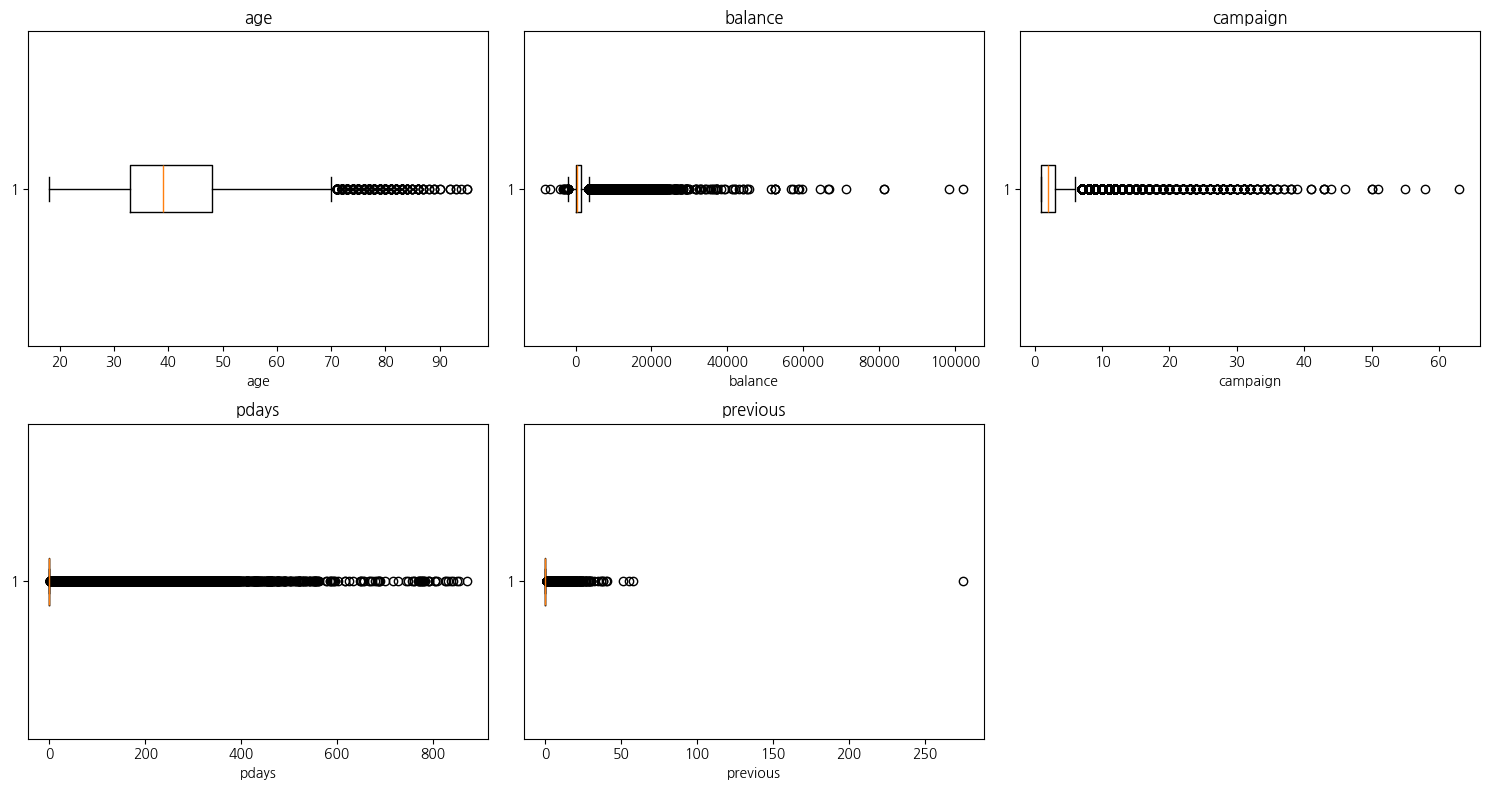

In [ ]:
continuous_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']

n_cols = 3
n_rows = int(np.ceil(len(continuous_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- age
  - 대부분의 고객은 30~50대 구간에 분포해 있다.
  - 70대 이상 고령 고객은 박스플롯상 이상치처럼 나타나지만, 실제 고객 연령으로 가능한 값이므로 제거 대상은 아니다.

- balance
  - 대부분의 고객은 낮은 잔고 구간에 몰려 있지만, 일부 고객은 매우 높은 잔고를 보유하고 있어 이상치가 많이 나타났다.
  - 잔고는 고객의 금융 상태를 나타내는 중요한 변수이므로 단순히 이상치라고 제거하기보다는 그대로 유지하고, 필요 시 구간화하여 분석하는 것이 적절하다 판단된다.
- campaign
  - 대부분의 고객은 적은 횟수의 연락을 받았지만, 일부 고객은 매우 많은 연락을 받은 것으로 나타났다.
  - campaign의 큰 값은 이상치처럼 보이지만, 실제 캠페인에서 반복적으로 연락한 이력일 수 있으므로 무조건 제거하기는 어렵다고 판단된다.

- pdays
  - pdays는 대부분 낮은 값에 몰려 있고, 일부 큰 값이 이상치처럼 나타난다.

- previous
  - previous는 대부분 0에 집중되어 있으며, 일부 고객에게서 큰 값이 나타난다.
  - 이는 대부분의 고객이 이전 캠페인 접촉 이력이 없고, 일부 고객만 여러 번 연락받았음을 의미하므로 제거보다는 이전 연락 경험 여부와 연락 횟수 구간을 나누어 가입률을 확인하는 것이 적절하다고 본다.

## 2-4. 정의되지 않은 값 확인(범주형 컬럼)

각 범주형 변수의 실제 unique 값과 명세상 정의된 값을 비교하여, 정의되지 않은 값이 존재하는지 확인한다.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

cat_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [ ]:
for col in cat_cols:
    print(f'[{col}]')
    print('고유값 개수:', df[col].nunique())
    print('고유값:', df[col].unique())
    print('-' * 80)

[job]
고유값 개수: 12
고유값: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
--------------------------------------------------------------------------------
[marital]
고유값 개수: 3
고유값: ['married' 'single' 'divorced']
--------------------------------------------------------------------------------
[education]
고유값 개수: 4
고유값: ['tertiary' 'secondary' 'unknown' 'primary']
--------------------------------------------------------------------------------
[default]
고유값 개수: 2
고유값: ['no' 'yes']
--------------------------------------------------------------------------------
[housing]
고유값 개수: 2
고유값: ['yes' 'no']
--------------------------------------------------------------------------------
[loan]
고유값 개수: 2
고유값: ['no' 'yes']
--------------------------------------------------------------------------------
[contact]
고유값 개수: 3
고유값: ['unknown' 'cellular' 'telephone']
------------------------------------------

- 데이터 명세에 있는 범주들이 들어 있으며, 일부 컬럼에는 unknown 값이 존재한다.

In [ ]:
for col in cat_cols:
    print(f'[{col}]')
    print(df[col].value_counts(dropna=False))
    print('-' * 80)

[job]
job
blue-collar      9730
management       9451
technician       7593
admin.           5171
services         4152
retired          2263
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
--------------------------------------------------------------------------------
[marital]
marital
married     27208
single      12780
divorced     5207
Name: count, dtype: int64
--------------------------------------------------------------------------------
[education]
education
secondary    23199
tertiary     13291
primary       6848
unknown       1857
Name: count, dtype: int64
--------------------------------------------------------------------------------
[default]
default
no     44380
yes      815
Name: count, dtype: int64
--------------------------------------------------------------------------------
[housing]
housing
yes    25126
no     20069
Name: count, dtype: int64
--------------

- job
  - 직업은 총 12개 범주로 구성되어 있다.
  - blue-collar, management, technician, admin. 순으로 데이터 수가 많다.
  - unknown 값이 288건 존재한다. (전체 비중은 크지 않으므로 삭제하지 않고 하나의 범주로 유지)
- marital
  - 결혼 상태는 married, single, divorced 3개 범주로 구성되어 있다.
  - married가 가장 많고, 그다음으로 single, divorced 순서이다.
  - 별도의 unknown 값은 없다.

- education
  - 교육 수준은 secondary, tertiary, primary, unknown 4개 범주로 구성되어 있다.
  - secondary가 가장 많고, 그다음으로 tertiary, primary 순서이다.
  - unknown 값이 1,857건 존재한다. (교육 정보가 확인되지 않은 고객을 의미할 수 있으므로 삭제하지 않고 하나의 범주로 유지)

- default
  - 채무 불이행 여부는 yes, no 2개 범주로 구성되어 있다.
  - 대부분의 고객은 default=no이며, yes는 매우 적다.

- housing
  - 주택 담보 대출 여부는 yes, no 2개 범주로 구성되어 있다.
  - yes가 no보다 조금 더 많다.

- loan
  - 개인 대출 여부는 yes, no 2개 범주로 구성되어 있다.
  - 대부분의 고객은 개인 대출이 없으며, yes는 상대적으로 적다.

- contact
  - 연락 수단은 cellular, telephone, unknown 3개 범주로 구성되어 있다.
  - cellular가 가장 많지만, unknown도 13,018건으로 상당히 많다. (단순 결측이라기보다 연락 수단 정보가 확인되지 않은 상태일 수 있으므로 삭제하지 않고 유지)

- month
  - 마지막 연락 월은 12개월 모두 포함되어 있다.
  - may, jul, aug, jun 순으로 데이터 수가 많고, dec, mar, sep, oct는 상대적으로 적다.

- poutcome
  - 이전 캠페인 결과는 unknown, failure, other, success 4개 범주로 구성되어 있다.
  - unknown이 36,943건으로 대부분을 차지한다. (이전 캠페인 접촉 이력이 없거나 결과가 확인되지 않은 고객이 많다는 것을 의미할 수 있다.)

- y
  - 타깃 변수는 yes, no 2개 범주로 구성되어 있다.
  - no가 39,906건, yes가 5,289건으로 비가입자 비중이 훨씬 높다.

## 2-5. 파생변수 생성

**2-5-1. 타깃 변수 변환**

In [ ]:
df['target'] = df['y'].map({'no': 0, 'yes': 1})

df[['y', 'target']].head()

,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


- 타깃 변수 y를 no=0, yes=1인 숫자형 변수 target으로 변환한다.

In [ ]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
0    39906
1     5289
Name: count, dtype: int64
target
0    88.297378
1    11.702622
Name: proportion, dtype: float64


- 비가입자 39,906명, 가입자 5,289명으로 가입자 비율은 약 11.7%이다.
- 타깃 불균형이 뚜렷하므로 모델 평가는 Accuracy만 보면 안 되고 가입자 F1-score를 함께 봐야 한다.

**2-5-2. month 숫자형 변수 생성**

In [ ]:
month_map = {
    'jan': 1,
    'feb': 2,
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}

df['month_num'] = df['month'].map(month_map)

df[['month', 'month_num']].head()

,month,month_num
0,may,5
1,may,5
2,may,5
3,may,5
4,may,5


- 문자형 월을 숫자형 월로 변환한다.

**2-5-3. 분기 변수 생성**

In [ ]:
def get_quarter(month_num):
    if month_num in [1, 2, 3]:
        return 'Q1'
    elif month_num in [4, 5, 6]:
        return 'Q2'
    elif month_num in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

df['quarter'] = df['month_num'].apply(get_quarter)

df[['month', 'month_num', 'quarter']].head()

,month,month_num,quarter
0,may,5,Q2
1,may,5,Q2
2,may,5,Q2
3,may,5,Q2
4,may,5,Q2


- 1\~3월은 Q1, 4\~6월은 Q2, 7\~9월은 Q3, 10\~12월은 Q4로 분류한다.

**2-5-4. age_group 생성**

In [ ]:
age_bins = [17, 29, 39, 49, 59, 69, 100]
age_labels = ['18-29', '30s', '40s', '50s', '60s', '70+']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels
)

df['age_group'].value_counts().sort_index()

,count
age_group,
18-29,5272
30s,18079
40s,11651
50s,8409
60s,1230
70+,554


- 나이를 18-29, 30대, 40대, 50대, 60대, 70대 이상으로 구간화한다.
- 30대와 40대 고객 수가 가장 많고, 60대 이상은 상대적으로 적다.

**2-5-5. balance_group 생성**

In [ ]:
df['balance_group'] = pd.cut(
    df['balance'],
    bins=[-10000, 0, 500, 1500, 5000, 110000],
    labels=['negative_or_zero', 'low', 'middle', 'high', 'very_high']
)

df['balance_group'].value_counts().sort_index()

,count
balance_group,
negative_or_zero,7264
low,16385
middle,10651
high,8050
very_high,2845


- 연평균 잔고를 음수/0, 낮음, 중간, 높음, 매우 높음 구간으로 나눈다.
- 잔고가 낮은 고객 수가 가장 많고, 매우 높은 잔고 고객은 적다.

**2-5-6. campaign_group 생성**

In [ ]:
df['campaign_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 5, 10, 100],
    labels=['1', '2', '3', '4-5', '6-10', '11+']
)

df['campaign_group'].value_counts().sort_index()

,count
campaign_group,
1,17539
2,12497
3,5520
4-5,5285
6-10,3158
11+,1196


- 현재 캠페인 연락 횟수를 1회, 2회, 3회, 4~5회, 6~10회, 11회 이상으로 구간화한다.
- 1~2회 연락받은 고객이 대부분이다.

**2-5-7. (6회 이상) 연락 여부 변수 생성**

In [ ]:
df['is_high_campaign'] = np.where(df['campaign'] >= 6, 1, 0)

df['is_high_campaign'].value_counts()

,count
is_high_campaign,
0,40841
1,4354


- 현재 캠페인에서 6회 이상 연락받은 고객을 is_high_campaign=1, 그 외는 0으로 표시한다.
- 과도한 연락 여부가 가입률에 부정적인지 확인하기 위한 파생변수이다.


**2-5-8. pdays 관련 파생변수 생성**

In [ ]:
df['has_previous_contact'] = np.where(df['pdays'] == -1, 0, 1)

df['pdays_clean'] = df['pdays'].replace(-1, np.nan)

df['pdays_for_model'] = df['pdays_clean'].fillna(0)

df[['pdays', 'has_previous_contact', 'pdays_clean', 'pdays_for_model']].head()

,pdays,has_previous_contact,pdays_clean,pdays_for_model
0,-1,0,NaN,0.0
1,-1,0,NaN,0.0
2,-1,0,NaN,0.0
3,-1,0,NaN,0.0
4,-1,0,NaN,0.0


- pdays=-1을 이전 캠페인 연락 없음으로 해석해 has_previous_contact를 만든다.
- EDA용으로는 -1을 NaN 처리한 pdays_clean, 모델링용으로는 0으로 채운 pdays_for_model을 만든다.

In [ ]:
def make_pdays_group(x):
    if x == -1:
        return 'not_contacted'
    elif x <= 30:
        return 'within_30d'
    elif x <= 90:
        return '31-90d'
    elif x <= 180:
        return '91-180d'
    elif x <= 365:
        return '181-365d'
    else:
        return 'over_365d'

df['pdays_group'] = df['pdays'].apply(make_pdays_group)

df['pdays_group'].value_counts()

,count
pdays_group,
not_contacted,36938
181-365d,4416
91-180d,2480
over_365d,643
31-90d,530
within_30d,188


- 이전 연락 후 경과일 pdays를 연락 없음, 30일 이내, 31\~90일, 91\~180일, 181\~365일, 365일 초과로 구간화한다.

- 대부분은 not_contacted이며, 이전에 연락받은 고객은 소수이다.

**2-5-9. previous 관련 파생변수 생성**

In [ ]:
df['previous_group'] = pd.cut(
    df['previous'],
    bins=[-1, 0, 1, 2, 5, 300],
    labels=['0', '1', '2', '3-5', '6+']
)

df['previous_group'].value_counts().sort_index()

,count
previous_group,
0,36938
1,2772
2,2106
3-5,2315
6+,1064


- 이전 캠페인 연락 횟수를 0회, 1회, 2회, 3~5회, 6회 이상으로 구간화한다.
- 대부분의 고객은 이전 연락 횟수가 0회이다.

**2-5-10. 이전 캠페인 성공 여부 변수**

In [ ]:
df['was_previous_success'] = np.where(df['poutcome'] == 'success', 1, 0)

df['was_previous_success'].value_counts()

,count
was_previous_success,
0,43684
1,1511


- 이전 캠페인 결과가 success였는지를 1/0으로 변환한다.

- 이전 캠페인 성공 고객은 1,511명으로 적지만, 가입 가능성이 높은 핵심 고객군일 수 있다.

**2-5-11. 대출 보유 개수 변수**

In [ ]:
df['housing_num'] = df['housing'].map({'no': 0, 'yes': 1})
df['loan_num'] = df['loan'].map({'no': 0, 'yes': 1})
df['default_num'] = df['default'].map({'no': 0, 'yes': 1})

df['loan_count'] = df['housing_num'] + df['loan_num']

df[['housing', 'loan', 'default', 'housing_num', 'loan_num', 'default_num', 'loan_count']].head()

,housing,loan,default,housing_num,loan_num,default_num,loan_count
0,yes,no,no,1,0,0,1
1,yes,no,no,1,0,0,1
2,yes,yes,no,1,1,0,2
3,yes,no,no,1,0,0,1
4,no,no,no,0,0,0,0


- 주택담보대출, 개인대출, 디폴트 여부를 숫자형으로 바꾸고 주택담보대출과 개인대출 보유 개수를 합친다.

**2-5-12. 금융 부담 그룹 생성**

In [ ]:
def make_debt_group(row):
    if row['default'] == 'yes':
        return 'default'
    elif row['housing'] == 'yes' and row['loan'] == 'yes':
        return 'housing_and_loan'
    elif row['housing'] == 'yes':
        return 'housing_only'
    elif row['loan'] == 'yes':
        return 'loan_only'
    else:
        return 'no_debt'

df['debt_group'] = df.apply(make_debt_group, axis=1)

df['debt_group'].value_counts()

,count
debt_group,
housing_only,20457
no_debt,16980
housing_and_loan,4234
loan_only,2709
default,815


- 디폴트 여부와 대출 조합을 기준으로 고객의 금융 부담 상태를 debt_group으로 분류한다.
- housing_only와 no_debt 고객이 대부분이다.

**2-5-13. 고객 생애단계 변수**

In [ ]:
def make_life_stage(row):
    if row['job'] == 'student':
        return 'student'
    elif row['job'] == 'retired':
        return 'retired'
    elif row['age'] < 30:
        return 'young_adult'
    elif row['age'] < 60:
        return 'working_age'
    else:
        return 'senior'

df['life_stage'] = df.apply(make_life_stage, axis=1)

df['life_stage'].value_counts()

,count
life_stage,
working_age,36748
young_adult,4552
retired,2263
student,938
senior,694


- 직업과 나이를 활용해 학생, 은퇴자, 청년층, 경제활동층, 고령층으로 나눈다.
- 대부분 working_age에 해당한다.

## 2-6. 최종 전처리 확인

In [ ]:
new_cols = [
    'target',
    'month_num',
    'quarter',
    'age_group',
    'balance_group',
    'campaign_group',
    'is_high_campaign',
    'has_previous_contact',
    'pdays_clean',
    'pdays_for_model',
    'pdays_group',
    'previous_group',
    'was_previous_success',
    'housing_num',
    'loan_num',
    'default_num',
    'loan_count',
    'debt_group',
    'life_stage'
]

df[new_cols].head()

,target,month_num,quarter,age_group,balance_group,campaign_group,is_high_campaign,has_previous_contact,pdays_clean,pdays_for_model,pdays_group,previous_group,was_previous_success,housing_num,loan_num,default_num,loan_count,debt_group,life_stage
0,0,5,Q2,50s,high,1,0,0,NaN,0.0,not_contacted,0,0,1,0,0,1,housing_only,working_age
1,0,5,Q2,40s,low,1,0,0,NaN,0.0,not_contacted,0,0,1,0,0,1,housing_only,working_age
2,0,5,Q2,30s,low,1,0,0,NaN,0.0,not_contacted,0,0,1,1,0,2,housing_and_loan,working_age
3,0,5,Q2,40s,high,1,0,0,NaN,0.0,not_contacted,0,0,1,0,0,1,housing_only,working_age
4,0,5,Q2,30s,low,1,0,0,NaN,0.0,not_contacted,0,0,0,0,0,0,no_debt,working_age


In [ ]:
df[new_cols].isnull().sum()

,0
target,0
month_num,0
quarter,0
age_group,0
balance_group,0
campaign_group,0
is_high_campaign,0
has_previous_contact,0
pdays_clean,36938
pdays_for_model,0


- pdays_clean에 결측이 많은 것은 오류가 아니라 이전 연락이 없는 고객을 NaN으로 표시했기 때문이다.

In [ ]:
df.shape

(45195, 35)

- 파생변수가 추가되어 컬럼 수가 늘어났다.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45195 entries, 0 to 45194
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   45195 non-null  int64   
 1   job                   45195 non-null  object  
 2   marital               45195 non-null  object  
 3   education             45195 non-null  object  
 4   default               45195 non-null  object  
 5   balance               45195 non-null  int64   
 6   housing               45195 non-null  object  
 7   loan                  45195 non-null  object  
 8   contact               45195 non-null  object  
 9   day                   45195 non-null  int64   
 10  month                 45195 non-null  object  
 11  campaign              45195 non-null  int64   
 12  pdays                 45195 non-null  int64   
 13  previous              45195 non-null  int64   
 14  poutcome              45195 non-null  object  
 15  y 

In [ ]:
df.describe()

,age,balance,day,campaign,pdays,previous,target,month_num,is_high_campaign,has_previous_contact,pdays_clean,pdays_for_model,was_previous_success,housing_num,loan_num,default_num,loan_count
count,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,8257.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000
mean,40.937604,1362.754331,15.804824,2.763978,40.212413,0.580529,0.117026,6.144197,0.096338,0.182697,224.577692,41.029716,0.033433,0.555946,0.160283,0.018033,0.716230
std,10.619108,3045.196838,8.322816,3.098304,100.143468,2.303823,0.321455,2.408264,0.295058,0.386422,115.344035,99.807294,0.179766,0.496866,0.366873,0.133072,0.629686
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,449.000000,16.000000,2.000000,-1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,194.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,0.000000,8.000000,0.000000,0.000000,327.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,1.000000,12.000000,1.000000,1.000000,871.000000,871.000000,1.000000,1.000000,1.000000,1.000000,2.000000


# 3\. EDA

## 3-1. 타깃 변수 분포 확인

In [ ]:
target_count = df['target'].value_counts().sort_index()
target_rate = df['target'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'count': target_count,
    'rate(%)': target_rate
})

target_summary

,count,rate(%)
target,,
0,39906,88.297378
1,5289,11.702622


- 비가입자는 39,906명으로 88.3%, 가입자는 5,289명으로 11.7%이다.

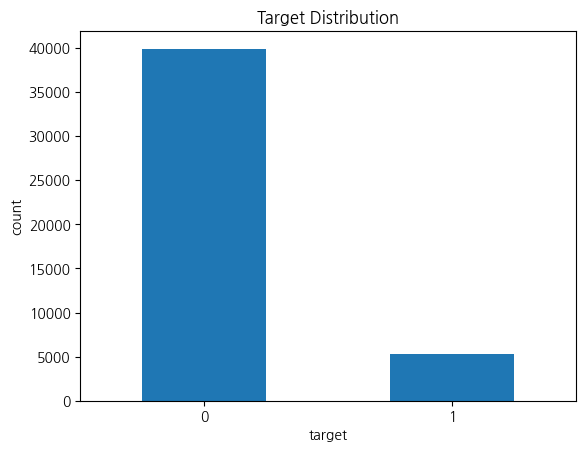

In [ ]:
target_count.plot(kind='bar')

plt.title('Target Distribution')
plt.xlabel('target')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

## 3-2. 수치형 변수 기본 분포 확인

In [ ]:
numeric_cols = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous',
    'month_num',
    'loan_count',
    'pdays_for_model'
]

numeric_cols = [col for col in numeric_cols if col in df.columns]

df[numeric_cols].describe()

,age,balance,day,campaign,pdays,previous,month_num,loan_count,pdays_for_model
count,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000
mean,40.937604,1362.754331,15.804824,2.763978,40.212413,0.580529,6.144197,0.716230,41.029716
std,10.619108,3045.196838,8.322816,3.098304,100.143468,2.303823,2.408264,0.629686,99.807294
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,5.000000,0.000000,0.000000
50%,39.000000,449.000000,16.000000,2.000000,-1.000000,0.000000,6.000000,1.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,8.000000,1.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,12.000000,2.000000,871.000000


- balance, campaign, pdays, previous는 평균과 중앙값 차이가 크다.
- 이 변수들은 정규분포보다는 한쪽으로 치우친 분포를 보이므로 단순 평균 비교만으로 해석하면 위험하다.

In [ ]:
df[numeric_cols].skew().sort_values(ascending=False)

,0
previous,41.840198
balance,8.359274
campaign,4.898646
pdays_for_model,2.621109
pdays,2.615075
age,0.684684
loan_count,0.306909
month_num,0.243319
day,0.093451


- previous, balance, campaign의 왜도가 크게 나타난다.
- 대부분의 고객은 값이 낮지만 일부 고객이 매우 큰 값을 가져 분포를 끌어올리고 있다는 뜻이다.

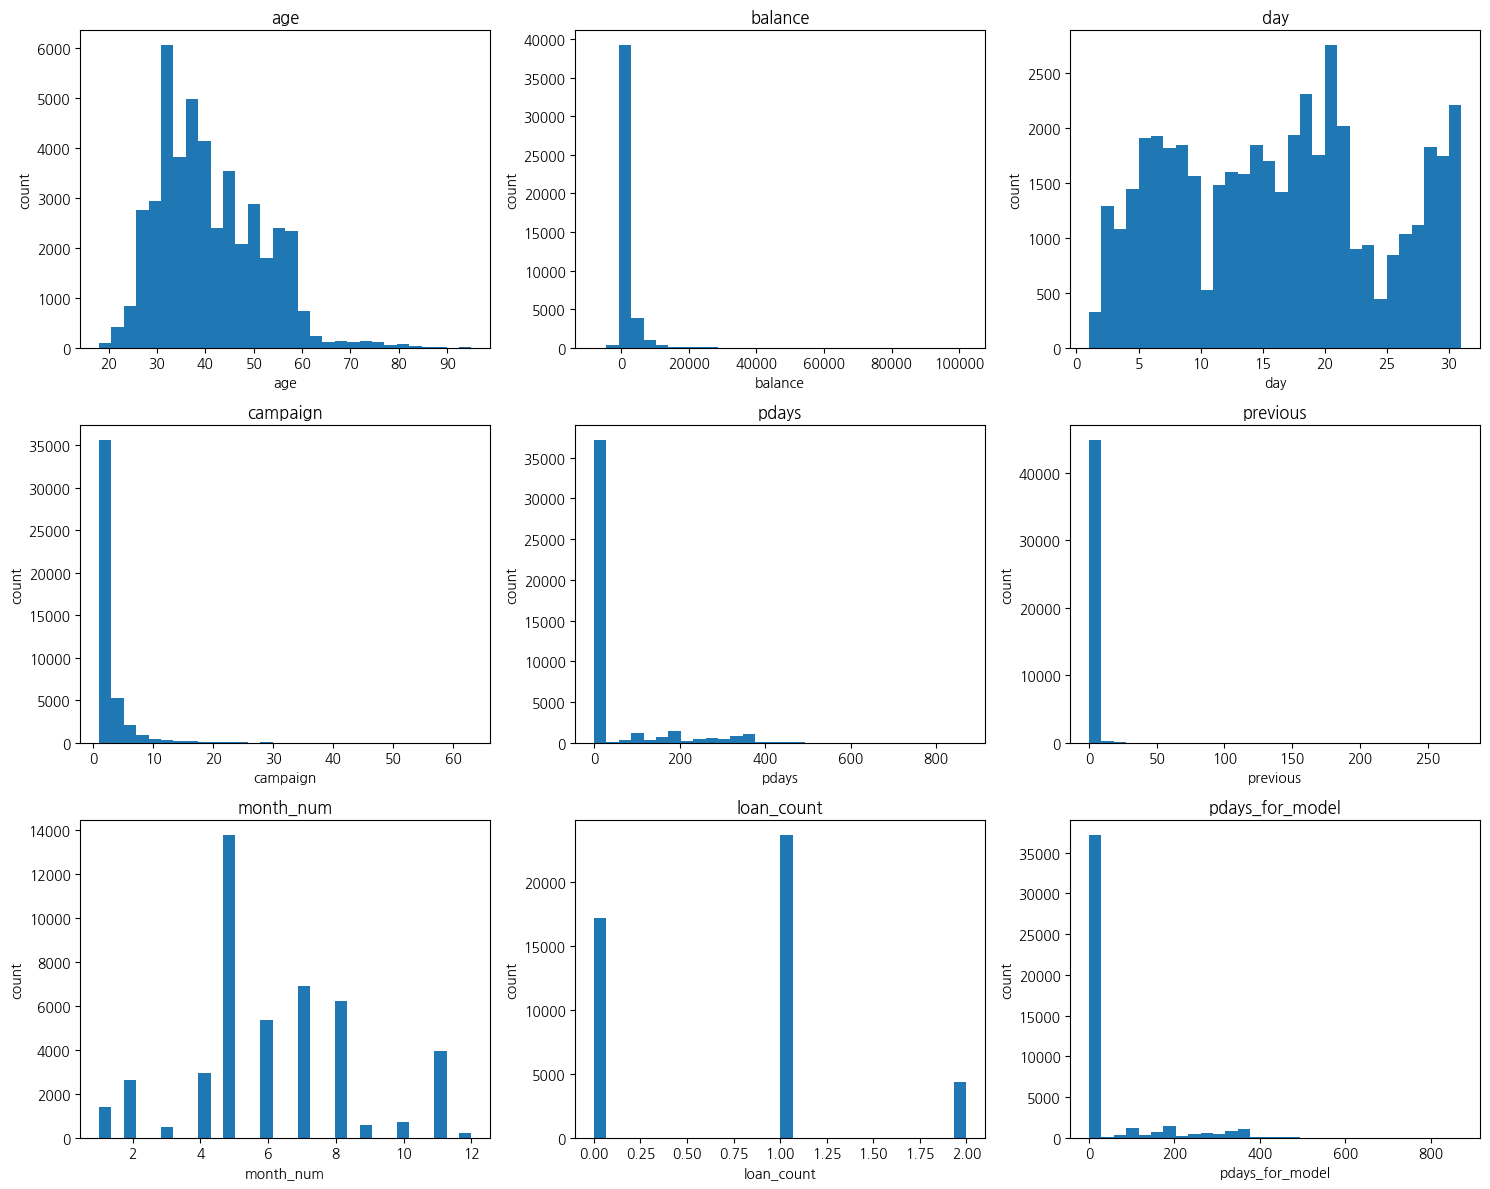

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- 많은 수치형 변수가 낮은 값에 몰려 있다.
- 특히 previous와 campaign은 대부분 적은 횟수에 집중되어 있어 구간화 분석이 필요하다.

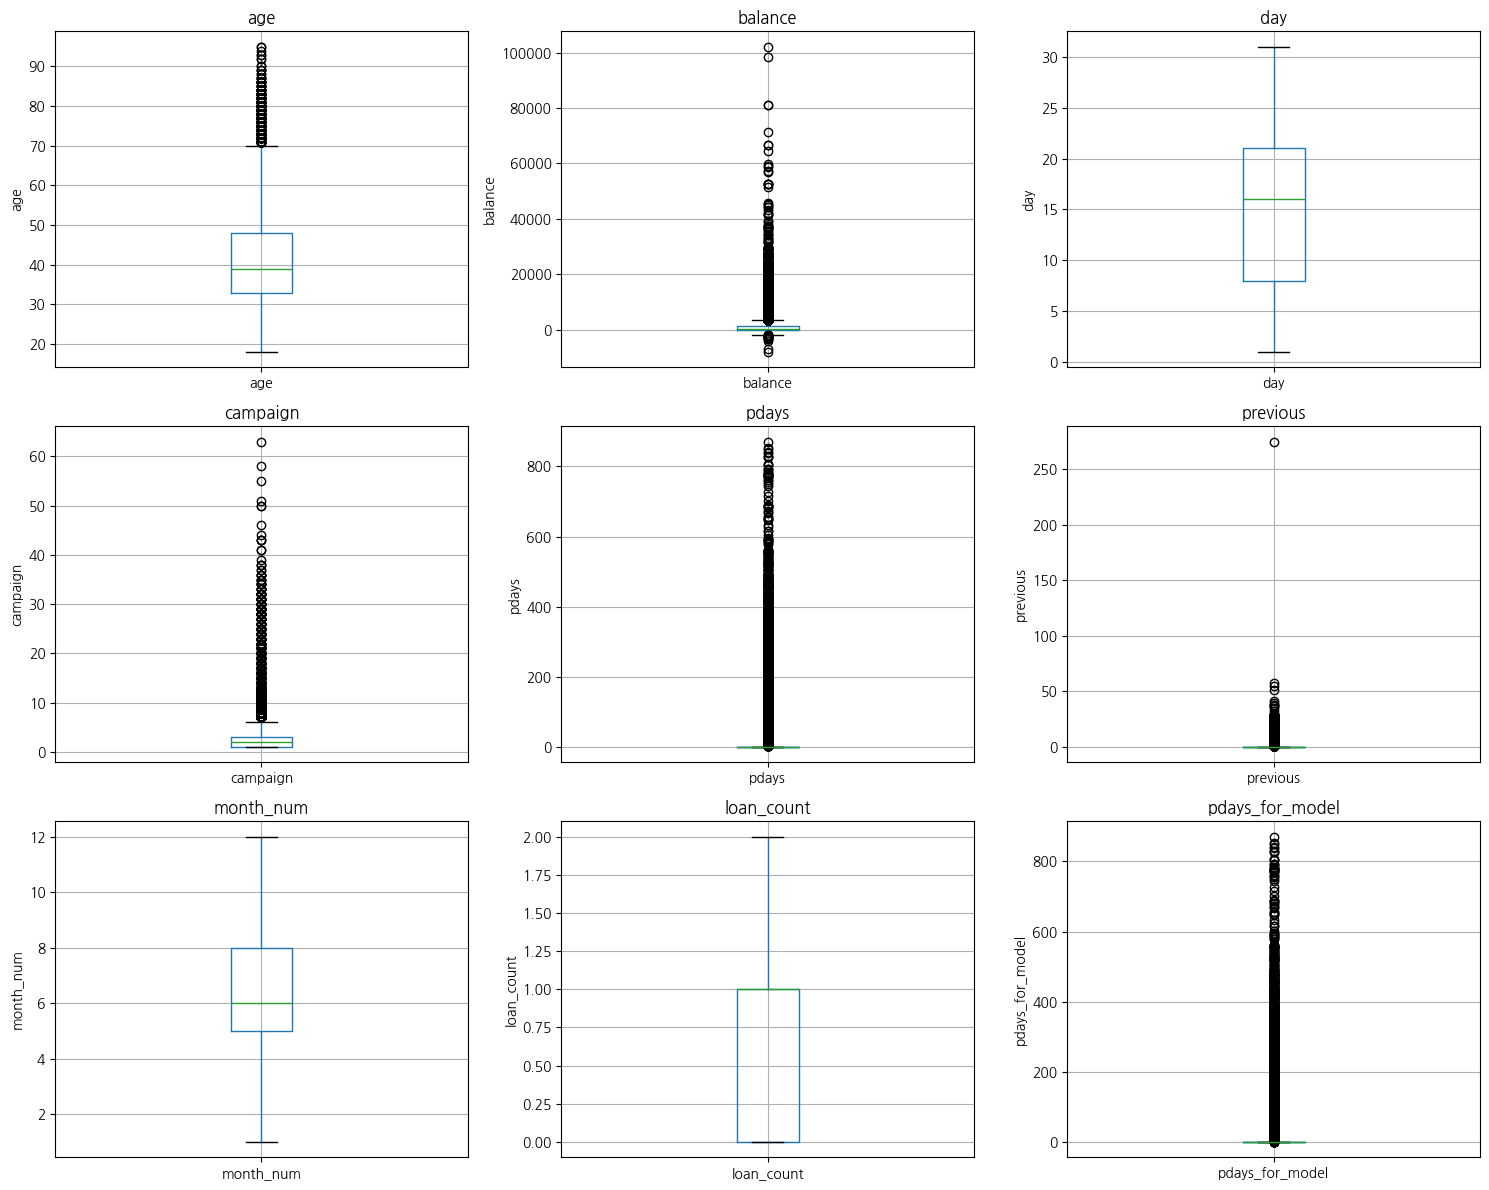

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- balance, campaign, previous에서 이상치처럼 보이는 값이 많다.
- 하지만 실제 금융/연락 데이터에서 가능한 값이므로 제거보다 파생변수화가 더 적절하다.

## 3-3. 가입 여부별 수치형 변수 비교

In [ ]:
df.groupby('target')[numeric_cols].agg(['mean', 'median'])

age             balance               day         campaign  \
             mean median         mean median       mean median      mean   
target                                                                     
0       40.840525   39.0  1304.237684  417.0  15.890518   16.0  2.846539   
1       41.670070   38.0  1804.267915  733.0  15.158253   15.0  2.141047   

                   pdays         previous        month_num        loan_count  \
       median       mean median      mean median      mean median       mean   
target                                                                         
0         2.0  36.436375   -1.0  0.502356    0.0  6.127725    6.0   0.750539   
1         2.0  68.702968   -1.0  1.170354    0.0  6.268482    6.0   0.457364   

              pdays_for_model         
       median            mean median  
target                                
0         1.0       37.277201    0.0  
1         0.0       69.342787    0.0

- 가입자는 비가입자보다 평균 잔고와 이전 캠페인 관련 값이 높은 편이고, 현재 캠페인 연락 횟수는 낮은 편이다.
- 즉, 이전에 반응한 고객과 과도하게 연락받지 않은 고객이 가입 가능성이 높아 보인다.

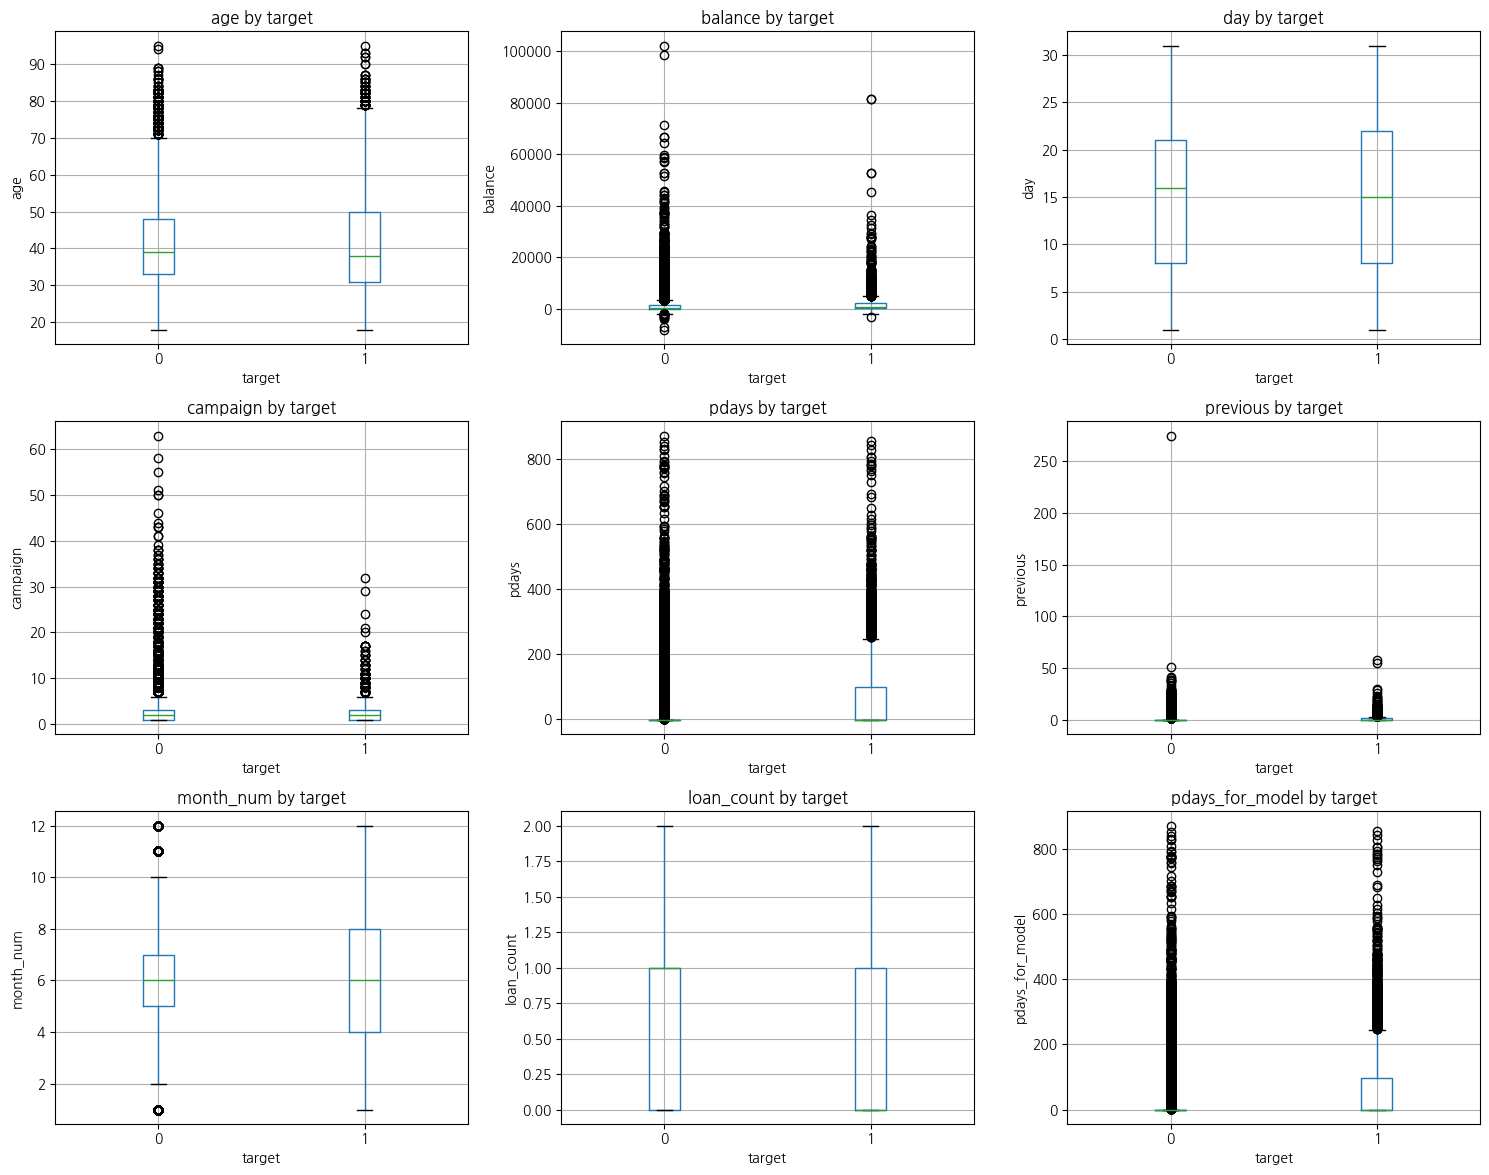

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col + ' by target')
    axes[i].set_xlabel('target')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('')
plt.tight_layout()
plt.show()

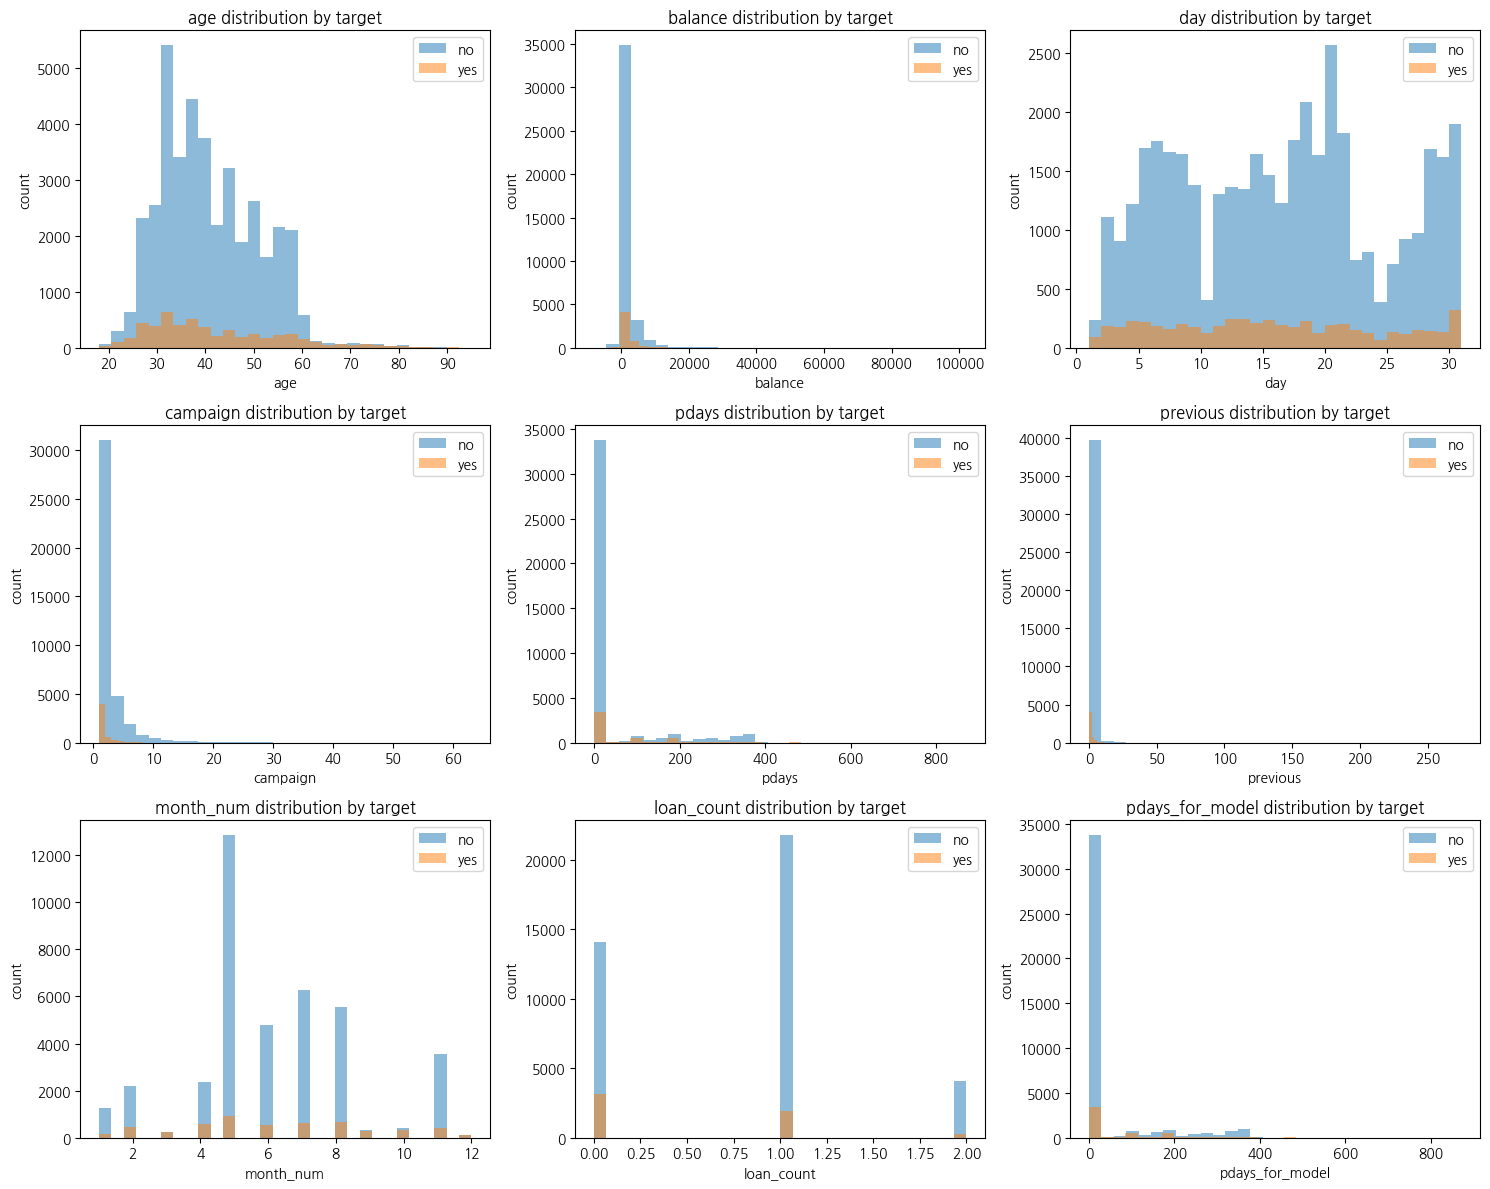

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[df['target'] == 0][col], bins=30, alpha=0.5, label='no')
    axes[i].hist(df[df['target'] == 1][col], bins=30, alpha=0.5, label='yes')
    axes[i].set_title(col + ' distribution by target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 3-4. 범주형 변수 분포 확인

In [ ]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'quarter',
    'age_group',
    'balance_group',
    'campaign_group',
    'pdays_group',
    'previous_group',
    'debt_group',
    'life_stage'
]

categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in categorical_cols:
    print('[' + col + ']')
    print(df[col].value_counts())
    print('-' * 60)

[job]
job
blue-collar      9730
management       9451
technician       7593
admin.           5171
services         4152
retired          2263
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
------------------------------------------------------------
[marital]
marital
married     27208
single      12780
divorced     5207
Name: count, dtype: int64
------------------------------------------------------------
[education]
education
secondary    23199
tertiary     13291
primary       6848
unknown       1857
Name: count, dtype: int64
------------------------------------------------------------
[default]
default
no     44380
yes      815
Name: count, dtype: int64
------------------------------------------------------------
[housing]
housing
yes    25126
no     20069
Name: count, dtype: int64
------------------------------------------------------------
[loan]
loan
no     37951
yes     

- 일부 범주는 표본 수가 매우 작고, 일부 범주는 대부분을 차지한다.

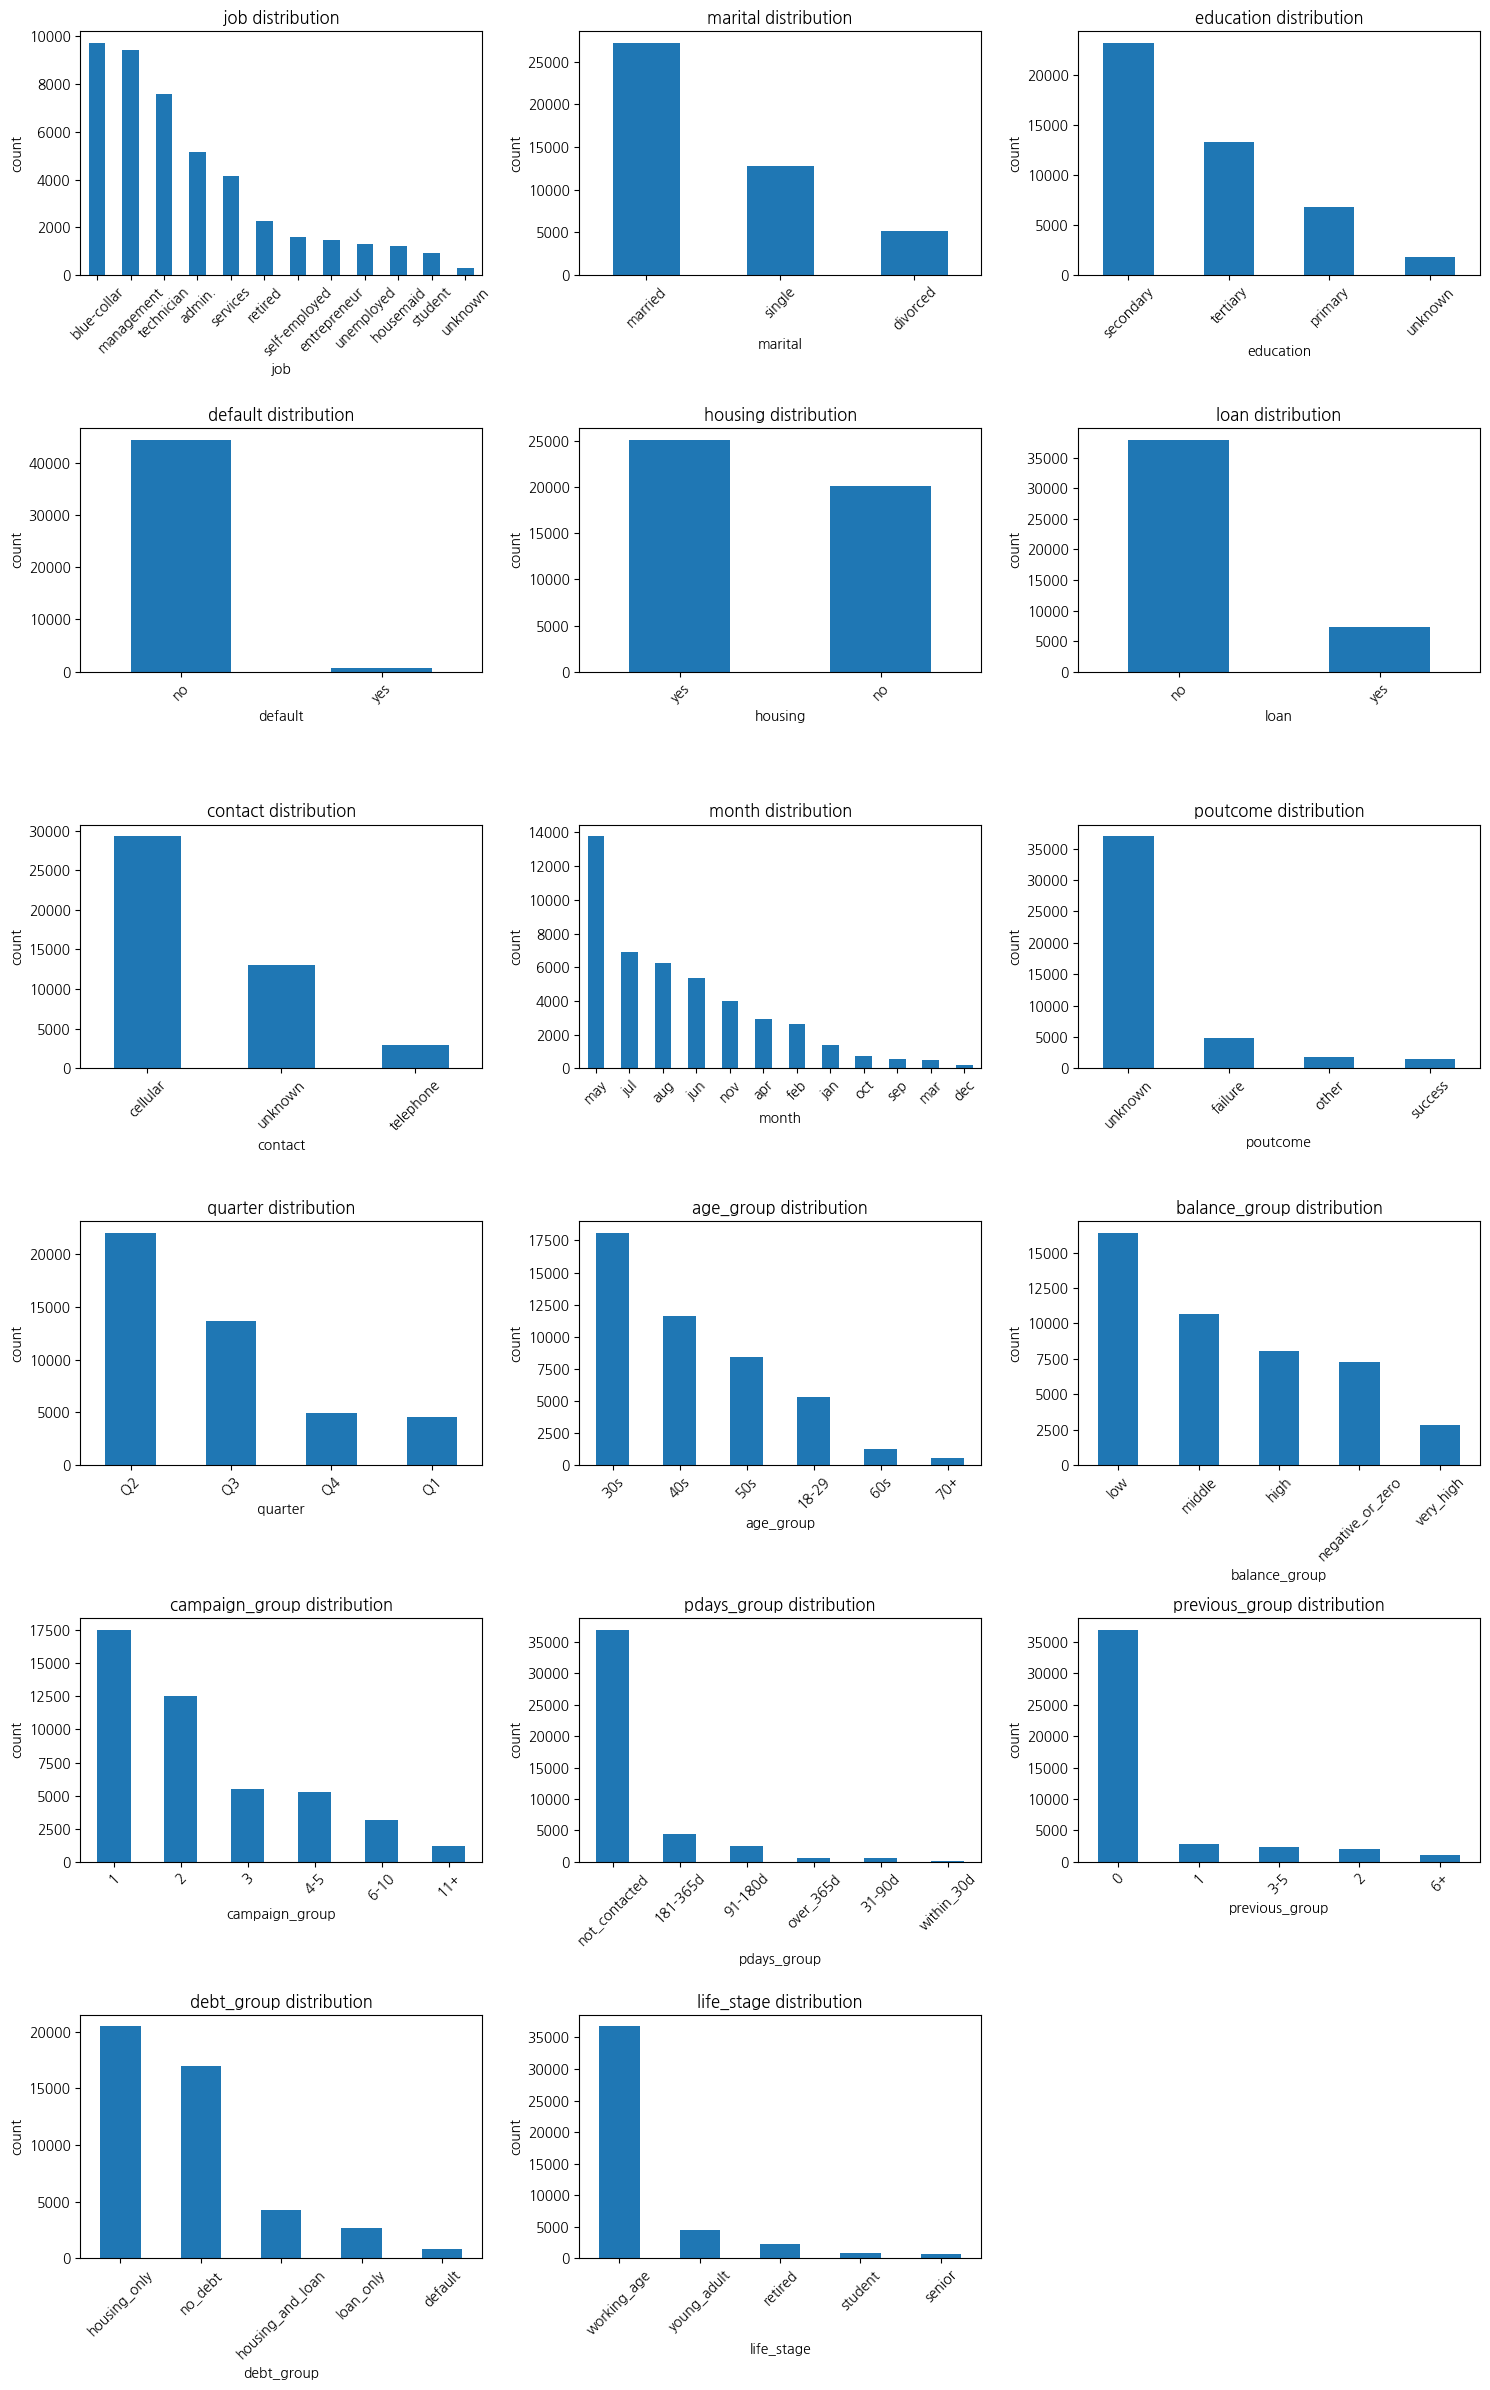

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col + ' distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- 고객 특성, 금융 상태, 캠페인 이력 변수들의 범주 불균형을 확인할 수 있다.
- 특히 poutcome, pdays_group, previous_group은 이전 캠페인 이력이 없는 고객이 많다.

## 3-5. 금융 상태 변수별 가입률

In [ ]:
def target_rate_table(col):
    result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()
    result.columns = [col, 'total_count', 'yes_count', 'yes_rate']
    result['yes_rate(%)'] = result['yes_rate'] * 100
    result['customer_ratio(%)'] = result['total_count'] / len(df) * 100
    result = result.sort_values('yes_rate(%)', ascending=False)
    return result

- 입력한 범주형 변수에 대해 전체 고객 수, 가입자 수, 가입률, 전체 고객 대비 비중을 계산하는 함수를 정의한다.

In [ ]:
def target_rate_plot(col):
    result = target_rate_table(col)

    plt.bar(result[col].astype(str), result['yes_rate(%)'])
    plt.axhline(df['target'].mean() * 100, linestyle='--')
    plt.title(col + ' yes rate')
    plt.xlabel(col)
    plt.ylabel('yes_rate(%)')
    plt.xticks(rotation=45)
    plt.show()

    return result

- 범주별 가입률을 막대그래프로 그리고, 전체 평균 가입률을 점선 기준선으로 표시하는 함수를 정의한다.

**3-5-1. 잔고 구간별 가입률**

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


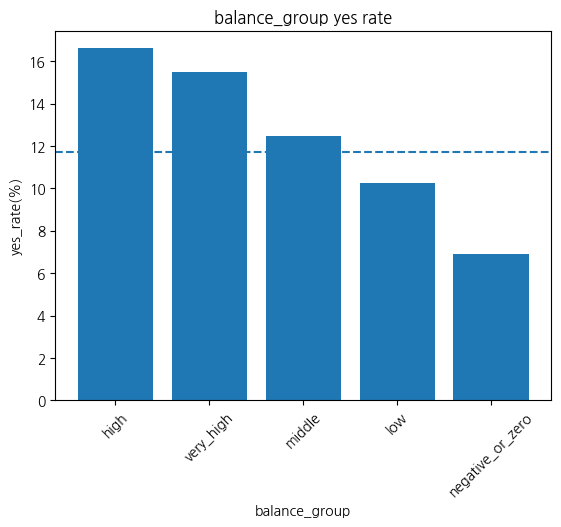

,balance_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
3,high,8050,1337,0.166087,16.608696,17.811705
4,very_high,2845,441,0.155009,15.500879,6.294944
2,middle,10651,1329,0.124777,12.477702,23.566766
1,low,16385,1680,0.102533,10.253280,36.254010
0,negative_or_zero,7264,502,0.069108,6.910793,16.072574


In [ ]:
target_rate_plot('balance_group')

- 잔고가 높은 high, very_high 그룹의 가입률이 약 15~17%로 높고, negative_or_zero 그룹은 약 6.9%로 낮다.
- 잔고 수준은 정기예금 가입 가능성과 관련이 있어 보인다.

**3-5-2. 주택담보대출 여부별 가입률**

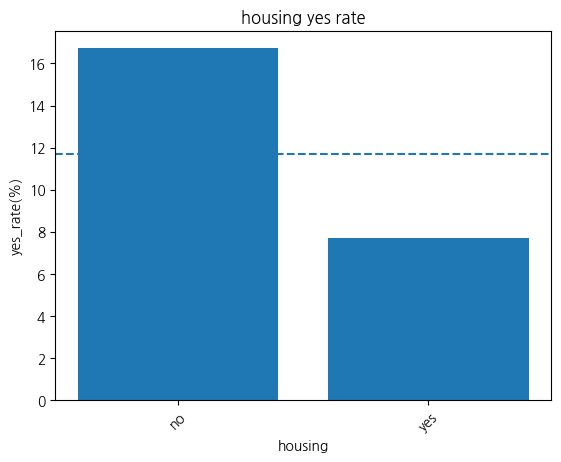

,housing,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,no,20069,3354,0.167123,16.712342,44.405355
1,yes,25126,1935,0.077012,7.701186,55.594645


In [ ]:
target_rate_plot('housing')

- 주택담보대출이 없는 고객의 가입률은 약 16.7%, 있는 고객은 약 7.7%이다.
- 주택담보대출 보유 여부는 가입률 차이가 큰 변수로 보인다.

**3-5-3. 개인대출 여부별 가입률**

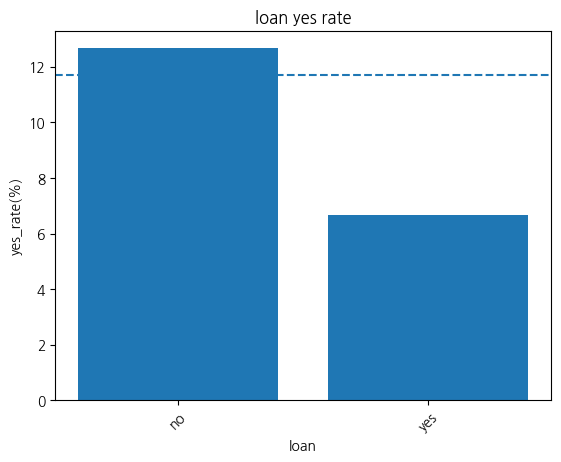

,loan,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,no,37951,4805,0.126611,12.661063,83.971678
1,yes,7244,484,0.066814,6.681391,16.028322


In [ ]:
target_rate_plot('loan')

- 개인대출이 없는 고객의 가입률은 약 12.7%, 있는 고객은 약 6.7%이다.
- 개인대출 보유 고객은 정기예금 가입 가능성이 상대적으로 낮다.

**3-5-4. 디폴트 여부별 가입률**

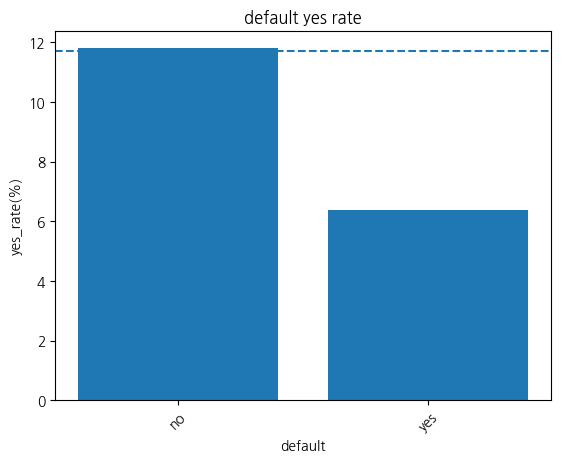

,default,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,no,44380,5237,0.118004,11.800361,98.196703
1,yes,815,52,0.063804,6.380368,1.803297


In [ ]:
target_rate_plot('default')

- 디폴트가 없는 고객의 가입률은 약 11.8%, 디폴트가 있는 고객은 약 6.4%이다.
- 디폴트 고객 수 자체는 적지만 가입률은 낮게 나타난다.

**3-5-5. 대출 개수별 가입률**

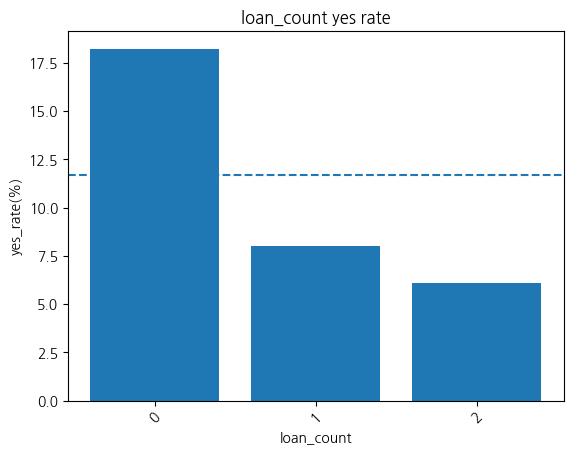

,loan_count,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,0,17192,3135,0.182352,18.235226,38.039606
1,1,23636,1889,0.079920,7.992046,52.297821
2,2,4367,265,0.060682,6.068239,9.662573


In [ ]:
target_rate_plot('loan_count')

- 대출이 없는 고객의 가입률은 약 18.2%로 가장 높고, 대출 2개 보유 고객은 약 6.1%로 낮다.
- 금융 부담이 적을수록 정기예금 가입 가능성이 높아 보인다.

**3-5-6. 금융 부담 그룹별 가입률**

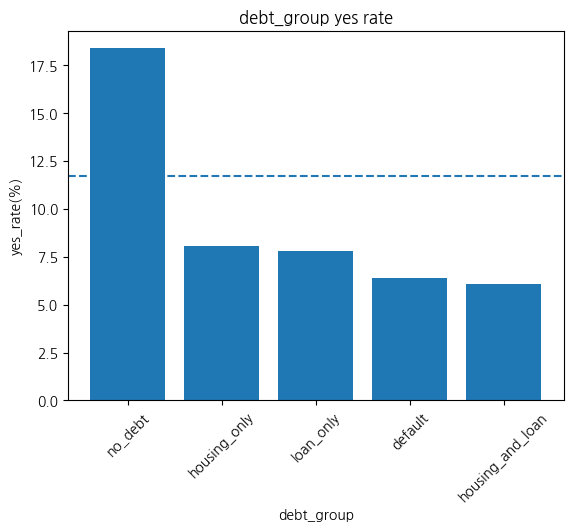

,debt_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
4,no_debt,16980,3120,0.183746,18.374558,37.570528
2,housing_only,20457,1648,0.080559,8.055922,45.263857
3,loan_only,2709,211,0.077889,7.788852,5.994026
0,default,815,52,0.063804,6.380368,1.803297
1,housing_and_loan,4234,258,0.060935,6.093529,9.368293


In [ ]:
target_rate_plot('debt_group')

- no_debt 그룹의 가입률이 약 18.4%로 가장 높고, housing_and_loan 그룹은 약 6.1%로 낮다.
- 단순 대출 여부보다 금융 부담 조합이 가입률 차이를 잘 보여주는 것으로 보인다.

## 3-6. 인구통계 변수별 가입률

**3-6-1. 나이대별 가입률**

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


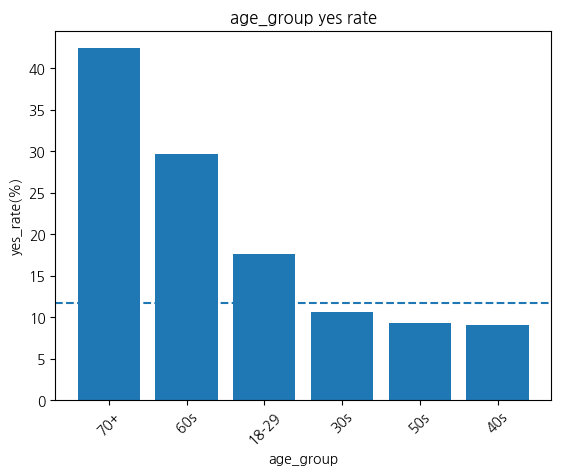

,age_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
5,70+,554,235,0.424188,42.418773,1.225799
4,60s,1230,365,0.296748,29.674797,2.721540
0,18-29,5272,928,0.176024,17.602428,11.665007
1,30s,18079,1913,0.105813,10.581337,40.002213
3,50s,8409,785,0.093352,9.335236,18.606040
2,40s,11651,1063,0.091237,9.123680,25.779400


In [ ]:
target_rate_plot('age_group')

- 70대 이상과 60대의 가입률이 높고, 30~50대는 상대적으로 낮다.
- 은퇴자나 고령층이 정기예금 상품에 더 관심을 보일 가능성이 있다.

**3-6-2. 직업별 가입률**

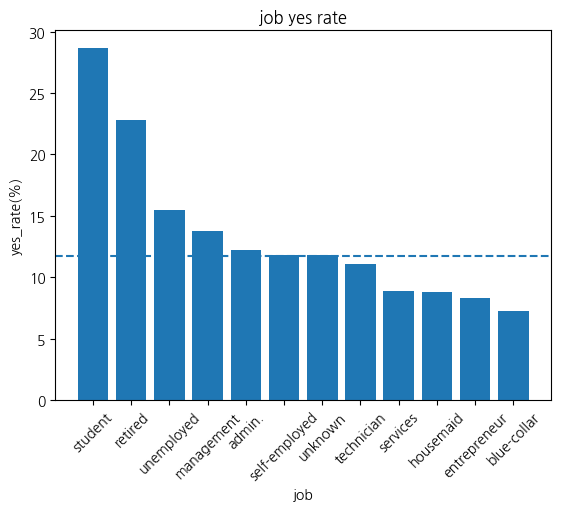

,job,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
8,student,938,269,0.286780,28.678038,2.075451
5,retired,2263,516,0.228016,22.801591,5.007191
10,unemployed,1303,202,0.155027,15.502686,2.883062
4,management,9451,1301,0.137657,13.765739,20.911605
0,admin.,5171,631,0.122027,12.202669,11.441531
6,self-employed,1579,187,0.118429,11.842939,3.493749
11,unknown,288,34,0.118056,11.805556,0.637239
9,technician,7593,840,0.110628,11.062821,16.800531
7,services,4152,369,0.088873,8.887283,9.186857
3,housemaid,1240,109,0.087903,8.790323,2.743666


In [ ]:
target_rate_plot('job')

- student, retired, unemployed의 가입률이 높고, blue-collar, entrepreneur는 낮다.
- 직업은 정기예금 가입 패턴을 설명하는 주요 범주형 변수로 보인다.

**3-6-3. 결혼 상태별 가입률**

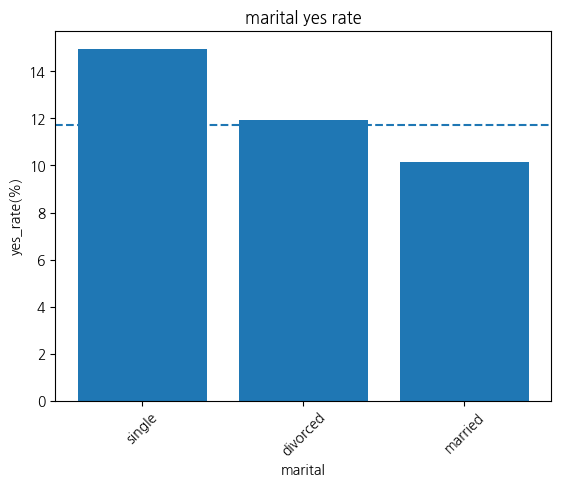

,marital,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,single,12780,1912,0.149609,14.960876,28.277464
0,divorced,5207,622,0.119455,11.945458,11.521186
1,married,27208,2755,0.101257,10.125698,60.201350


In [ ]:
target_rate_plot('marital')

- 미혼 고객의 가입률이 약 15.0%로 가장 높고, 기혼 고객은 약 10.1%로 낮다.

**3-6-4. 교육 수준별 가입률**

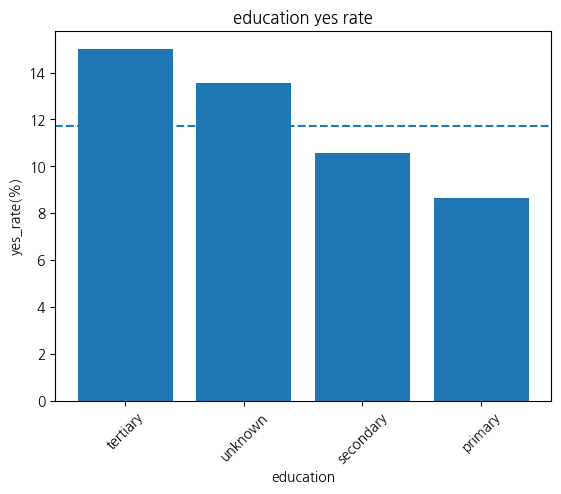

,education,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,tertiary,13291,1996,0.150177,15.017681,29.408120
3,unknown,1857,252,0.135703,13.570275,4.108862
1,secondary,23199,2450,0.105608,10.560800,51.330899
0,primary,6848,591,0.086303,8.630257,15.152119


In [ ]:
target_rate_plot('education')

- tertiary 고객의 가입률이 약 15.0%로 가장 높고, primary는 약 8.6%로 낮다.
- 교육 수준이 높을수록 가입률이 높아지는 경향이 보인다.

**3-6-5. 생애단계별 가입률**

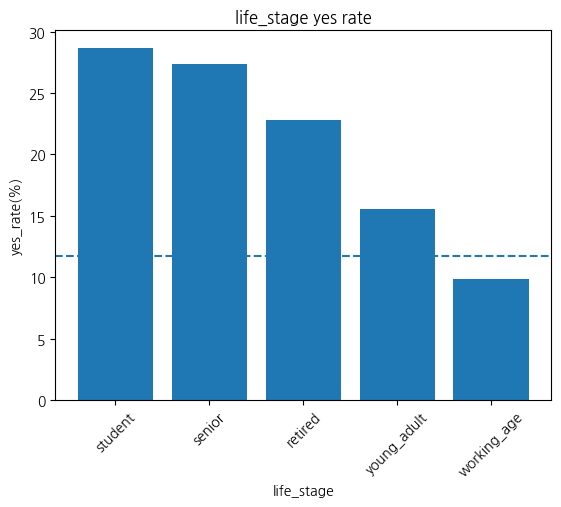

,life_stage,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,student,938,269,0.286780,28.678038,2.075451
1,senior,694,190,0.273775,27.377522,1.535568
0,retired,2263,516,0.228016,22.801591,5.007191
4,young_adult,4552,707,0.155316,15.531634,10.071911
3,working_age,36748,3607,0.098155,9.815500,81.309879


In [ ]:
target_rate_plot('life_stage')

- 학생, 고령층, 은퇴자의 가입률이 높고, 일반 경제활동층은 약 9.8%로 낮다.

## 3-7. 현재 캠페인 관련 변수별 가입률

**3-7-1. 연락 수단별 가입률**

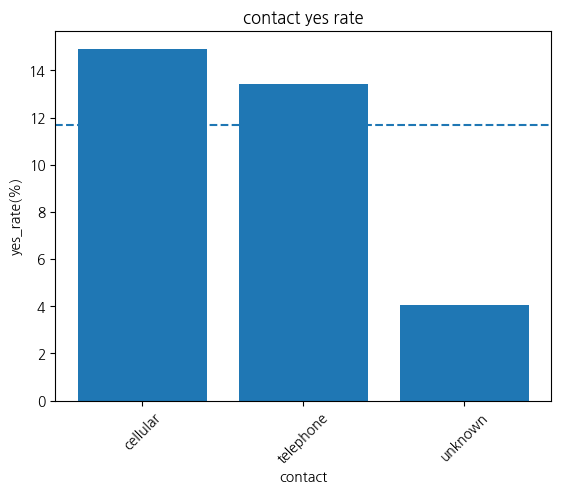

,contact,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,cellular,29271,4369,0.149260,14.926036,64.766014
1,telephone,2906,390,0.134205,13.420509,6.429915
2,unknown,13018,530,0.040713,4.071286,28.804071


In [ ]:
target_rate_plot('contact')

- 휴대전화와 유선전화 연락은 가입률이 13~15% 수준이지만, 연락 수단이 unknown인 경우 약 4.1%로 매우 낮다.

**3-7-2. 연락 월별 가입률**

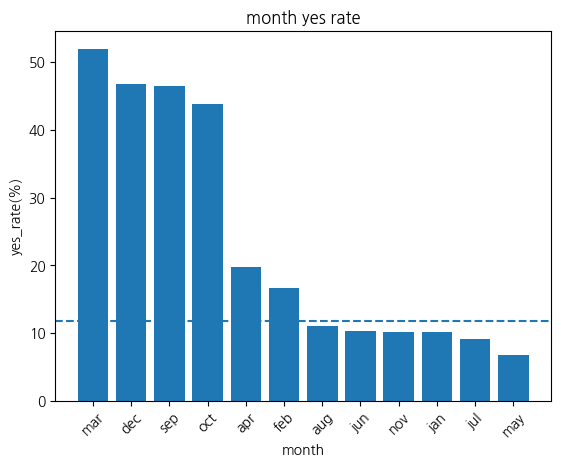

,month,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
7,mar,477,248,0.519916,51.991614,1.055426
2,dec,214,100,0.467290,46.728972,0.473504
11,sep,579,269,0.464594,46.459413,1.281115
10,oct,738,323,0.437669,43.766938,1.632924
0,apr,2932,577,0.196794,19.679400,6.487443
3,feb,2649,441,0.166478,16.647792,5.861268
1,aug,6236,688,0.110327,11.032713,13.797987
6,jun,5341,546,0.102228,10.222805,11.817679
9,nov,3970,403,0.101511,10.151134,8.784158
4,jan,1403,142,0.101212,10.121169,3.104326


In [ ]:
target_rate_plot('month')

- 3월, 9월, 10월, 12월의 가입률이 높지만 해당 월들은 표본 수가 작은 경우가 있다.
- 반면 5월은 고객 수가 가장 많지만 가입률은 약 6.7%로 낮다.

**3-7-3. 연락 월 순서대로 가입률**

In [ ]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_result = target_rate_table('month')
month_result['month'] = pd.Categorical(month_result['month'], categories=month_order, ordered=True)
month_result = month_result.sort_values('month')

month_result

,month,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
4,jan,1403,142,0.101212,10.121169,3.104326
3,feb,2649,441,0.166478,16.647792,5.861268
7,mar,477,248,0.519916,51.991614,1.055426
0,apr,2932,577,0.196794,19.679400,6.487443
8,may,13764,925,0.067204,6.720430,30.454696
6,jun,5341,546,0.102228,10.222805,11.817679
5,jul,6892,627,0.090975,9.097504,15.249474
1,aug,6236,688,0.110327,11.032713,13.797987
11,sep,579,269,0.464594,46.459413,1.281115
10,oct,738,323,0.437669,43.766938,1.632924


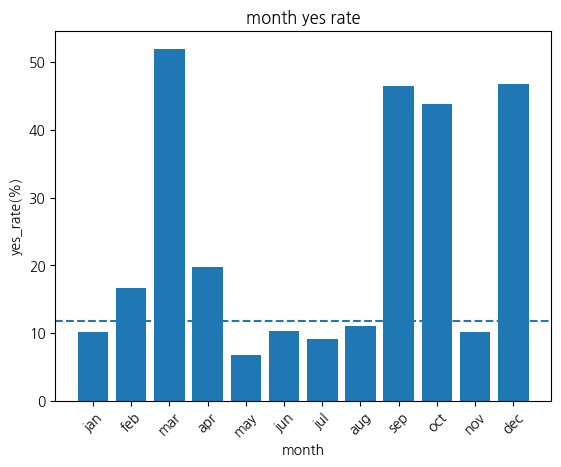

In [ ]:
plt.bar(month_result['month'].astype(str), month_result['yes_rate(%)'])
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('month yes rate')
plt.xlabel('month')
plt.ylabel('yes_rate(%)')
plt.xticks(rotation=45)
plt.show()

- 월별 가입률 결과를 달 순서로 재정렬하였다.

**3-7-4. 분기별 가입률**

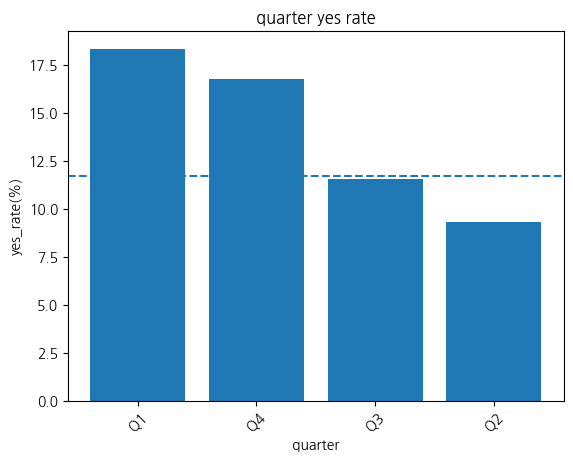

,quarter,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,Q1,4529,831,0.183484,18.348421,10.021020
3,Q4,4922,826,0.167818,16.781796,10.890585
2,Q3,13707,1584,0.115561,11.556139,30.328576
1,Q2,22037,2048,0.092935,9.293461,48.759819


In [ ]:
target_rate_plot('quarter')

- Q1과 Q4의 가입률이 Q2, Q3보다 높다.

**3-7-5. 연락 일자별 가입률**

In [ ]:
day_result = target_rate_table('day').sort_values('day')
day_result

,day,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,1,322,90,0.279503,27.950311,0.712468
1,2,1293,182,0.140758,14.075793,2.860936
2,3,1079,178,0.164968,16.496756,2.387432
3,4,1445,230,0.159170,15.916955,3.197256
4,5,1910,215,0.112565,11.256545,4.226131
5,6,1932,181,0.093685,9.368530,4.274809
6,7,1816,157,0.086454,8.645374,4.018144
7,8,1842,201,0.109121,10.912052,4.075672
8,9,1560,179,0.114744,11.474359,3.451709
9,10,524,121,0.230916,23.091603,1.159420


- 1일, 10일, 30일 등 일부 일자의 가입률이 높게 나타난다.
- 다만 일자별 표본 수 차이가 있음을 고려해야 한다.

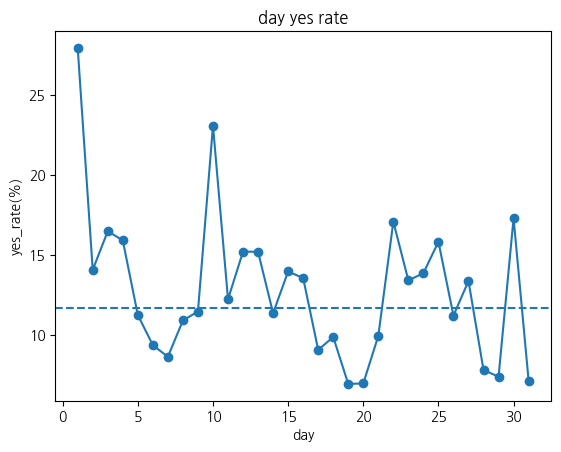

In [ ]:
plt.plot(day_result['day'], day_result['yes_rate(%)'], marker='o')
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('day yes rate')
plt.xlabel('day')
plt.ylabel('yes_rate(%)')
plt.show()

- 일자별 가입률이 일정하지 않고 변동이 있다.
- 다만 날짜 자체가 원인이라기보다는 캠페인 운영 일정이나 표본 수 차이의 영향일 수 있다고 본다.

**3-7-6. 캠페인 횟수별 가입률**

In [ ]:
campaign_result = target_rate_table('campaign').sort_values('campaign')
campaign_result.head(20)

,campaign,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,1,17539,2561,0.146017,14.601745,38.807390
1,2,12497,1401,0.112107,11.210691,27.651289
2,3,5520,618,0.111957,11.195652,12.213740
3,4,3521,317,0.090031,9.003124,7.790685
4,5,1764,139,0.078798,7.879819,3.903087
5,6,1291,92,0.071263,7.126259,2.856511
6,7,735,47,0.063946,6.394558,1.626286
7,8,540,32,0.059259,5.925926,1.194822
8,9,327,21,0.064220,6.422018,0.723531
9,10,265,14,0.052830,5.283019,0.586348


- 1회 연락 고객의 가입률이 약 14.6%로 가장 높고, 연락 횟수가 늘어날수록 가입률이 낮아지는 경향이 있다.
- 과도한 연락은 가입 가능성과 음의 관계를 보일 수 있다.

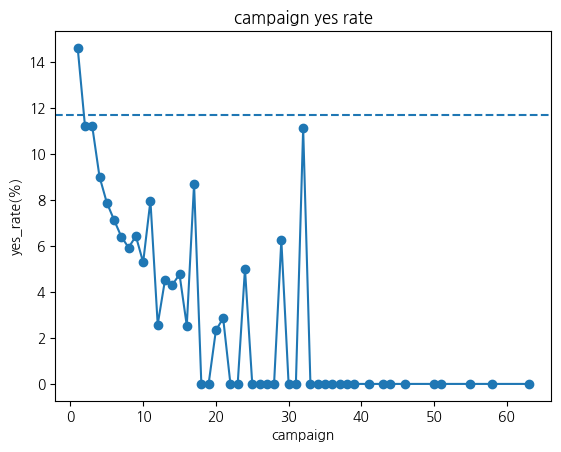

In [ ]:
plt.plot(campaign_result['campaign'], campaign_result['yes_rate(%)'], marker='o')
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('campaign yes rate')
plt.xlabel('campaign')
plt.ylabel('yes_rate(%)')
plt.show()

- 초반 연락 횟수에서는 가입률이 상대적으로 높지만 횟수가 증가할수록 대체로 낮아진다.
- 고객에게 반복 연락을 많이 한 것은 설득 효과보다 미가입 가능성의 신호일 수 있다고 본다.

**3-7-7. 캠페인 구간별 가입률**

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


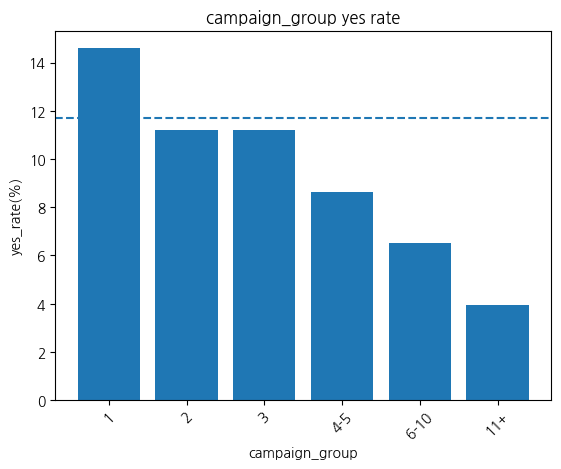

,campaign_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,1,17539,2561,0.146017,14.601745,38.807390
1,2,12497,1401,0.112107,11.210691,27.651289
2,3,5520,618,0.111957,11.195652,12.213740
3,4-5,5285,456,0.086282,8.628193,11.693771
4,6-10,3158,206,0.065231,6.523116,6.987499
5,11+,1196,47,0.039298,3.929766,2.646310


In [ ]:
target_rate_plot('campaign_group')

- 1회 연락 그룹은 약 14.6%, 11회 이상 그룹은 약 3.9%로 차이가 크다.
- 현재 캠페인 연락 횟수는 가입률과 뚜렷한 음의 관계를 보인다.

**3-7-8. 과도한 연락 여부별 가입률**

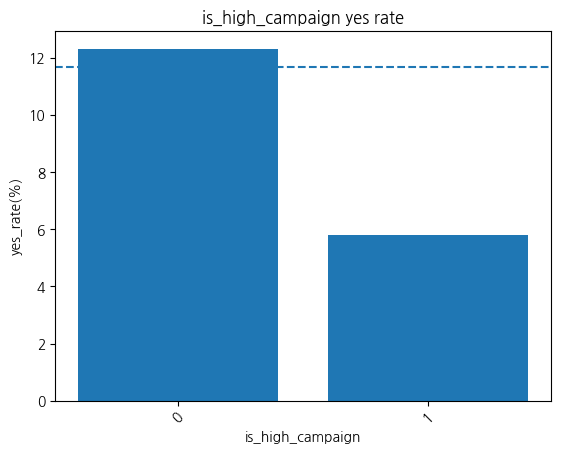

,is_high_campaign,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,0,40841,5036,0.123307,12.330746,90.366191
1,1,4354,253,0.058107,5.810749,9.633809


In [ ]:
target_rate_plot('is_high_campaign')

- 6회 이상 연락 그룹의 가입률은 약 5.8%로, 6회 미만 그룹의 약 12.3%보다 낮다.

## 3-8. 이전 캠페인 이력 관련 가입률

**3-8-1. 이전 연락 여부별 가입률**

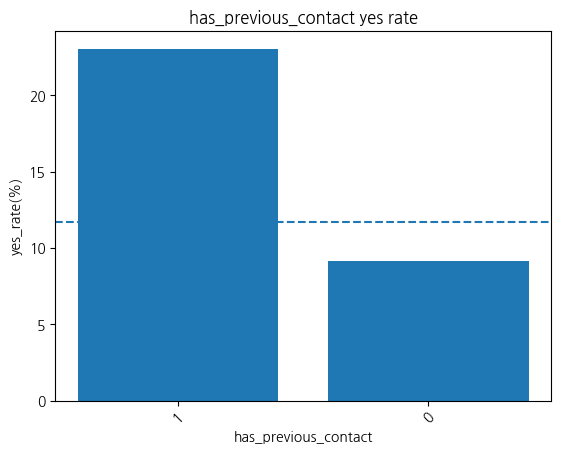

,has_previous_contact,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
1,1,8257,1905,0.230713,23.071333,18.26972
0,0,36938,3384,0.091613,9.161297,81.73028


In [ ]:
target_rate_plot('has_previous_contact')

- 이전 연락 이력이 있는 고객의 가입률은 약 23.1%, 없는 고객은 약 9.2%이다.

**3-8-2. 이전 캠페인 결과별 가입률**

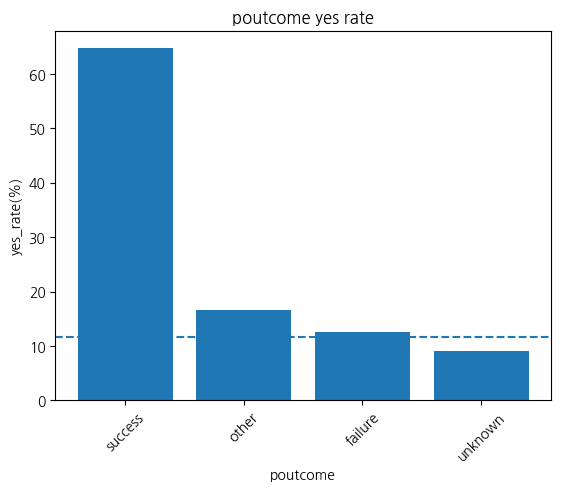

,poutcome,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,success,1511,978,0.647253,64.725347,3.343290
1,other,1840,307,0.166848,16.684783,4.071247
0,failure,4901,618,0.126097,12.609671,10.844120
3,unknown,36943,3386,0.091655,9.165471,81.741343


In [ ]:
target_rate_plot('poutcome')

- 이전 캠페인 결과가 success였던 고객의 가입률은 약 64.7%로 매우 높다.

**3-8-3. 이전 캠페인 성공 여부별 가입률**

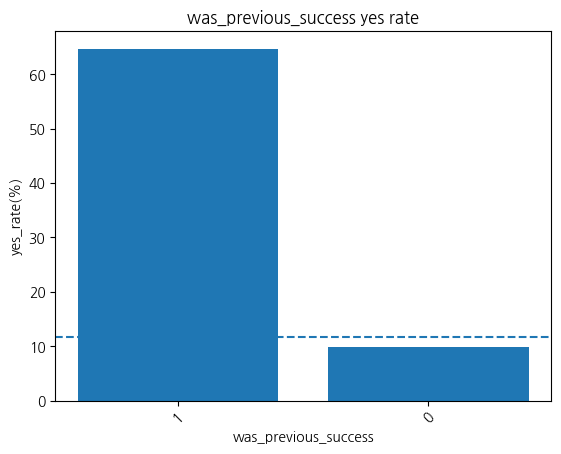

,was_previous_success,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
1,1,1511,978,0.647253,64.725347,3.34329
0,0,43684,4311,0.098686,9.868602,96.65671


In [ ]:
target_rate_plot('was_previous_success')

- 이전 성공 고객은 가입률이 약 64.7%, 그 외 고객은 약 9.9%이다.

**3-8-4. 이전 연락 후 경과일 구간별 가입률**

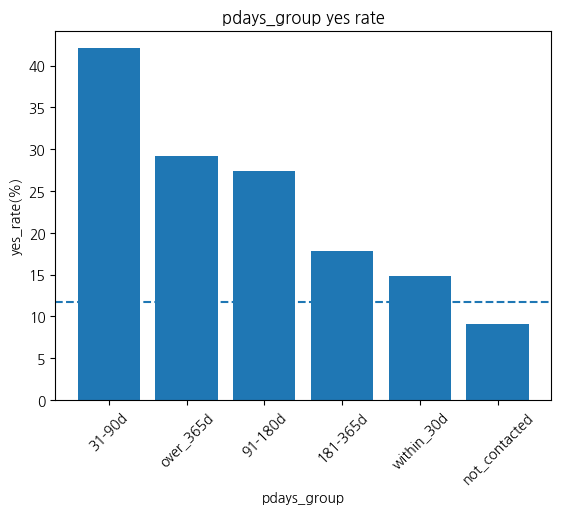

,pdays_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
1,31-90d,530,223,0.420755,42.075472,1.172696
4,over_365d,643,188,0.292379,29.237947,1.422724
2,91-180d,2480,680,0.274194,27.419355,5.487333
0,181-365d,4416,786,0.177989,17.798913,9.770992
5,within_30d,188,28,0.148936,14.893617,0.415975
3,not_contacted,36938,3384,0.091613,9.161297,81.730280


In [ ]:
target_rate_plot('pdays_group')

- 31~90일 그룹의 가입률이 약 42.1%로 높고, 이전 연락이 없는 그룹은 약 9.2%로 낮다.

**3-8-5. 이전 연락 횟수 구간별 가입률**

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


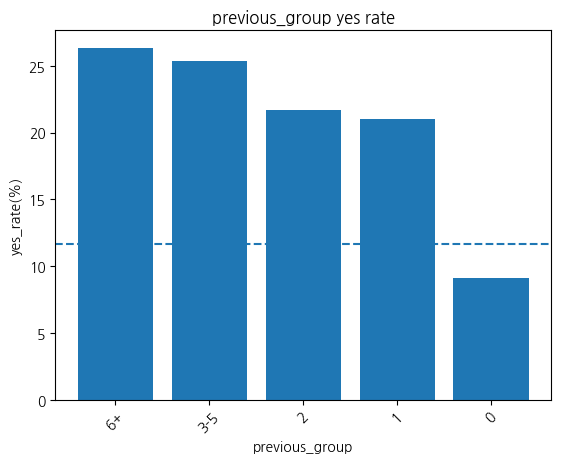

,previous_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
4,6+,1064,280,0.263158,26.315789,2.354243
3,3-5,2315,586,0.253132,25.313175,5.122248
2,2,2106,456,0.216524,21.652422,4.659808
1,1,2772,583,0.210317,21.031746,6.133422
0,0,36938,3384,0.091613,9.161297,81.730280


In [ ]:
target_rate_plot('previous_group')

- 이전 연락 횟수가 0회인 고객은 가입률이 약 9.2%이고, 3회 이상 이력이 있는 고객은 25% 이상이다.
- 이전 접촉 이력이 있는 고객이 가입 가능성이 높다.

**3-8-6. previous 원본값별 가입률**

In [ ]:
previous_result = target_rate_table('previous').sort_values('previous')
previous_result.head(30)

,previous,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,0,36938,3384,0.091613,9.161297,81.730280
1,1,2772,583,0.210317,21.031746,6.133422
2,2,2106,456,0.216524,21.652422,4.659808
3,3,1142,294,0.257443,25.744308,2.526828
4,4,714,171,0.239496,23.949580,1.579821
5,5,459,121,0.263617,26.361656,1.015599
6,6,277,83,0.299639,29.963899,0.612900
7,7,205,54,0.263415,26.341463,0.453590
8,8,129,39,0.302326,30.232558,0.285430
9,9,92,24,0.260870,26.086957,0.203562


- previous=0인 고객의 가입률은 낮고, 이전 연락 횟수가 있는 고객은 대체로 가입률이 높다.
- 다만 횟수가 커질수록 표본 수가 작아진다는 점을 고려해야 한다.

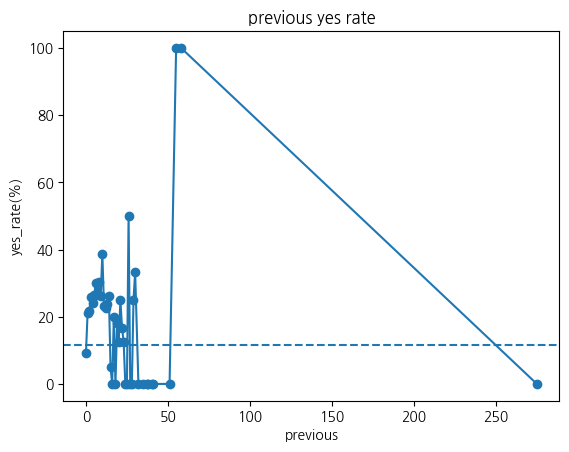

In [ ]:
plt.plot(previous_result['previous'], previous_result['yes_rate(%)'], marker='o')
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('previous yes rate')
plt.xlabel('previous')
plt.ylabel('yes_rate(%)')
plt.show()

- 이전 연락이 전혀 없는 경우보다 연락 이력이 있는 경우 가입률이 높게 나타난다.

## 3-9. unknown 값 분석

In [ ]:
unknown_cols = ['job', 'education', 'contact', 'poutcome']

for col in unknown_cols:
    if col in df.columns:
        print('[' + col + ']')
        print(df[col].value_counts())
        print()
        print(target_rate_table(col))
        print('-' * 80)

[job]
job
blue-collar      9730
management       9451
technician       7593
admin.           5171
services         4152
retired          2263
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

              job  total_count  yes_count  yes_rate  yes_rate(%)  \
8         student          938        269  0.286780    28.678038   
5         retired         2263        516  0.228016    22.801591   
10     unemployed         1303        202  0.155027    15.502686   
4      management         9451       1301  0.137657    13.765739   
0          admin.         5171        631  0.122027    12.202669   
6   self-employed         1579        187  0.118429    11.842939   
11        unknown          288         34  0.118056    11.805556   
9      technician         7593        840  0.110628    11.062821   
7        services         4152        369  0.088873     8.887283   
3       housemaid  

- contact의 unknown은 가입률이 매우 낮고, poutcome의 unknown은 대부분 이전 캠페인 이력이 없는 고객을 의미한다.
- 따라서 unknown은 단순 결측이 아니라 고객 상태를 나타내는 정보로 볼 수 있다.

In [ ]:
for col in unknown_cols:
    if col in df.columns:
        new_col = col + '_is_unknown'
        df[new_col] = np.where(df[col] == 'unknown', 1, 0)
        print(target_rate_table(new_col))
        print('-' * 80)

   job_is_unknown  total_count  yes_count  yes_rate  yes_rate(%)  \
1               1          288         34  0.118056    11.805556   
0               0        44907       5255  0.117020    11.701962   

   customer_ratio(%)  
1           0.637239  
0          99.362761  
--------------------------------------------------------------------------------
   education_is_unknown  total_count  yes_count  yes_rate  yes_rate(%)  \
1                     1         1857        252  0.135703    13.570275   
0                     0        43338       5037  0.116226    11.622594   

   customer_ratio(%)  
1           4.108862  
0          95.891138  
--------------------------------------------------------------------------------
   contact_is_unknown  total_count  yes_count  yes_rate  yes_rate(%)  \
0                   0        32177       4759  0.147901    14.790067   
1                   1        13018        530  0.040713     4.071286   

   customer_ratio(%)  
0          71.195929  
1        

- 특히 contact_is_unknown은 가입률 차이가 크다.
- 연락 수단이 확인되지 않은 고객은 가입률이 낮다.

## 3-10. 수치형 변수 상관관계

In [ ]:
corr_cols = [
    'target',
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous',
    'month_num',
    'loan_count',
    'has_previous_contact',
    'pdays_for_model',
    'housing_num',
    'loan_num',
    'default_num',
    'was_previous_success',
    'is_high_campaign'
]

corr_cols = [col for col in corr_cols if col in df.columns]

df[corr_cols].corr()

,target,age,balance,day,campaign,pdays,previous,month_num,loan_count,has_previous_contact,pdays_for_model,housing_num,loan_num,default_num,was_previous_success,is_high_campaign
target,1.000000,0.025111,0.052784,-0.028283,-0.073196,0.103574,0.093207,0.018788,-0.149666,0.167213,0.103275,-0.139283,-0.068245,-0.022437,0.306773,-0.059846
age,0.025111,1.000000,0.097742,-0.009043,0.004770,-0.023816,0.001255,0.093001,-0.155693,0.000691,-0.023899,-0.185708,-0.015715,-0.017900,0.035507,0.011106
balance,0.052784,0.097742,1.000000,0.004589,-0.014600,0.003370,0.016635,0.094701,-0.103541,0.030140,0.003265,-0.068882,-0.084425,-0.066769,0.035212,-0.006740
day,-0.028283,-0.009043,0.004589,1.000000,0.162463,-0.092981,-0.051670,0.101864,-0.015251,-0.086099,-0.092960,-0.027786,0.011456,0.009451,-0.030289,0.131640
campaign,-0.073196,0.004770,-0.014600,0.162463,1.000000,-0.088656,-0.032870,0.054870,-0.012804,-0.108008,-0.088537,-0.023583,0.009962,0.016817,-0.057500,0.747582
pdays,0.103574,-0.023816,0.003370,-0.092981,-0.088656,1.000000,0.454802,-0.108874,0.084642,0.870434,0.999998,0.124117,-0.022819,-0.030000,0.228520,-0.067566
previous,0.093207,0.001255,0.016635,-0.051670,-0.032870,0.454802,1.000000,-0.035555,0.022761,0.532973,0.454270,0.037029,-0.011083,-0.018342,0.201411,-0.017728
month_num,0.018788,0.093001,0.094701,0.101864,0.054870,-0.108874,-0.035555,1.000000,-0.124414,-0.060979,-0.109004,-0.173713,0.021724,0.015016,0.033739,0.047773
loan_count,-0.149666,-0.155693,-0.103541,-0.015251,-0.012804,0.084642,0.022761,-0.124414,1.000000,0.031927,0.084804,0.813094,0.615167,0.040210,-0.103449,-0.022683
has_previous_contact,0.167213,0.000691,0.030140,-0.086099,-0.108008,0.870434,0.532973,-0.060979,0.031927,1.000000,0.869494,0.063563,-0.031287,-0.039544,0.393366,-0.082180


In [ ]:
df[corr_cols].corr()['target'].sort_values(ascending=False)

,target
target,1.000000
was_previous_success,0.306773
has_previous_contact,0.167213
pdays,0.103574
pdays_for_model,0.103275
previous,0.093207
balance,0.052784
age,0.025111
month_num,0.018788
default_num,-0.022437


- was_previous_success, has_previous_contact, pdays, previous는 양의 상관이 있고, housing_num, loan_count, campaign은 음의 상관을 보인다.
- 이전 캠페인 이력은 긍정적, 대출 부담과 과도한 연락은 부정적 신호로 해석된다.

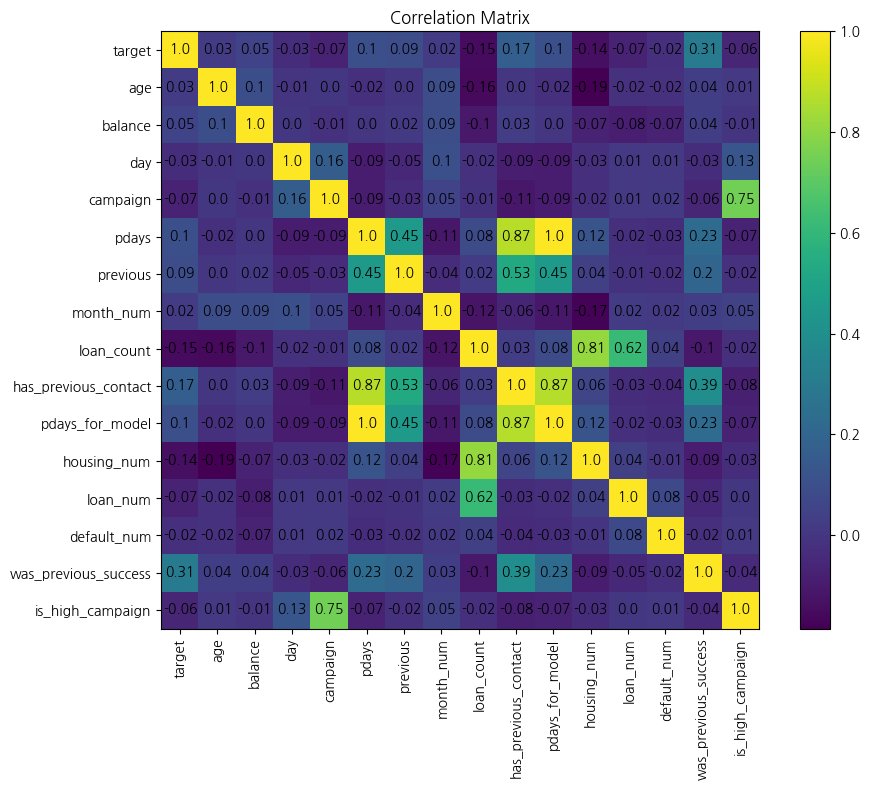

In [ ]:
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            round(corr.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3-11. 두 변수 조합별 가입률 분석

**3-11-1. 직업 X 교육 수준**

In [ ]:
job_edu = pd.pivot_table(
    df,
    values='target',
    index='job',
    columns='education',
    aggfunc='mean'
) * 100

job_edu

education,primary,secondary,tertiary,unknown
job,,,,
admin.,5.741627,11.898554,17.307692,10.526316
blue-collar,5.804047,8.061813,16.107383,7.268722
entrepreneur,6.557377,9.594096,7.580175,9.210526
housemaid,7.814992,8.607595,12.716763,8.888889
management,7.482993,8.652988,14.549654,19.834711
retired,22.418136,21.036585,27.595628,25.210084
self-employed,3.846154,7.452340,16.086435,12.820513
services,8.405797,8.567294,12.376238,12.666667
student,36.363636,29.724409,26.457399,26.380368


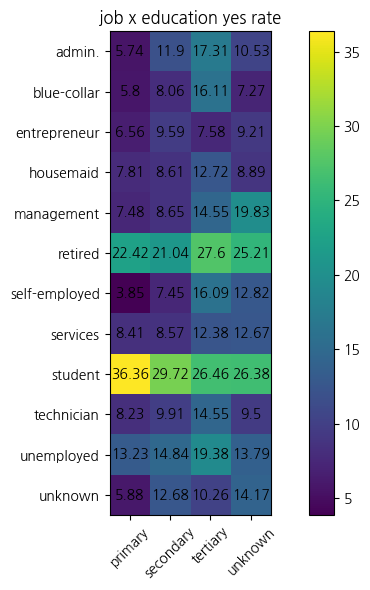

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(job_edu)
plt.colorbar()

plt.xticks(range(len(job_edu.columns)), job_edu.columns, rotation=45)
plt.yticks(range(len(job_edu.index)), job_edu.index)

for i in range(len(job_edu.index)):
    for j in range(len(job_edu.columns)):
        plt.text(
            j, i,
            round(job_edu.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('job x education yes rate')
plt.tight_layout()
plt.show()

- 학생과 은퇴자 그룹에서 가입률이 높게 나타나고, 같은 직업 안에서도 교육 수준에 따라 가입률 차이가 있다.

**3-11-2. 직업 X 주택담보대출 여부**

In [ ]:
job_housing = pd.pivot_table(
    df,
    values='target',
    index='job',
    columns='housing',
    aggfunc='mean'
) * 100

job_housing

housing,no,yes
job,,
admin.,17.295123,9.019485
blue-collar,10.178971,6.171964
entrepreneur,11.326861,6.098964
housemaid,10.095012,6.030151
management,18.219895,9.217280
retired,26.185102,10.590631
self-employed,14.619165,8.888889
services,13.256484,6.693198
student,35.849057,8.835341


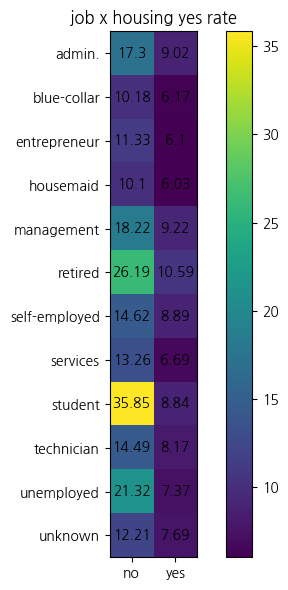

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(job_housing)
plt.colorbar()

plt.xticks(range(len(job_housing.columns)), job_housing.columns)
plt.yticks(range(len(job_housing.index)), job_housing.index)

for i in range(len(job_housing.index)):
    for j in range(len(job_housing.columns)):
        plt.text(
            j, i,
            round(job_housing.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('job x housing yes rate')
plt.tight_layout()
plt.show()

- 주택담보대출이 없는 학생, 은퇴자, 실업자 그룹에서 가입률이 높게 보인다.

**3-11-3. 나이대 X 잔고 구간**

In [ ]:
age_balance = pd.pivot_table(
    df,
    values='target',
    index='age_group',
    columns='balance_group',
    aggfunc='mean'
) * 100

age_balance

/tmp/ipykernel_42085/2460666798.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_balance = pd.pivot_table(


balance_group,negative_or_zero,low,middle,high,very_high
age_group,,,,,
18-29,10.144928,16.060862,20.145631,24.536377,23.809524
30s,5.860559,9.755037,11.626817,14.713896,13.676908
40s,6.434185,7.292707,9.725235,13.059877,12.983425
50s,6.349206,7.433694,8.435583,14.066059,12.912482
60s,16.541353,28.402367,31.597222,34.782609,28.571429
70+,31.818182,39.603960,42.446043,46.596859,41.772152


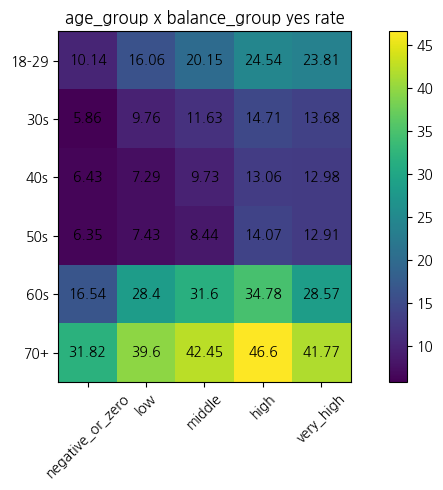

In [ ]:
plt.figure(figsize=(8, 5))
plt.imshow(age_balance)
plt.colorbar()

plt.xticks(range(len(age_balance.columns)), age_balance.columns, rotation=45)
plt.yticks(range(len(age_balance.index)), age_balance.index)

for i in range(len(age_balance.index)):
    for j in range(len(age_balance.columns)):
        plt.text(
            j, i,
            round(age_balance.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('age_group x balance_group yes rate')
plt.tight_layout()
plt.show()

- 고령층일수록, 그리고 잔고가 높을수록 가입률이 높아지는 경향이 보인다.
- 특히 60대 이상과 잔고가 높은 구간에서 가입률이 높다.

**3-11-4. 연락수단 X 월**

In [ ]:
contact_month = pd.pivot_table(
    df,
    values='target',
    index='contact',
    columns='month',
    aggfunc='mean'
) * 100

contact_month = contact_month[month_order]

contact_month

month,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
contact,,,,,,,,,,,,
cellular,10.197628,16.892464,53.237410,19.545288,11.873945,43.895748,9.628730,10.961441,51.716738,44.70377,9.915254,49.425287
telephone,9.302326,13.868613,41.509434,19.597990,6.739130,25.000000,7.159624,13.008130,37.878788,43.51145,10.290237,37.837838
unknown,11.111111,30.769231,57.142857,83.333333,3.273548,4.545455,3.985507,9.803922,6.382979,34.00000,25.490196,0.000000


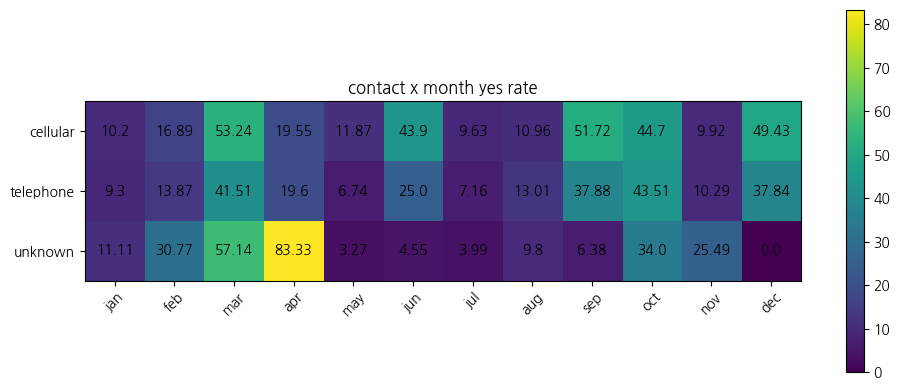

In [ ]:
plt.figure(figsize=(10, 4))
plt.imshow(contact_month)
plt.colorbar()

plt.xticks(range(len(contact_month.columns)), contact_month.columns, rotation=45)
plt.yticks(range(len(contact_month.index)), contact_month.index)

for i in range(len(contact_month.index)):
    for j in range(len(contact_month.columns)):
        plt.text(
            j, i,
            round(contact_month.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('contact x month yes rate')
plt.tight_layout()
plt.show()

- 연락 수단의 효과가 모든 달에서 동일하지 않음을 확인할 수 있다.

**3-11-5. 캠페인 구간 X 연락 수단**

In [ ]:
campaign_contact = pd.pivot_table(
    df,
    values='target',
    index='campaign_group',
    columns='contact',
    aggfunc='mean'
) * 100

campaign_contact

/tmp/ipykernel_42085/2346728232.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  campaign_contact = pd.pivot_table(


contact,cellular,telephone,unknown
campaign_group,,,
1,18.815178,20.302376,4.344483
2,14.031502,12.625538,4.191789
3,14.702416,12.368421,4.123711
4-5,10.801494,8.045977,3.287071
6-10,7.503752,7.558140,3.680982
11+,4.484305,4.838710,2.729529


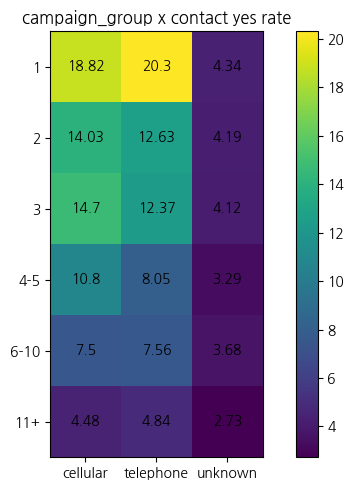

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(campaign_contact)
plt.colorbar()

plt.xticks(range(len(campaign_contact.columns)), campaign_contact.columns)
plt.yticks(range(len(campaign_contact.index)), campaign_contact.index)

for i in range(len(campaign_contact.index)):
    for j in range(len(campaign_contact.columns)):
        plt.text(
            j, i,
            round(campaign_contact.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('campaign_group x contact yes rate')
plt.tight_layout()
plt.show()

- cellular/telephone 모두 1회 연락 구간의 가입률이 높고, 연락 횟수가 많아질수록 낮아진다
- unknown 연락 수단은 전반적으로 낮은 가입률을 보인다.

**3-11-6. 이전 캠페인 결과 X 현재 연락수단**

In [ ]:
poutcome_contact = pd.pivot_table(
    df,
    values='target',
    index='poutcome',
    columns='contact',
    aggfunc='mean'
) * 100

poutcome_contact

contact,cellular,telephone,unknown
poutcome,,,
failure,12.651800,12.023460,12.903226
other,17.104459,12.500000,18.518519
success,64.981949,65.789474,25.000000
unknown,12.044199,11.076923,4.000618


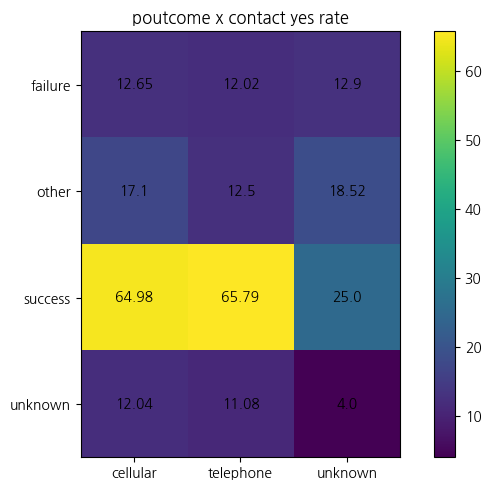

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(poutcome_contact)
plt.colorbar()

plt.xticks(range(len(poutcome_contact.columns)), poutcome_contact.columns)
plt.yticks(range(len(poutcome_contact.index)), poutcome_contact.index)

for i in range(len(poutcome_contact.index)):
    for j in range(len(poutcome_contact.columns)):
        plt.text(
            j, i,
            round(poutcome_contact.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('poutcome x contact yes rate')
plt.tight_layout()
plt.show()

- 이전 캠페인이 성공한 고객은 현재 연락 수단과 관계없이 가입률이 높다.
- 다만 unknown 연락 수단에서는 성공 이력이 있어도 가입률이 상대적으로 낮게 나타난다.

**3-11-7. 이전 연락 횟수 X 이전 연락 후 경과일**

In [ ]:
previous_pdays = pd.pivot_table(
    df,
    values='target',
    index='previous_group',
    columns='pdays_group',
    aggfunc='mean'
) * 100

previous_pdays

/tmp/ipykernel_42085/1537937827.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  previous_pdays = pd.pivot_table(


pdays_group,181-365d,31-90d,91-180d,not_contacted,over_365d,within_30d
previous_group,,,,,,
0,NaN,NaN,NaN,9.161297,NaN,NaN
1,15.759494,38.271605,25.000000,NaN,33.333333,15.384615
2,17.595049,38.596491,25.755167,NaN,24.742268,7.894737
3-5,20.294883,46.666667,28.192162,NaN,28.758170,15.094340
6+,18.840580,44.943820,33.720930,NaN,27.659574,21.875000


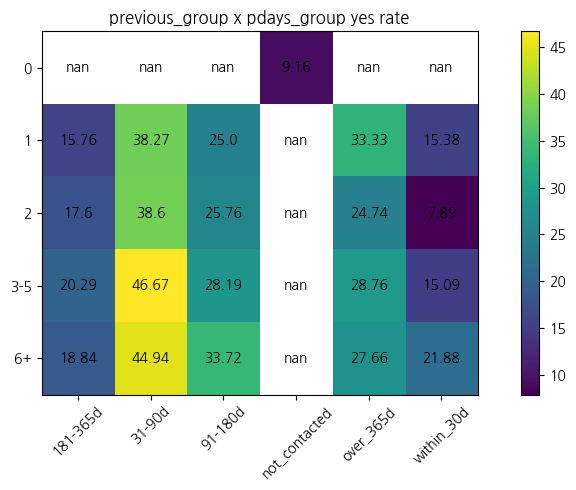

In [ ]:
plt.figure(figsize=(9, 5))
plt.imshow(previous_pdays)
plt.colorbar()

plt.xticks(range(len(previous_pdays.columns)), previous_pdays.columns, rotation=45)
plt.yticks(range(len(previous_pdays.index)), previous_pdays.index)

for i in range(len(previous_pdays.index)):
    for j in range(len(previous_pdays.columns)):
        plt.text(
            j, i,
            round(previous_pdays.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('previous_group x pdays_group yes rate')
plt.tight_layout()
plt.show()

- 이전 연락 이력이 있고 경과일이 31~90일인 그룹에서 가입률이 높다.

**3-11-8. 대출 보유 조합별 가입률**

In [ ]:
housing_loan = pd.pivot_table(
    df,
    values='target',
    index='housing',
    columns='loan',
    aggfunc='mean'
) * 100

housing_loan

loan,no,yes
housing,,
no,18.235226,7.612096
yes,8.044704,6.068239


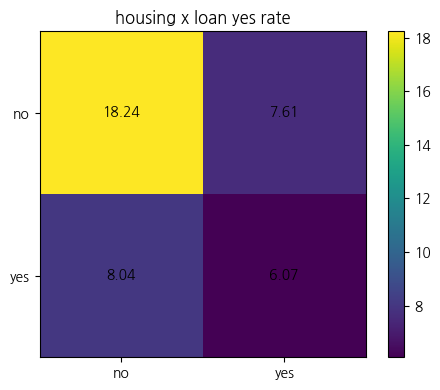

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(housing_loan)
plt.colorbar()

plt.xticks(range(len(housing_loan.columns)), housing_loan.columns)
plt.yticks(range(len(housing_loan.index)), housing_loan.index)

for i in range(len(housing_loan.index)):
    for j in range(len(housing_loan.columns)):
        plt.text(
            j, i,
            round(housing_loan.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('housing x loan yes rate')
plt.tight_layout()
plt.show()

- 주택담보대출과 개인대출이 모두 없는 고객의 가입률이 약 18.2%로 가장 높고, 둘 다 있는 고객은 약 6.1%로 낮다.
- 금융 부담이 낮은 고객이 정기예금 가입에 유리해 보인다.

## 3-12. 가입률 높은 그룹 / 낮은 그룹 찾기

**3-12-1. 범주형 변수별 가입률 높은 그룹**

In [ ]:
for col in categorical_cols:
    result = target_rate_table(col)
    print('[' + col + '] yes rate high')
    display(result.head(5))
    print('-' * 80)

[job] yes rate high


,job,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
8,student,938,269,0.286780,28.678038,2.075451
5,retired,2263,516,0.228016,22.801591,5.007191
10,unemployed,1303,202,0.155027,15.502686,2.883062
4,management,9451,1301,0.137657,13.765739,20.911605
0,admin.,5171,631,0.122027,12.202669,11.441531


--------------------------------------------------------------------------------
[marital] yes rate high


,marital,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,single,12780,1912,0.149609,14.960876,28.277464
0,divorced,5207,622,0.119455,11.945458,11.521186
1,married,27208,2755,0.101257,10.125698,60.201350


--------------------------------------------------------------------------------
[education] yes rate high


...

--------------------------------------------------------------------------------
[debt_group] yes rate high


,debt_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
4,no_debt,16980,3120,0.183746,18.374558,37.570528
2,housing_only,20457,1648,0.080559,8.055922,45.263857
3,loan_only,2709,211,0.077889,7.788852,5.994026
0,default,815,52,0.063804,6.380368,1.803297
1,housing_and_loan,4234,258,0.060935,6.093529,9.368293


--------------------------------------------------------------------------------
[life_stage] yes rate high


,life_stage,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,student,938,269,0.286780,28.678038,2.075451
1,senior,694,190,0.273775,27.377522,1.535568
0,retired,2263,516,0.228016,22.801591,5.007191
4,young_adult,4552,707,0.155316,15.531634,10.071911
3,working_age,36748,3607,0.098155,9.815500,81.309879


--------------------------------------------------------------------------------


**3-12-2. 범주형 변수별 가입률 낮은 그룹**

In [ ]:
for col in categorical_cols:
    result = target_rate_table(col)
    print('[' + col + '] yes rate low')
    display(result.tail(5))
    print('-' * 80)

[job] yes rate low


,job,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
9,technician,7593,840,0.110628,11.062821,16.800531
7,services,4152,369,0.088873,8.887283,9.186857
3,housemaid,1240,109,0.087903,8.790323,2.743666
2,entrepreneur,1487,123,0.082717,8.271688,3.290187
1,blue-collar,9730,708,0.072765,7.276465,21.528930


--------------------------------------------------------------------------------
[marital] yes rate low


,marital,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,single,12780,1912,0.149609,14.960876,28.277464
0,divorced,5207,622,0.119455,11.945458,11.521186
1,married,27208,2755,0.101257,10.125698,60.201350


--------------------------------------------------------------------------------
[education] yes rate low


...

--------------------------------------------------------------------------------
[debt_group] yes rate low


,debt_group,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
4,no_debt,16980,3120,0.183746,18.374558,37.570528
2,housing_only,20457,1648,0.080559,8.055922,45.263857
3,loan_only,2709,211,0.077889,7.788852,5.994026
0,default,815,52,0.063804,6.380368,1.803297
1,housing_and_loan,4234,258,0.060935,6.093529,9.368293


--------------------------------------------------------------------------------
[life_stage] yes rate low


,life_stage,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
2,student,938,269,0.286780,28.678038,2.075451
1,senior,694,190,0.273775,27.377522,1.535568
0,retired,2263,516,0.228016,22.801591,5.007191
4,young_adult,4552,707,0.155316,15.531634,10.071911
3,working_age,36748,3607,0.098155,9.815500,81.309879


--------------------------------------------------------------------------------


## 3-13. 가입자만 따로 보기

In [ ]:
df_yes = df[df['target'] == 1]
df_no = df[df['target'] == 0]

print(df_yes.shape)
print(df_no.shape)

(5289, 39)
(39906, 39)


In [ ]:
# 가입자 수치형 변수 요약

df_yes[numeric_cols].describe()

,age,balance,day,campaign,pdays,previous,month_num,loan_count,pdays_for_model
count,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000
mean,41.670070,1804.267915,15.158253,2.141047,68.702968,1.170354,6.268482,0.457364,69.342787
std,13.497781,3501.104777,8.501875,1.921826,118.822266,2.553272,2.761743,0.590302,118.447245
min,18.000000,-3058.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,0.000000,0.000000
25%,31.000000,210.000000,8.000000,1.000000,-1.000000,0.000000,4.000000,0.000000,0.000000
50%,38.000000,733.000000,15.000000,2.000000,-1.000000,0.000000,6.000000,0.000000,0.000000
75%,50.000000,2159.000000,22.000000,3.000000,98.000000,1.000000,8.000000,1.000000,98.000000
max,95.000000,81204.000000,31.000000,32.000000,854.000000,58.000000,12.000000,2.000000,854.000000


In [ ]:
# 비가입자 수치형 변수 요약

df_no[numeric_cols].describe()

,age,balance,day,campaign,pdays,previous,month_num,loan_count,pdays_for_model
count,39906.000000,39906.000000,39906.000000,39906.000000,39906.000000,39906.000000,39906.000000,39906.000000,39906.000000
mean,40.840525,1304.237684,15.890518,2.846539,36.436375,0.502356,6.127725,0.750539,37.277201
std,10.172903,2974.677077,8.295121,3.213118,96.773628,2.257201,2.356988,0.626756,96.448496
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,0.000000,0.000000
25%,33.000000,59.000000,8.000000,1.000000,-1.000000,0.000000,5.000000,0.000000,0.000000
50%,39.000000,417.000000,16.000000,2.000000,-1.000000,0.000000,6.000000,1.000000,0.000000
75%,48.000000,1345.750000,21.000000,3.000000,-1.000000,0.000000,7.000000,1.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,12.000000,2.000000,871.000000


In [ ]:
# 가입자 범주형 변수 분포

for col in categorical_cols:
    print('[' + col + ']')
    print(df_yes[col].value_counts(normalize=True) * 100)
    print('-' * 60)

[job]
job
management       24.598223
technician       15.882019
blue-collar      13.386273
admin.           11.930422
retired           9.756098
services          6.976744
student           5.086028
unemployed        3.819247
self-employed     3.535640
entrepreneur      2.325581
housemaid         2.060881
unknown           0.642844
Name: proportion, dtype: float64
------------------------------------------------------------
[marital]
marital
married     52.089242
single      36.150501
divorced    11.760257
Name: proportion, dtype: float64
------------------------------------------------------------
[education]
education
secondary    46.322556
tertiary     37.738703
primary      11.174135
unknown       4.764606
Name: proportion, dtype: float64
------------------------------------------------------------
[default]
default
no     99.016827
yes     0.983173
Name: proportion, dtype: float64
------------------------------------------------------------
[housing]
housing
no     63.414634
yes  

## 3-14. 가입자와 비가입자의 범주 비율 차이

In [ ]:
def target_ratio_diff(col):
    no_ratio = df[df['target'] == 0][col].value_counts(normalize=True) * 100
    yes_ratio = df[df['target'] == 1][col].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        'no_ratio(%)': no_ratio,
        'yes_ratio(%)': yes_ratio
    }).fillna(0)

    result['diff_yes_minus_no'] = result['yes_ratio(%)'] - result['no_ratio(%)']
    result = result.sort_values('diff_yes_minus_no', ascending=False)

    return result

- 가입자와 비가입자 각각의 범주 비율을 계산하고, 가입자 비율 - 비가입자 비율 차이를 구하는 함수를 정의한다.

In [ ]:
target_ratio_diff('job')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
job,,,
retired,4.377788,9.756098,5.378310
management,20.422994,24.598223,4.175229
student,1.676440,5.086028,3.409588
unemployed,2.758984,3.819247,1.060264
admin.,11.376735,11.930422,0.553686
self-employed,3.488197,3.535640,0.047443
unknown,0.636496,0.642844,0.006348
housemaid,2.834160,2.060881,-0.773279
technician,16.922267,15.882019,-1.040248


- 가입자 집단에서는 retired, management, student 비중이 상대적으로 높고, blue-collar 비중은 낮다.

In [ ]:
target_ratio_diff('month')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
month,,,
oct,1.039944,6.107015,5.067071
apr,5.901368,10.909435,5.008066
sep,0.776826,5.086028,4.309202
mar,0.573849,4.688977,4.115129
feb,5.533003,8.338060,2.805058
dec,0.285671,1.890717,1.605045
jan,3.159926,2.684818,-0.475108
aug,13.902671,13.008130,-0.894541
nov,8.938505,7.619588,-1.318918


- 가입자 집단에서는 10월, 4월, 9월, 3월 비중이 상대적으로 높고, 5월 비중은 크게 낮다.
- 월별 캠페인 성과 차이가 뚜렷하다.

In [ ]:
target_ratio_diff('contact')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
contact,,,
cellular,62.401644,82.605407,20.203764
telephone,6.304816,7.373795,1.068978
unknown,31.293540,10.020798,-21.272742


- cellular 비중이 약 20.2%p 높고, unknown은 약 21.3%p 낮다.

In [ ]:
target_ratio_diff('poutcome')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
poutcome,,,
success,1.335639,18.491208,17.155569
other,3.841528,5.804500,1.962972
failure,10.732722,11.684628,0.951907
unknown,84.090112,64.019663,-20.070448


- success 비중이 약 17.2%p 높고, unknown 비중은 약 20.1%p 낮다.

In [ ]:
target_ratio_diff('age_group')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
age_group,,,
18-29,10.885581,17.545850,6.660269
60s,2.167594,6.901116,4.733522
70+,0.799379,4.443184,3.643805
50s,19.104897,14.842125,-4.262771
30s,40.510199,36.169408,-4.340791
40s,26.532351,20.098317,-6.434034


- 18\~29세, 60대, 70대 이상 비중이 상대적으로 높다.

In [ ]:
target_ratio_diff('balance_group')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
balance_group,,,
high,16.822032,25.278881,8.456849
very_high,6.024157,8.338060,2.313903
middle,23.359896,25.127623,1.767728
low,36.849095,31.764039,-5.085057
negative_or_zero,16.944820,9.491397,-7.453423


- high, very_high, middle 잔고 구간 비중이 높고, negative_or_zero와 low는 낮다.

In [ ]:
target_ratio_diff('debt_group')

,no_ratio(%),yes_ratio(%),diff_yes_minus_no
debt_group,,,
no_debt,34.731619,58.990357,24.258738
default,1.911993,0.983173,-0.928821
loan_only,6.259710,3.989412,-2.270298
housing_and_loan,9.963414,4.878049,-5.085365
housing_only,47.133263,31.159009,-15.974254


- no_debt 비중이 크게 높고, housing_only 비중은 낮다.

## 3-15. 수치형 변수 구간화 추가 EDA

**3-15-1. balance 분위수 구간별 가입률**

In [ ]:
df['balance_qcut'] = pd.qcut(
    df['balance'],
    q=10,
    duplicates='drop'
)
target_rate_table('balance_qcut')

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


,balance_qcut,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
8,"(1860.2, 3575.0]",4520,751,0.166150,16.615044,10.001106
9,"(3575.0, 102127.0]",4519,729,0.161319,16.131888,9.998894
7,"(1126.0, 1860.2]",4516,643,0.142383,14.238264,9.992256
6,"(702.0, 1126.0]",4514,574,0.127160,12.715995,9.987831
5,"(449.0, 702.0]",4518,543,0.120186,12.018592,9.996681
4,"(272.0, 449.0]",4511,513,0.113722,11.372201,9.981193
3,"(131.0, 272.0]",4516,489,0.108282,10.828167,9.992256
2,"(23.0, 131.0]",4469,414,0.092638,9.263817,9.888262
1,"(0.0, 23.0]",1848,131,0.070887,7.088745,4.088948
0,"(-8019.001, 0.0]",7264,502,0.069108,6.910793,16.072574


/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


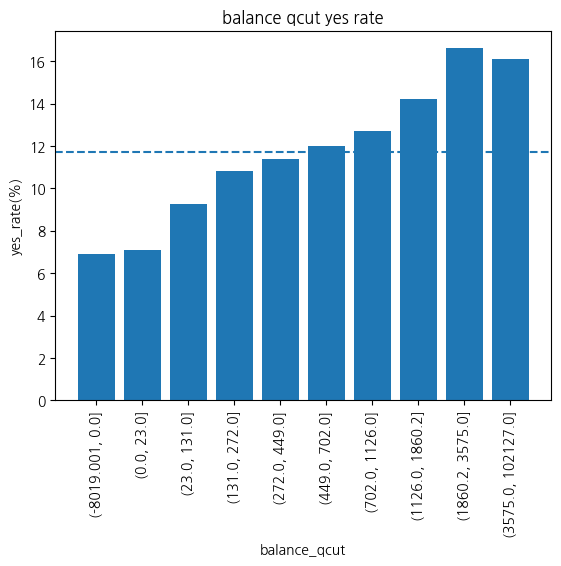

In [ ]:
balance_qcut_result = target_rate_table('balance_qcut').sort_values('balance_qcut')
plt.bar(balance_qcut_result['balance_qcut'].astype(str), balance_qcut_result['yes_rate(%)'])
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('balance qcut yes rate')
plt.xlabel('balance_qcut')
plt.ylabel('yes_rate(%)')
plt.xticks(rotation=90)
plt.show()

- 잔고가 높은 분위수 구간일수록 가입률이 높아지는 경향이 나타난다.

**3-15-2. age 분위수 구간별 가입률**

In [ ]:
df['age_qcut'] = pd.qcut(
    df['age'],
    q=10,
    duplicates='drop'
)
target_rate_table('age_qcut')

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


,age_qcut,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
9,"(56.0, 95.0]",4121,838,0.203349,20.334870,9.118265
0,"(17.999, 29.0]",5272,928,0.176024,17.602428,11.665007
1,"(29.0, 32.0]",5832,644,0.110425,11.042524,12.904082
3,"(34.0, 36.0]",3699,404,0.109219,10.921871,8.184534
2,"(32.0, 34.0]",3899,408,0.104642,10.464222,8.627061
4,"(36.0, 39.0]",4649,457,0.098301,9.830071,10.286536
8,"(51.0, 56.0]",4197,398,0.094830,9.482964,9.286425
7,"(46.0, 51.0]",4951,445,0.089881,8.988083,10.954752
6,"(42.0, 46.0]",4687,420,0.089610,8.960956,10.370616
5,"(39.0, 42.0]",3888,347,0.089249,8.924897,8.602722


/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


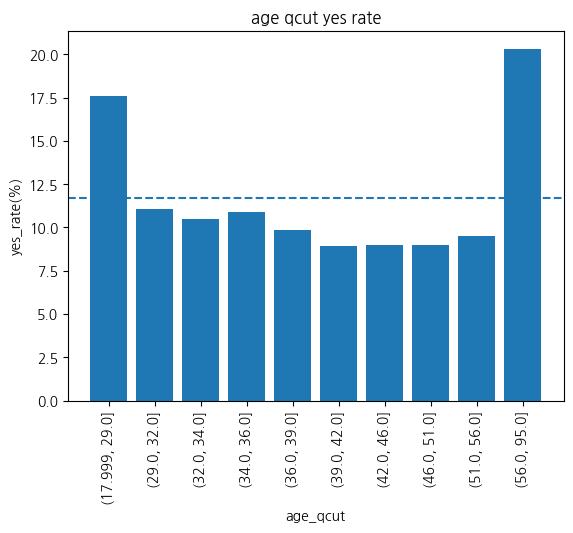

In [ ]:
age_qcut_result = target_rate_table('age_qcut').sort_values('age_qcut')
plt.bar(age_qcut_result['age_qcut'].astype(str), age_qcut_result['yes_rate(%)'])
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('age qcut yes rate')
plt.xlabel('age_qcut')
plt.ylabel('yes_rate(%)')
plt.xticks(rotation=90)
plt.show()

- 가장 높은 연령 구간과 가장 낮은 연령 구간의 가입률이 상대적으로 높다.
- 나이와 가입률은 단순 선형 관계가 아니라 U자형에 가까운 패턴을 보일 수 있다.

**3-15-3. campaign 분위수 구간별 가입률**

In [ ]:
df['campaign_qcut'] = pd.qcut(
    df['campaign'],
    q=10,
    duplicates='drop'
)
target_rate_table('campaign_qcut')

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


,campaign_qcut,total_count,yes_count,yes_rate,yes_rate(%),customer_ratio(%)
0,"(0.999, 2.0]",30036,3962,0.131908,13.190838,66.458679
1,"(2.0, 3.0]",5520,618,0.111957,11.195652,12.213740
2,"(3.0, 4.0]",3521,317,0.090031,9.003124,7.790685
3,"(4.0, 5.0]",1764,139,0.078798,7.879819,3.903087
4,"(5.0, 63.0]",4354,253,0.058107,5.810749,9.633809


/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()


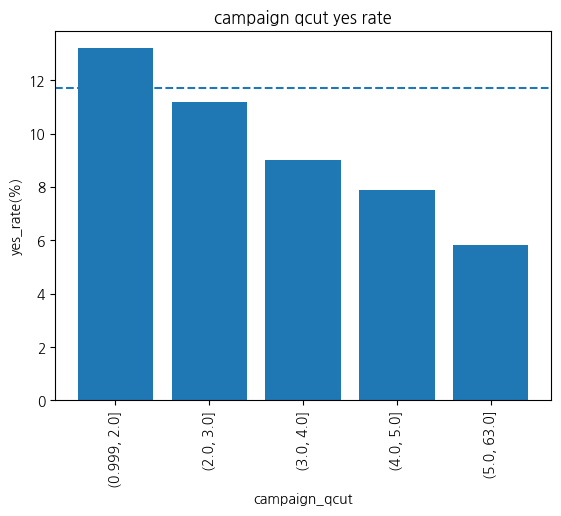

In [ ]:
campaign_qcut_result = target_rate_table('campaign_qcut').sort_values('campaign_qcut')
plt.bar(campaign_qcut_result['campaign_qcut'].astype(str), campaign_qcut_result['yes_rate(%)'])
plt.axhline(df['target'].mean() * 100, linestyle='--')
plt.title('campaign qcut yes rate')
plt.xlabel('campaign_qcut')
plt.ylabel('yes_rate(%)')
plt.xticks(rotation=90)
plt.show()

- 과도한 연락 여부는 가입 가능성을 낮추는 신호로 해석할 수 있다.

## 3-16. 가입률과 표본 수 같이 보기

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()
/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()
/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.gr

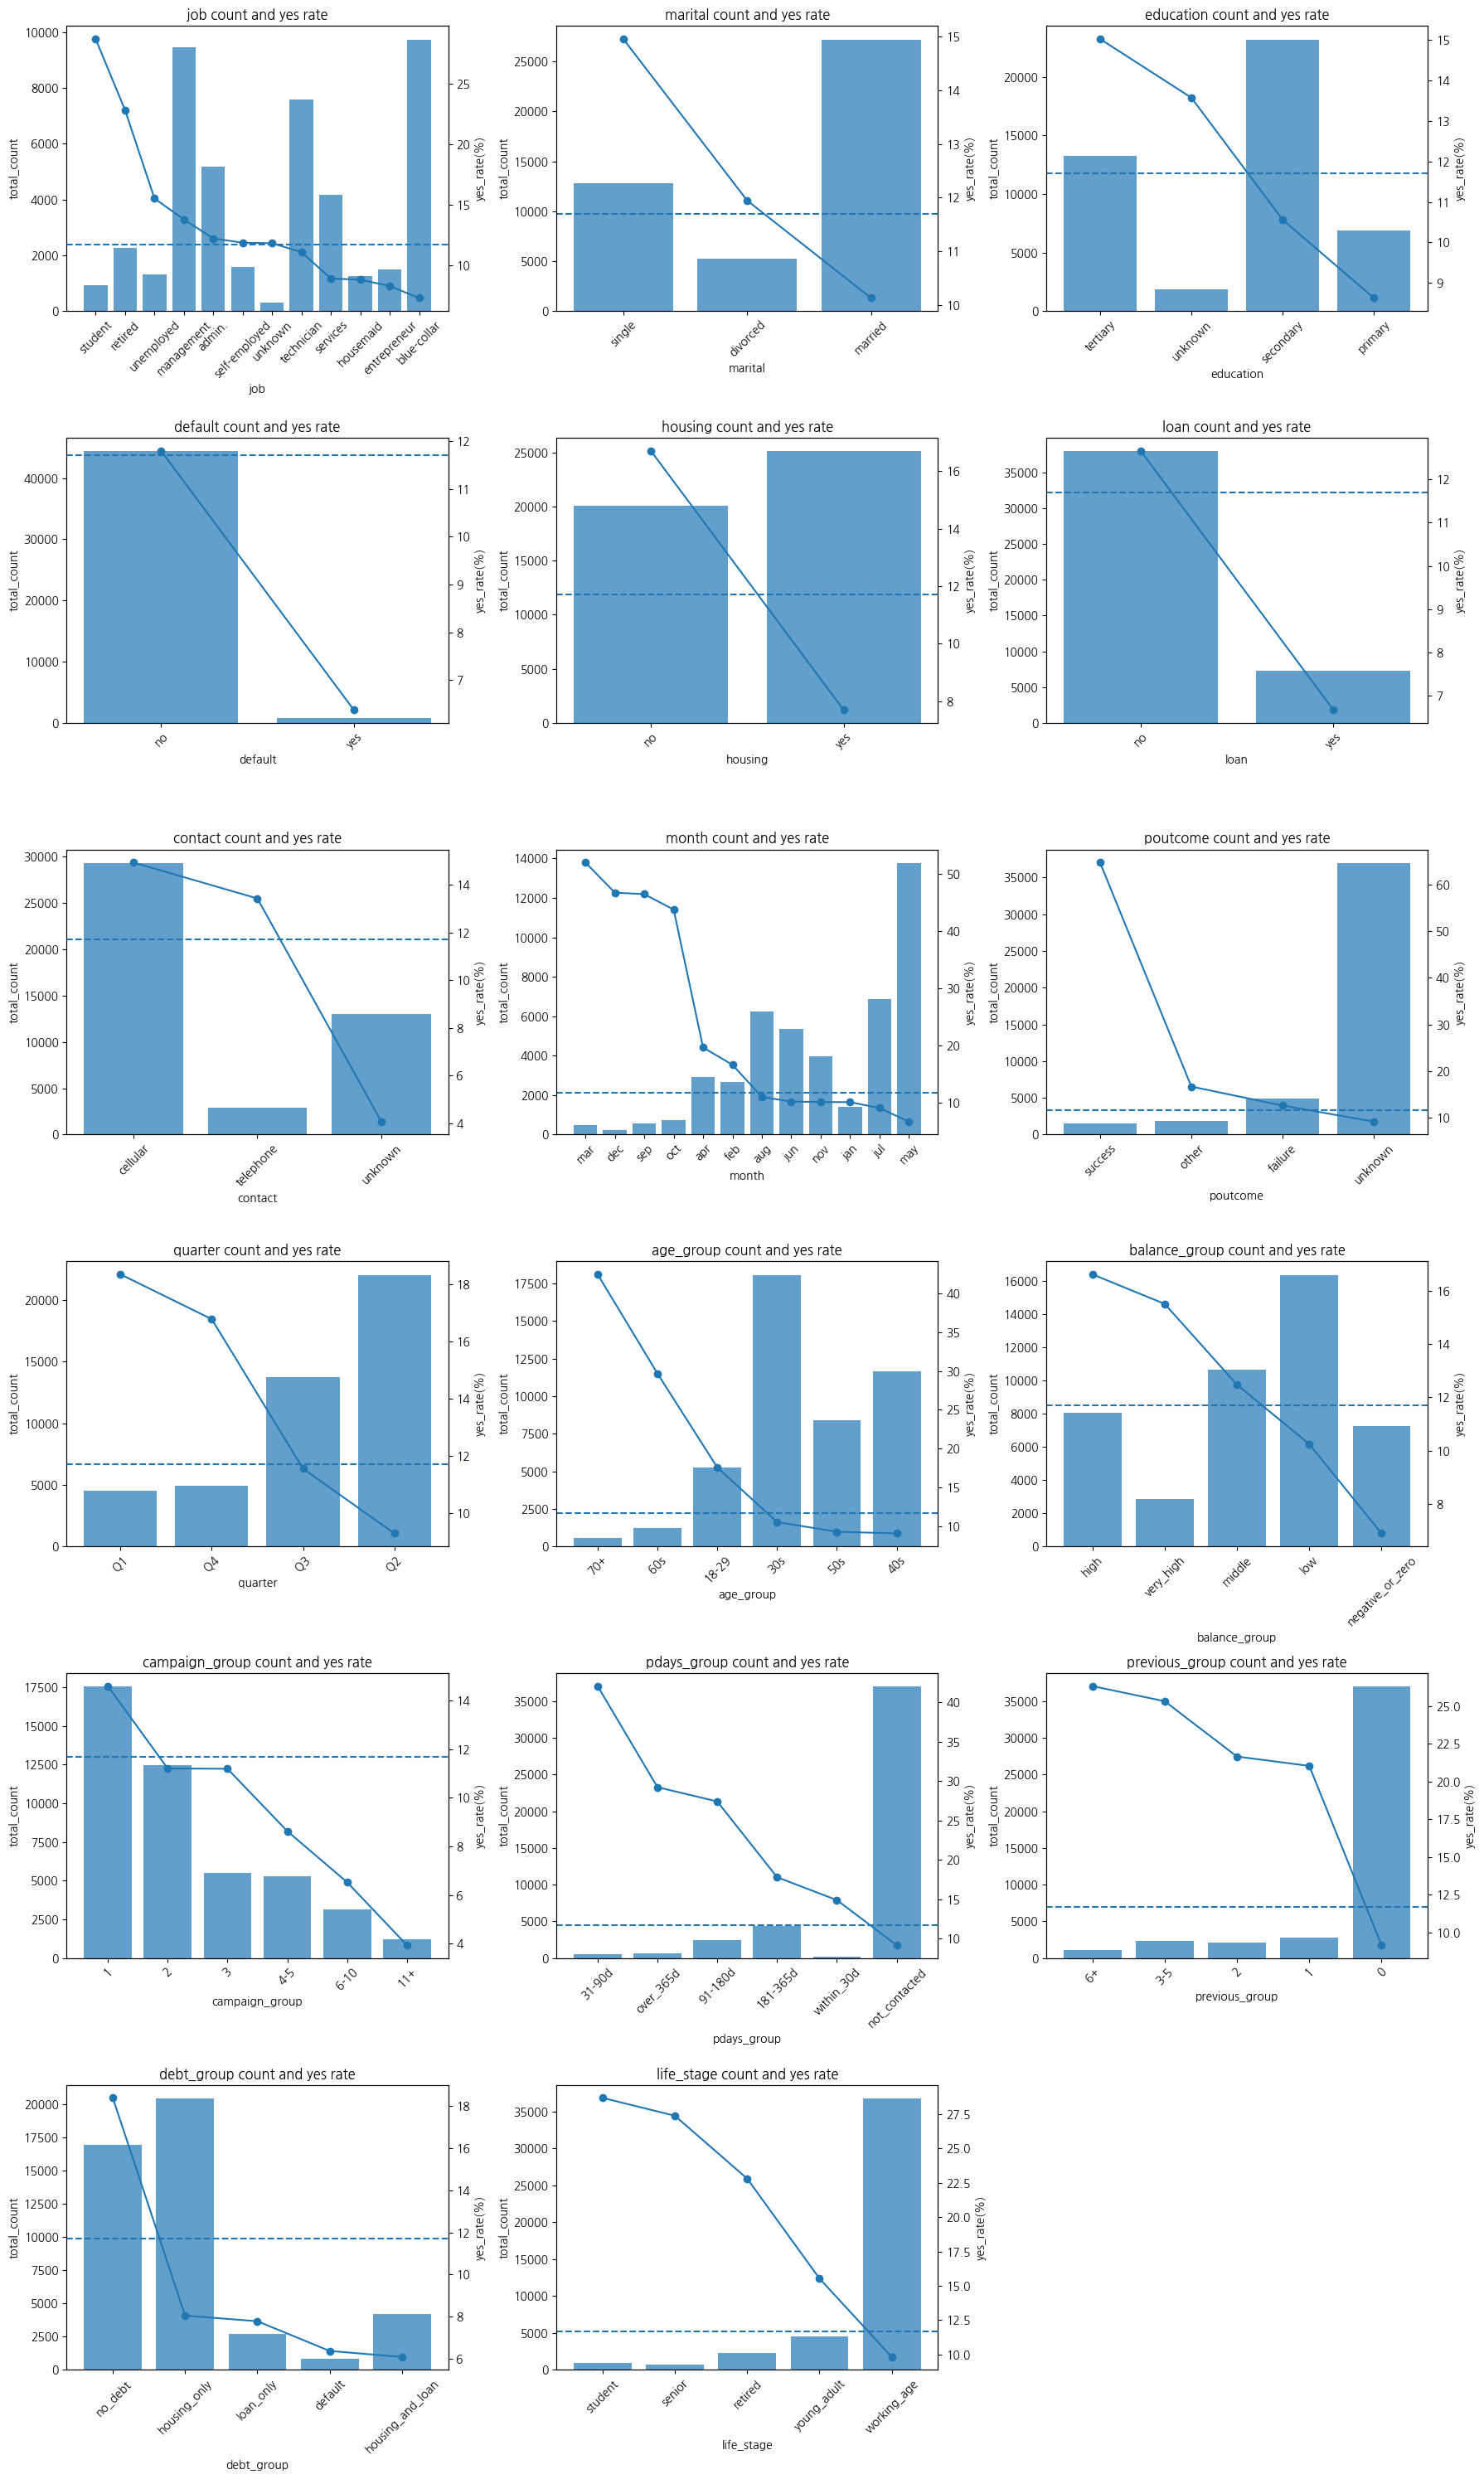

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    result = target_rate_table(col)

    ax1 = axes[i]

    ax1.bar(result[col].astype(str), result['total_count'], alpha=0.7)
    ax1.set_xlabel(col)
    ax1.set_ylabel('total_count')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_title(col + ' count and yes rate')

    ax2 = ax1.twinx()
    ax2.plot(result[col].astype(str), result['yes_rate(%)'], marker='o')
    ax2.axhline(df['target'].mean() * 100, linestyle='--')
    ax2.set_ylabel('yes_rate(%)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- 가입률이 높아도 고객 수가 매우 적은 범주는 전략적 중요도가 낮을 수 있다.

## 3-17. 모델링 관점에서 중요한 변수 후보 확인

In [ ]:
eda_importance = []
for col in categorical_cols:
    result = target_rate_table(col)
    max_rate = result['yes_rate(%)'].max()
    min_rate = result['yes_rate(%)'].min()
    gap = max_rate - min_rate

    eda_importance.append([col, max_rate, min_rate, gap])
eda_importance = pd.DataFrame(
    eda_importance,
    columns=['feature', 'max_yes_rate', 'min_yes_rate', 'rate_gap']
)
eda_importance.sort_values('rate_gap', ascending=False)

/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()
/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['target'].agg(['count', 'sum', 'mean']).reset_index()
/tmp/ipykernel_42085/3134894421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.gr

,feature,max_yes_rate,min_yes_rate,rate_gap
8,poutcome,64.725347,9.165471,55.559876
7,month,51.991614,6.720430,45.271184
10,age_group,42.418773,9.123680,33.295092
13,pdays_group,42.075472,9.161297,32.914174
0,job,28.678038,7.276465,21.401574
16,life_stage,28.678038,9.815500,18.862538
14,previous_group,26.315789,9.161297,17.154492
15,debt_group,18.374558,6.093529,12.281030
6,contact,14.926036,4.071286,10.854750
12,campaign_group,14.601745,3.929766,10.671979


- 범주형 변수마다 가장 높은 가입률과 가장 낮은 가입률의 차이를 계산해 변수별 가입률 격차를 비교한다.
- poutcome, pdays_group, contact, age_group, debt_group 등은 중요한 후보 변수로 볼 수 있다.

In [ ]:
ratio_diff_summary = []
for col in categorical_cols:
    result = target_ratio_diff(col)
    max_diff = result['diff_yes_minus_no'].max()
    min_diff = result['diff_yes_minus_no'].min()
    diff_gap = max_diff - min_diff

    ratio_diff_summary.append([col, max_diff, min_diff, diff_gap])
ratio_diff_summary = pd.DataFrame(
    ratio_diff_summary,
    columns=['feature', 'max_diff', 'min_diff', 'diff_gap']
)
ratio_diff_summary.sort_values('diff_gap', ascending=False)

,feature,max_diff,min_diff,diff_gap
4,housing,21.528702,-21.528702,43.057404
6,contact,20.203764,-21.272742,41.476506
15,debt_group,24.258738,-15.974254,40.232992
8,poutcome,17.155569,-20.070448,37.226018
13,pdays_group,8.346273,-20.100745,28.447018
14,previous_group,6.746917,-20.100745,26.847662
16,life_stage,5.378310,-14.849515,20.227825
7,month,5.067071,-14.683978,19.751049
1,marital,8.916501,-9.187258,18.103759
9,quarter,6.445078,-11.368336,17.813414


- 범주별 비중 차이 함수 결과를 이용해, 각 변수에서 가입자와 비가입자의 구성 차이가 얼마나 큰지 확인한다.
- housing, contact, debt_group, poutcome 등이 가입자와 비가입자 구성 차이가 큰 변수로 나타난다.

# 4\. 모델링

## 4-1. 학습용 / 검증용 데이터 분리

In [ ]:
y = df['target']

- 예측해야 하는 정답 변수인 target을 y로 분리한다. (target=0은 정기예금 미가입, target=1은 정기예금 가입을 의미)

In [ ]:
drop_cols = [
    'y',
    'target'
]

X = df.drop(columns=drop_cols).copy()

- 모델 학습에 사용하지 않을 컬럼인 원본 타깃값 y와 숫자로 변환한 타깃값 target을 제거하고, 나머지 컬럼을 입력 변수 X로 만든다.

In [ ]:
for col in X.select_dtypes(include=['category']).columns:
    X[col] = X[col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train 비율')
print(y_train.value_counts(normalize=True))
print('y_test 비율')
print(y_test.value_counts(normalize=True))

X_train: (31636, 40)
X_test: (13559, 40)
y_train 비율
target
0    0.882981
1    0.117019
Name: proportion, dtype: float64
y_test 비율
target
0    0.882956
1    0.117044
Name: proportion, dtype: float64


- category 타입 컬럼을 문자열로 변환한 뒤, 데이터를 학습용 70%, 테스트용 30%로 나눈다.  
- stratify=y를 사용해 학습 데이터와 테스트 데이터의 가입/미가입 비율이 원본 데이터와 비슷하게 유지되도록 했다.
- 학습 데이터는 31,636행, 테스트 데이터는 13,559행으로 나뉘었다.

## 4-2. 전처리 파이프라인 및 평가 함수 생성

In [ ]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('수치형 변수 개수:', len(numeric_features))
print(numeric_features)
print('범주형 변수 개수:', len(categorical_features))
print(categorical_features)

수치형 변수 개수: 20
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'month_num', 'is_high_campaign', 'has_previous_contact', 'pdays_clean', 'pdays_for_model', 'was_previous_success', 'housing_num', 'loan_num', 'default_num', 'loan_count', 'job_is_unknown', 'education_is_unknown', 'contact_is_unknown', 'poutcome_is_unknown']
범주형 변수 개수: 20
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'quarter', 'age_group', 'balance_group', 'campaign_group', 'pdays_group', 'previous_group', 'debt_group', 'life_stage', 'balance_qcut', 'age_qcut', 'campaign_qcut']


- 수치형 변수 20개, 범주형 변수 20개가 확인되었다.
- 수치형 변수는 스케일링 대상이고, 범주형 변수는 원-핫 인코딩 대상이다.

In [ ]:
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=['no', 'yes'],
        output_dict=True
    )

    result = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_no': report['no']['f1-score'],
        'f1_yes': report['yes']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score']
    }

    print(model_name)
    print('-' * 60)
    print(classification_report(
        y_test,
        y_pred,
        target_names=['no', 'yes'],
        digits=3
    ))
    print('Confusion Matrix')
    print(confusion_matrix(y_test, y_pred))

    return result

- 수치형 변수는 결측값을 중앙값으로 대체한 뒤 표준화하고, 범주형 변수는 최빈값으로 결측값을 대체한 뒤 원-핫 인코딩한다.  
- ColumnTransformer로 수치형/범주형 전처리를 하나로 묶고, evaluate_model() 함수로 모델별 성능을 같은 방식으로 평가할 수 있게 한다.

## 4-3. 기준 모델: 로지스틱 회귀

In [ ]:
baseline_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_lr.fit(X_train, y_train)

results = []
results.append(evaluate_model(baseline_lr, X_test, y_test, 'Baseline Logistic Regression'))

Baseline Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.901     0.985     0.941     11972
         yes      0.624     0.184     0.284      1587

    accuracy                          0.892     13559
   macro avg      0.763     0.585     0.613     13559
weighted avg      0.869     0.892     0.864     13559

Confusion Matrix
[[11796   176]
 [ 1295   292]]


- 전처리 파이프라인과 로지스틱 회귀를 하나로 묶어 기준 모델을 만든다.  
- 이 모델은 별도의 불균형 보정 없이 기본 설정으로 학습된다.

  - Accuracy는 약 0.892로 높지만, 가입자 F1-score는 약 0.284로 낮다.
  - 혼동행렬을 보면 실제 가입자 1,587명 중 292명만 가입자로 맞추고 1,295명은 놓쳤다.
  - 따라서 단순 Accuracy는 높아도 가입자 탐지 성능은 부족하다.

## 4-4. 개선 1: class_weight 적용 로지스틱 회귀

In [ ]:
balanced_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

balanced_lr.fit(X_train, y_train)

results.append(evaluate_model(balanced_lr, X_test, y_test, 'Balanced Logistic Regression'))

Balanced Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.944     0.784     0.857     11972
         yes      0.284     0.646     0.395      1587

    accuracy                          0.768     13559
   macro avg      0.614     0.715     0.626     13559
weighted avg      0.866     0.768     0.803     13559

Confusion Matrix
[[9391 2581]
 [ 562 1025]]


- 로지스틱 회귀에 class_weight='balanced'를 적용한다. (데이터에서 적은 클래스인 가입자를 더 중요하게 학습하도록 가중치를 주는 방식)
  - 가입자 recall은 0.65까지 크게 올랐지만, Accuracy는 약 0.768로 떨어졌다.  
  - 가입자를 더 많이 잡아내는 대신 비가입자를 가입자로 잘못 예측하는 경우가 많아졌다.
  - 즉, 가입자 탐지는 개선됐지만 전체 정확도 손실이 크다.

## 4-5. 개선 2: 모델 다양화

### 4-5-1. Decision Tree

In [ ]:
fitted_models = {}

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

dt_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', dt_model)
])

dt_pipe.fit(X_train, y_train)

fitted_models['Decision Tree'] = dt_pipe
results.append(evaluate_model(dt_pipe, X_test, y_test, 'Decision Tree'))

Decision Tree
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.936     0.840     0.886     11972
         yes      0.320     0.568     0.410      1587

    accuracy                          0.808     13559
   macro avg      0.628     0.704     0.648     13559
weighted avg      0.864     0.808     0.830     13559

Confusion Matrix
[[10061  1911]
 [  686   901]]


- max_depth, min_samples_leaf로 트리의 복잡도를 제한하고, class_weight='balanced'로 가입자 클래스에 가중치를 준다.
  - Accuracy는 약 0.808, 가입자 F1-score는 약 0.410이다.  
  - 기본 요구사항인 Accuracy 0.80 이상과 가입자 F1-score 0.40 이상은 만족하지만, 심화 기준에는 부족하다.

### 4-5-2. Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', rf_model)
])

rf_pipe.fit(X_train, y_train)

fitted_models['Random Forest'] = rf_pipe
results.append(evaluate_model(rf_pipe, X_test, y_test, 'Random Forest'))

Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.941     0.859     0.898     11972
         yes      0.357     0.590     0.445      1587

    accuracy                          0.827     13559
   macro avg      0.649     0.725     0.671     13559
weighted avg      0.872     0.827     0.845     13559

Confusion Matrix
[[10281  1691]
 [  650   937]]


- 여러 개의 결정트리를 조합해 예측 안정성을 높이고, 클래스 불균형을 고려하기 위해 class_weight='balanced'를 적용한다.
  - Accuracy는 약 0.827, 가입자 F1-score는 약 0.445로 현재까지 가장 좋은 가입자 F1-score를 보인다.  
  - 가입자 recall도 약 0.590으로 높아, 단일 결정트리보다 안정적으로 가입자를 탐지한다.

### 4-5-3. Extra Trees

In [ ]:
et_model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

et_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', et_model)
])

et_pipe.fit(X_train, y_train)

fitted_models['Extra Trees'] = et_pipe
results.append(evaluate_model(et_pipe, X_test, y_test, 'Extra Trees'))

Extra Trees
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.942     0.837     0.886     11972
         yes      0.331     0.609     0.429      1587

    accuracy                          0.810     13559
   macro avg      0.636     0.723     0.657     13559
weighted avg      0.870     0.810     0.833     13559

Confusion Matrix
[[10016  1956]
 [  620   967]]


- Random Forest와 유사하지만 분할 기준에 더 많은 무작위성을 넣어 다양한 트리를 만든다.
  - Accuracy는 약 0.810, 가입자 F1-score는 약 0.429이다.  
  - 가입자 recall은 0.609로 높지만 precision이 낮아 F1-score가 Random Forest보다 조금 낮다.

### 4-5-4. Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', gb_model)
])

gb_pipe.fit(X_train, y_train)

fitted_models['Gradient Boosting'] = gb_pipe
results.append(evaluate_model(gb_pipe, X_test, y_test, 'Gradient Boosting'))

Gradient Boosting
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.903     0.983     0.941     11972
         yes      0.612     0.201     0.303      1587

    accuracy                          0.892     13559
   macro avg      0.758     0.592     0.622     13559
weighted avg      0.869     0.892     0.866     13559

Confusion Matrix
[[11770   202]
 [ 1268   319]]


- Accuracy는 약 0.892로 높지만, 가입자 F1-score는 약 0.303으로 낮다.  
- 비가입자는 매우 잘 맞추지만 가입자 recall이 0.201에 그쳐, 이 데이터의 핵심 목표인 가입자 탐지에는 부족하다.

### 4-5-5. 모델 성능 비교

In [ ]:
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

result_df

,model,accuracy,f1_no,f1_yes,macro_f1,weighted_f1
0,Random Forest,0.827347,0.897786,0.444603,0.671194,0.844744
1,Extra Trees,0.810015,0.886058,0.428825,0.657441,0.832542
2,Decision Tree,0.808467,0.885690,0.409639,0.647664,0.829971
3,Balanced Logistic Regression,0.768198,0.856648,0.394762,0.625705,0.802587
4,Gradient Boosting,0.891585,0.941224,0.302657,0.621940,0.866483
5,Baseline Logistic Regression,0.891511,0.941308,0.284185,0.612746,0.864396


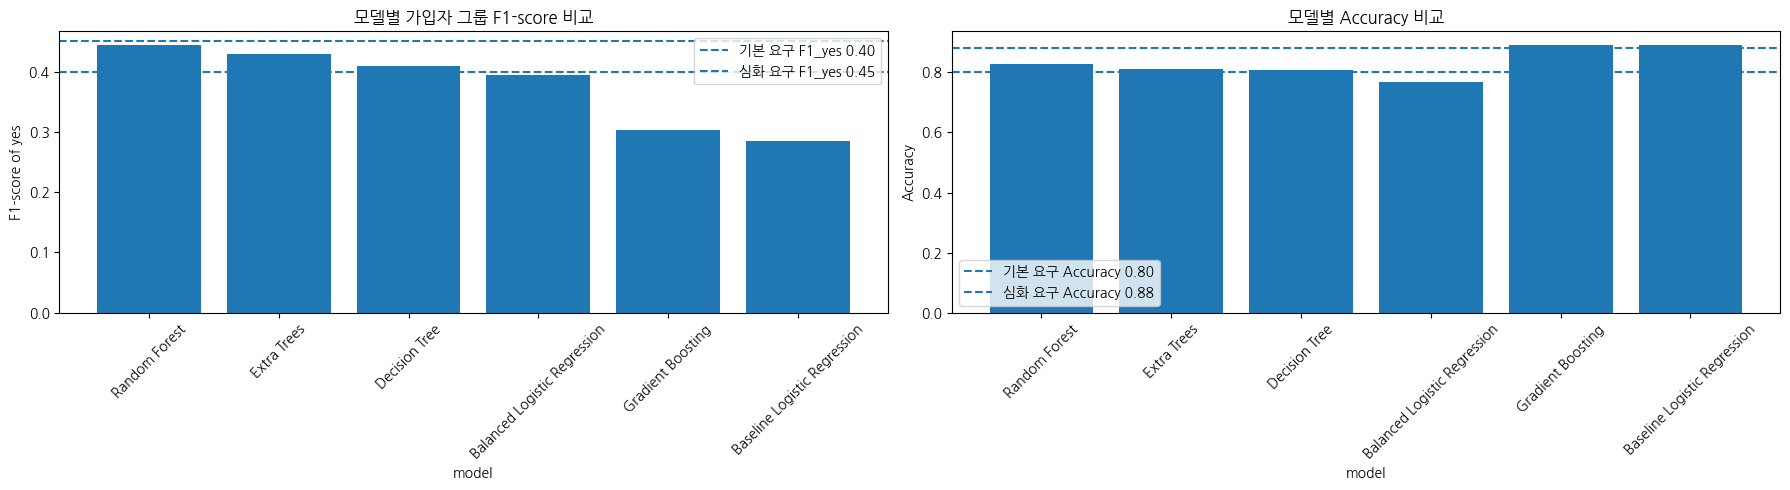

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(result_df['model'], result_df['f1_yes'])
axes[0].axhline(0.40, linestyle='--', label='기본 요구 F1_yes 0.40')
axes[0].axhline(0.45, linestyle='--', label='심화 요구 F1_yes 0.45')
axes[0].set_title('모델별 가입자 그룹 F1-score 비교')
axes[0].set_xlabel('model')
axes[0].set_ylabel('F1-score of yes')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(result_df['model'], result_df['accuracy'])
axes[1].axhline(0.80, linestyle='--', label='기본 요구 Accuracy 0.80')
axes[1].axhline(0.88, linestyle='--', label='심화 요구 Accuracy 0.88')
axes[1].set_title('모델별 Accuracy 비교')
axes[1].set_xlabel('model')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

- 현재까지는 Random Forest가 가입자 F1-score 기준으로 가장 우수하다.
- 기본 로지스틱 회귀와 Gradient Boosting은 Accuracy가 높다.
- 다만 Accuracy 0.88 이상과 가입자 F1-score 0.45 이상을 동시에 만족하는 심화 기준에는 아직 도달하지 못했다.

## 4-6. 개선 3: 분류 임계값 조정

In [ ]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

def threshold_result_table(model, X_eval, y_eval, thresholds):
    proba = model.predict_proba(X_eval)[:, 1]

    rows = []
    for th in thresholds:
        y_pred = (proba >= th).astype(int)
        report = classification_report(
            y_eval,
            y_pred,
            target_names=['no', 'yes'],
            output_dict=True,
            zero_division=0
        )

        rows.append({
            'threshold': th,
            'accuracy': accuracy_score(y_eval, y_pred),
            'f1_no': report['no']['f1-score'],
            'f1_yes': report['yes']['f1-score'],
            'macro_f1': report['macro avg']['f1-score'],
            'yes_precision': report['yes']['precision'],
            'yes_recall': report['yes']['recall']
        })

    return pd.DataFrame(rows)

- validation set은 threshold를 고르는 용도로만 사용하고, 최종 test set은 마지막 평가에만 사용한다.
- 또한 threshold별 성능을 계산하는 함수를 정의한다.
- test set에서 threshold를 고르면 test에 과적합될 수 있으므로, train 내부 validation에서 threshold를 선택하는 방식이 더 적절하다.

In [ ]:
threshold_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

threshold_model.fit(X_fit, y_fit)

thresholds = np.arange(0.10, 0.91, 0.01)
valid_thresholds = threshold_result_table(threshold_model, X_valid, y_valid, thresholds)

- class_weight를 적용한 로지스틱 회귀를 X_fit으로 학습하고, X_valid에서 threshold 0.10~0.90까지 성능을 비교한다.

In [ ]:
valid_over_80 = valid_thresholds[valid_thresholds['accuracy'] >= 0.80]

best_threshold = valid_over_80.sort_values(
    ['f1_yes', 'accuracy'],
    ascending=False
).iloc[0]['threshold']

best_threshold

np.float64(0.6199999999999998)

- Accuracy가 0.80 이상인 threshold 후보만 남긴 뒤, 그중 가입자 F1-score가 가장 높은 threshold를 선택한다.
  - 선택된 threshold는 약 0.62이다.  
  - 기본 0.50보다 높은 기준을 적용했다는 뜻이며, 이 경우 가입자로 예측하는 기준을 조금 더 엄격하게 조정한 것이다.

In [ ]:
valid_thresholds.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10)

,threshold,accuracy,f1_no,f1_yes,macro_f1,yes_precision,yes_recall
52,0.62,0.863464,0.921852,0.460000,0.690926,0.427907,0.497297
51,0.61,0.859671,0.919390,0.458537,0.688963,0.417778,0.508108
53,0.63,0.865360,0.923202,0.454545,0.688874,0.431873,0.479730
50,0.60,0.854930,0.916363,0.453571,0.684967,0.405319,0.514865
54,0.64,0.867731,0.924791,0.451866,0.688329,0.438374,0.466216
56,0.66,0.872472,0.927876,0.449898,0.688887,0.453920,0.445946
48,0.58,0.845765,0.910327,0.449210,0.679769,0.385659,0.537838
49,0.59,0.849874,0.913099,0.448956,0.681028,0.393293,0.522973
55,0.65,0.869943,0.926274,0.448761,0.687518,0.444887,0.452703
47,0.57,0.840866,0.907078,0.446399,0.676738,0.376274,0.548649


- threshold별 성능표를 가입자 F1-score 기준으로 정렬해 상위 10개 후보를 확인한다.
  - validation 기준으로 threshold 0.62에서 가입자 F1-score가 약 0.460으로 가장 높다.  
  - 이때 Accuracy는 약 0.863으로 기본 요구 Accuracy 0.80은 넘지만, 심화 Accuracy 0.88에는 부족하다.

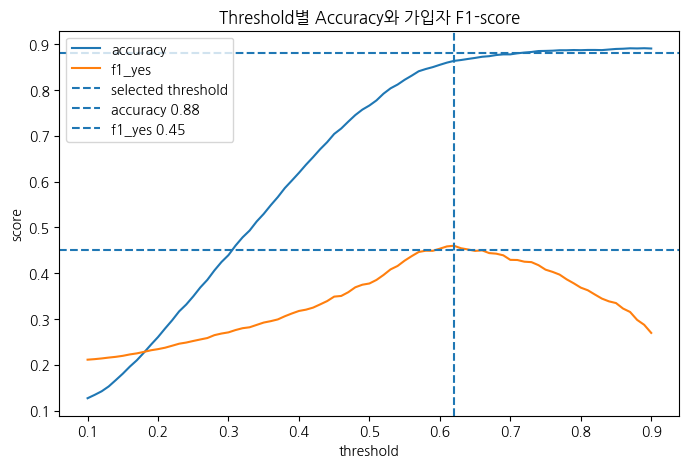

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(valid_thresholds['threshold'], valid_thresholds['accuracy'], label='accuracy')
plt.plot(valid_thresholds['threshold'], valid_thresholds['f1_yes'], label='f1_yes')
plt.axvline(best_threshold, linestyle='--', label='selected threshold')
plt.axhline(0.88, linestyle='--', label='accuracy 0.88')
plt.axhline(0.45, linestyle='--', label='f1_yes 0.45')
plt.title('Threshold별 Accuracy와 가입자 F1-score')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.show()

- threshold를 조정하면 Accuracy와 가입자 F1-score가 함께 변한다.  
- threshold를 너무 낮추거나 높이면 한쪽 지표가 손상될 수 있음을 확인할 수 있다.

In [ ]:
final_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

final_lr.fit(X_train, y_train)

test_proba = final_lr.predict_proba(X_test)[:, 1]
test_pred_threshold = (test_proba >= best_threshold).astype(int)

print('Selected threshold:', best_threshold)
print(classification_report(
    y_test,
    test_pred_threshold,
    target_names=['no', 'yes'],
    digits=3
))
print('Confusion Matrix')
print(confusion_matrix(y_test, test_pred_threshold))

threshold_final_result = classification_report(
    y_test,
    test_pred_threshold,
    target_names=['no', 'yes'],
    output_dict=True,
    zero_division=0
)

results.append({
    'model': 'Balanced Logistic Regression + Threshold',
    'accuracy': accuracy_score(y_test, test_pred_threshold),
    'f1_no': threshold_final_result['no']['f1-score'],
    'f1_yes': threshold_final_result['yes']['f1-score'],
    'macro_f1': threshold_final_result['macro avg']['f1-score'],
    'weighted_f1': threshold_final_result['weighted avg']['f1-score']
})

final_result_df = pd.DataFrame(results)
final_result_df = final_result_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

final_result_df

Selected threshold: 0.6199999999999998
              precision    recall  f1-score   support

          no      0.931     0.901     0.916     11972
         yes      0.402     0.500     0.445      1587

    accuracy                          0.854     13559
   macro avg      0.667     0.701     0.681     13559
weighted avg      0.869     0.854     0.861     13559

Confusion Matrix
[[10791  1181]
 [  794   793]]


,model,accuracy,f1_no,f1_yes,macro_f1,weighted_f1
0,Balanced Logistic Regression + Threshold,0.854340,0.916161,0.445381,0.680771,0.861059
1,Balanced Logistic Regression + Threshold,0.854340,0.916161,0.445381,0.680771,0.861059
2,Random Forest,0.827347,0.897786,0.444603,0.671194,0.844744
3,Extra Trees,0.810015,0.886058,0.428825,0.657441,0.832542
4,Decision Tree,0.808467,0.885690,0.409639,0.647664,0.829971
5,Balanced Logistic Regression,0.768198,0.856648,0.394762,0.625705,0.802587
6,Gradient Boosting,0.891585,0.941224,0.302657,0.621940,0.866483
7,Baseline Logistic Regression,0.891511,0.941308,0.284185,0.612746,0.864396


- validation에서 선택한 threshold 0.62를 사용해 로지스틱 회귀 모델을 전체 학습 데이터로 다시 학습하고, test set에서 최종 평가한다.
  - Accuracy는 약 0.854, 가입자 F1-score는 약 0.445로 개선되었다.  
  - 기본 로지스틱 회귀의 가입자 F1-score 0.284와 비교하면 threshold 조정 효과가 크지만, 심화 기준 Accuracy 0.88에는 아직 부족하다.

## 4-7. 개선 4: RandomForest 하이퍼파라미터 튜닝

In [ ]:
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [6, 10, 12, 16, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print('Best Params:')
print(rf_search.best_params_)
print('Best CV F1:', rf_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params:
{'model__n_estimators': 300, 'model__min_samples_split': 20, 'model__min_samples_leaf': 10, 'model__max_features': None, 'model__max_depth': None}
Best CV F1: 0.46721409693012167


- Random Forest의 주요 하이퍼파라미터 후보를 정의하고, RandomizedSearchCV로 20개 조합을 3-fold 교차검증한다.  
- 평가 기준은 가입자 클래스에 대한 F1-score를 높이기 위해 scoring='f1'로 설정했다.
  - 최적 파라미터는 n_estimators=300, min_samples_split=20, min_samples_leaf=10, max_features=None, max_depth=None으로 선택되었다.  
  - 교차검증 기준 best F1은 약 0.467이다.

In [ ]:
best_rf = rf_search.best_estimator_

results.append(evaluate_model(best_rf, X_test, y_test, 'Tuned Random Forest'))

final_result_df = pd.DataFrame(results)
final_result_df = final_result_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

final_result_df

Tuned Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.936     0.911     0.923     11972
         yes      0.440     0.530     0.481      1587

    accuracy                          0.866     13559
   macro avg      0.688     0.720     0.702     13559
weighted avg      0.878     0.866     0.871     13559

Confusion Matrix
[[10902  1070]
 [  746   841]]


,model,accuracy,f1_no,f1_yes,macro_f1,weighted_f1
0,Tuned Random Forest,0.866067,0.923116,0.480846,0.701981,0.871351
1,Balanced Logistic Regression + Threshold,0.854340,0.916161,0.445381,0.680771,0.861059
2,Balanced Logistic Regression + Threshold,0.854340,0.916161,0.445381,0.680771,0.861059
3,Random Forest,0.827347,0.897786,0.444603,0.671194,0.844744
4,Extra Trees,0.810015,0.886058,0.428825,0.657441,0.832542
5,Decision Tree,0.808467,0.885690,0.409639,0.647664,0.829971
6,Balanced Logistic Regression,0.768198,0.856648,0.394762,0.625705,0.802587
7,Gradient Boosting,0.891585,0.941224,0.302657,0.621940,0.866483
8,Baseline Logistic Regression,0.891511,0.941308,0.284185,0.612746,0.864396


- 랜덤 탐색으로 찾은 최적 Random Forest 모델을 test set에서 평가한 후 이전 모델들과 비교한다.
  - Tuned Random Forest는 Accuracy 약 0.866, 가입자 F1-score 약 0.481로 현재까지 가장 좋은 성능이다.  
  - 기본 요구사항은 충분히 만족하지만, Accuracy 0.88 이상이라는 심화 조건에는 아직 조금 부족하다.

## 4-8. 개선 5: Tuned Random Forest에도 threshold 조정 적용

In [ ]:
def evaluate_model_detail_from_pred(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'yes_precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'yes_recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_yes': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_no': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

def evaluate_model_detail(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    result = evaluate_model_detail_from_pred(y_test, y_pred, model_name)

    print(model_name)
    print('-' * 60)
    print(classification_report(
    y_test,
    y_pred,
    target_names=['no', 'yes'],
    zero_division=0,
    digits=3
    ))
    print('Confusion Matrix')
    print(confusion_matrix(y_test, y_pred))

    return result

- 예측값을 기준으로 상세 성능 지표를 계산하는 함수와, 모델 객체를 받아 예측 및 평가까지 수행하는 함수를 정의한다.

In [ ]:
detail_results = []

detail_results.append(evaluate_model_detail(baseline_lr, X_test, y_test, 'Baseline Logistic Regression'))
detail_results.append(evaluate_model_detail(balanced_lr, X_test, y_test, 'Balanced Logistic Regression'))

for name, model in fitted_models.items():
    detail_results.append(evaluate_model_detail(model, X_test, y_test, name))

Baseline Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.901     0.985     0.941     11972
         yes      0.624     0.184     0.284      1587

    accuracy                          0.892     13559
   macro avg      0.763     0.585     0.613     13559
weighted avg      0.869     0.892     0.864     13559

Confusion Matrix
[[11796   176]
 [ 1295   292]]
Balanced Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.944     0.784     0.857     11972
         yes      0.284     0.646     0.395      1587

    accuracy                          0.768     13559
   macro avg      0.614     0.715     0.626     13559
weighted avg      0.866     0.768     0.803     13559

Confusion Matrix
[[9391 2581]
 [ 562 1025]]
Decision Tree
------------------------------------------------------------

- 기존에 학습한 기준 모델, balanced 로지스틱 회귀, 트리/앙상블 모델들을 새 평가 함수로 다시 평가한다.
  - 기존 결과와 같은 흐름이 재확인된다.  
  - 기본 로지스틱 회귀와 Gradient Boosting은 Accuracy는 높지만 가입자 recall이 낮고, Random Forest/Extra Trees는 가입자를 더 많이 잡아내지만 Accuracy가 상대적으로 낮다.

In [ ]:
detail_results.append(
    evaluate_model_detail_from_pred(
        y_test,
        test_pred_threshold,
        'Balanced Logistic Regression + Threshold'
    )
)

- threshold를 적용한 로지스틱 회귀 결과를 상세 지표 목록에 추가한다.

In [ ]:
detail_results.append(evaluate_model_detail(best_rf, X_test, y_test, 'Tuned Random Forest'))

detail_result_df = pd.DataFrame(detail_results)
detail_result_df = detail_result_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

detail_result_df

Tuned Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.936     0.911     0.923     11972
         yes      0.440     0.530     0.481      1587

    accuracy                          0.866     13559
   macro avg      0.688     0.720     0.702     13559
weighted avg      0.878     0.866     0.871     13559

Confusion Matrix
[[10902  1070]
 [  746   841]]


,model,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
0,Tuned Random Forest,0.866067,0.440084,0.529931,0.480846,0.923116,0.701981,0.871351
1,Balanced Logistic Regression + Threshold,0.854340,0.401722,0.499685,0.445381,0.916161,0.680771,0.861059
2,Random Forest,0.827347,0.356545,0.590422,0.444603,0.897786,0.671194,0.844744
3,Extra Trees,0.810015,0.330824,0.609326,0.428825,0.886058,0.657441,0.832542
4,Decision Tree,0.808467,0.320413,0.567738,0.409639,0.885690,0.647664,0.829971
5,Balanced Logistic Regression,0.768198,0.284248,0.645873,0.394762,0.856648,0.625705,0.802587
6,Gradient Boosting,0.891585,0.612284,0.201008,0.302657,0.941224,0.621940,0.866483
7,Baseline Logistic Regression,0.891511,0.623932,0.183995,0.284185,0.941308,0.612746,0.864396


- 튜닝된 Random Forest 결과를 목록에 추가한다.
  - Tuned Random Forest가 가입자 F1-score 약 0.481로 가장 높다.  
  - 하지만 Accuracy는 약 0.866으로 심화 기준 0.88에는 못 미친다.

In [ ]:
def get_positive_proba(model, X):
    class_list = list(model.classes_)
    positive_index = class_list.index(1)
    return model.predict_proba(X)[:, positive_index]

def threshold_result_table_from_model(model, X_eval, y_eval, thresholds):
    proba = get_positive_proba(model, X_eval)

    rows = []
    for th in thresholds:
        y_pred = (proba >= th).astype(int)

        rows.append({
            'threshold': th,
            'accuracy': accuracy_score(y_eval, y_pred),
            'yes_precision': precision_score(y_eval, y_pred, pos_label=1, zero_division=0),
            'yes_recall': recall_score(y_eval, y_pred, pos_label=1, zero_division=0),
            'f1_yes': f1_score(y_eval, y_pred, pos_label=1, zero_division=0),
            'f1_no': f1_score(y_eval, y_pred, pos_label=0, zero_division=0),
            'macro_f1': f1_score(y_eval, y_pred, average='macro', zero_division=0),
            'weighted_f1': f1_score(y_eval, y_pred, average='weighted', zero_division=0)
        })

    return pd.DataFrame(rows)

def choose_threshold(threshold_df, min_accuracy=0.88):
    candidate = threshold_df[threshold_df['accuracy'] >= min_accuracy].copy()

    if len(candidate) == 0:
        candidate = threshold_df[threshold_df['accuracy'] >= 0.80].copy()

    return candidate.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]

- 모델의 predict_proba() 결과에서 가입자 클래스의 확률만 안전하게 가져오는 함수와, threshold별 성능표를 만드는 함수를 정의한다.  
- 최소 Accuracy 조건을 만족하는 후보 중 가입자 F1-score가 가장 높은 threshold를 선택하는 함수도 정의한다.

In [ ]:
best_rf_params = {
    key.replace('model__', ''): value
    for key, value in rf_search.best_params_.items()
}

rf_threshold_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

- 앞서 찾은 Random Forest 최적 파라미터에서 실제 모델 생성에 사용할 수 있는 형태로 바꾼다.  
- 그 후 threshold 탐색용 Random Forest 파이프라인을 만든다.

In [ ]:
rf_threshold_model.fit(X_fit, y_fit)

thresholds = np.arange(0.10, 0.91, 0.01)

rf_valid_thresholds = threshold_result_table_from_model(
    rf_threshold_model,
    X_valid,
    y_valid,
    thresholds
)

rf_best_threshold_row = choose_threshold(rf_valid_thresholds, min_accuracy=0.88)
rf_best_threshold = rf_best_threshold_row['threshold']

rf_best_threshold_row

,51
threshold,0.610000
accuracy,0.880373
yes_precision,0.486400
yes_recall,0.410811
f1_yes,0.445421
f1_no,0.932955
macro_f1,0.689188
weighted_f1,0.875943


- Random Forest를 X_fit으로 학습하고, X_valid에서 threshold별 성능을 계산한다.  
- 그중 Accuracy 조건을 만족하면서 가입자 F1-score가 높은 threshold를 선택한다.
  - 선택된 threshold는 약 0.61이다.
  - validation 기준 Accuracy는 약 0.880, 가입자 F1-score는 약 0.445로 Accuracy 0.88 기준은 넘었지만 F1-score 0.45에는 조금 부족하다.

In [ ]:
rf_valid_thresholds.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10)

,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
43,0.53,0.873104,0.458388,0.468919,0.463594,0.928040,0.695817,0.873728
44,0.54,0.874684,0.464043,0.462162,0.463101,0.929063,0.696082,0.874573
45,0.55,0.875790,0.467877,0.452703,0.460165,0.929821,0.694993,0.874900
38,0.48,0.863148,0.426914,0.497297,0.459426,0.921657,0.690542,0.867604
41,0.51,0.869469,0.445431,0.474324,0.459424,0.925773,0.692598,0.871238
40,0.50,0.867573,0.439506,0.481081,0.459355,0.924545,0.691950,0.870146
42,0.52,0.870417,0.448454,0.470270,0.459103,0.926391,0.692747,0.871746
39,0.49,0.864412,0.429594,0.486486,0.456274,0.922549,0.689411,0.868023
37,0.47,0.860303,0.418367,0.498649,0.454994,0.919884,0.687439,0.865519
46,0.56,0.875790,0.467143,0.441892,0.454167,0.929922,0.692044,0.874286


- Random Forest threshold 후보를 가입자 F1-score 기준으로 정렬해 상위 10개를 확인한다.
  - F1-score만 보면 threshold 0.53 부근이 가장 높지만, 이때 Accuracy는 0.88에 못 미친다.  
  - 따라서 심화 Accuracy 기준을 고려하면 threshold를 조금 높여야 한다.

In [ ]:
final_rf_threshold_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

final_rf_threshold_model.fit(X_train, y_train)

rf_test_proba = get_positive_proba(final_rf_threshold_model, X_test)
rf_test_pred_threshold = (rf_test_proba >= rf_best_threshold).astype(int)

print('Selected RF threshold:', rf_best_threshold)
print(classification_report(
    y_test,
    rf_test_pred_threshold,
    target_names=['no', 'yes'],
    zero_division=0,
    digits=3
))
print('Confusion Matrix')
print(confusion_matrix(y_test, rf_test_pred_threshold))

rf_threshold_result = evaluate_model_detail_from_pred(
    y_test,
    rf_test_pred_threshold,
    'Tuned Random Forest + Threshold'
)

rf_threshold_result

Selected RF threshold: 0.6099999999999998
              precision    recall  f1-score   support

          no      0.927     0.936     0.932     11972
         yes      0.480     0.444     0.461      1587

    accuracy                          0.879     13559
   macro avg      0.703     0.690     0.696     13559
weighted avg      0.875     0.879     0.877     13559

Confusion Matrix
[[11207   765]
 [  882   705]]


{'model': 'Tuned Random Forest + Threshold',
 'accuracy': 0.8785308651080463,
 'yes_precision': 0.47959183673469385,
 'yes_recall': 0.444234404536862,
 'f1_yes': 0.46123650637880276,
 'f1_no': 0.9315489796766552,
 'macro_f1': 0.696392743027729,
 'weighted_f1': 0.8765017125386885}

- validation에서 고른 Random Forest threshold를 사용해 전체 학습 데이터로 모델을 다시 학습하고 test set에서 평가한다.
  - test Accuracy는 약 0.879, 가입자 F1-score는 약 0.461이다.  
  - 가입자 F1-score 0.45는 넘었지만 Accuracy가 0.88에 아주 조금 못 미쳐 심화 기준을 완전히 만족하지는 못한다...

In [ ]:
detail_results.append(rf_threshold_result)

final_detail_result_df = pd.DataFrame(detail_results)
final_detail_result_df = final_detail_result_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

final_detail_result_df

,model,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
0,Tuned Random Forest,0.866067,0.440084,0.529931,0.480846,0.923116,0.701981,0.871351
1,Tuned Random Forest + Threshold,0.878531,0.479592,0.444234,0.461237,0.931549,0.696393,0.876502
2,Balanced Logistic Regression + Threshold,0.854340,0.401722,0.499685,0.445381,0.916161,0.680771,0.861059
3,Random Forest,0.827347,0.356545,0.590422,0.444603,0.897786,0.671194,0.844744
4,Extra Trees,0.810015,0.330824,0.609326,0.428825,0.886058,0.657441,0.832542
5,Decision Tree,0.808467,0.320413,0.567738,0.409639,0.885690,0.647664,0.829971
6,Balanced Logistic Regression,0.768198,0.284248,0.645873,0.394762,0.856648,0.625705,0.802587
7,Gradient Boosting,0.891585,0.612284,0.201008,0.302657,0.941224,0.621940,0.866483
8,Baseline Logistic Regression,0.891511,0.623932,0.183995,0.284185,0.941308,0.612746,0.864396


- 전체 모델을 다시 비교한다.
  - Tuned Random Forest + Threshold는 Accuracy를 0.879까지 높이면서 가입자 F1-score 0.461을 달성했다.  
  - 하지만 순수 Tuned Random Forest의 F1-score가 0.481로 더 높고, 둘 다 심화 Accuracy 기준에는 아슬아슬하게 부족하다.

## 4-9. 개선 6: Gradient Boosting 계열 모델 추가 비교

### 4-9-1. Gradient Boosting + Sample Weight

In [ ]:
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

gb_weighted = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

gb_weighted.fit(X_train, y_train, model__sample_weight=sample_weight)

gb_weighted_result = evaluate_model_detail(
    gb_weighted,
    X_test,
    y_test,
    'Gradient Boosting + Sample Weight'
)

detail_results.append(gb_weighted_result)

Gradient Boosting + Sample Weight
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.947     0.825     0.881     11972
         yes      0.330     0.650     0.437      1587

    accuracy                          0.804     13559
   macro avg      0.638     0.737     0.659     13559
weighted avg      0.875     0.804     0.829     13559

Confusion Matrix
[[9872 2100]
 [ 555 1032]]


- class imbalance를 반영한 sample_weight를 만들고, Gradient Boosting 모델을 가중치와 함께 학습한다.
  - Accuracy는 약 0.804, 가입자 F1-score는 약 0.437이다.  
  - 가입자 recall은 0.650으로 높지만 precision이 낮아 F1-score가 크게 올라가지는 않았다.

### 4-9-2. Hist Gradient Boosting + Sample Weight

In [ ]:
hist_gb_weighted = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

hist_gb_weighted.fit(X_train, y_train, model__sample_weight=sample_weight)

hist_gb_weighted_result = evaluate_model_detail(
    hist_gb_weighted,
    X_test,
    y_test,
    'Hist Gradient Boosting + Sample Weight'
)

detail_results.append(hist_gb_weighted_result)

Hist Gradient Boosting + Sample Weight
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.946     0.841     0.890     11972
         yes      0.347     0.638     0.449      1587

    accuracy                          0.817     13559
   macro avg      0.646     0.739     0.670     13559
weighted avg      0.876     0.817     0.839     13559

Confusion Matrix
[[10067  1905]
 [  575  1012]]


- HistGradientBoostingClassifier에 sample weight를 적용해 학습한다.  
- 기본 Gradient Boosting보다 대용량 데이터에서 효율적이고 안정적인 모델이다.
  - Accuracy는 약 0.817, 가입자 F1-score는 약 0.449이다.  
  - 가입자 F1-score는 0.45에 거의 근접했지만 Accuracy가 심화 기준에는 부족하다.

## 4-10. 개선 7: XGBoost 모델 비교

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_result = evaluate_model_detail(
    xgb_model,
    X_test,
    y_test,
    'XGBoost'
)

detail_results.append(xgb_result)

XGBoost
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.946     0.840     0.890     11972
         yes      0.346     0.641     0.450      1587

    accuracy                          0.816     13559
   macro avg      0.646     0.740     0.670     13559
weighted avg      0.876     0.816     0.838     13559

Confusion Matrix
[[10053  1919]
 [  570  1017]]


- 비가입자 수를 가입자 수로 나눈 값을 scale_pos_weight로 계산하고, 이를 XGBoost에 적용한다. (가입자 클래스에 더 큰 가중치를 주기 위한 불균형 보정 파라미터)
  - Accuracy는 약 0.816, 가입자 F1-score는 약 0.450이다.  
  - 가입자 recall은 0.641로 높지만, 너무 많은 고객을 가입자로 예측해 Accuracy가 낮아졌다.

## 4-11. 개선 8: SMOTE 비교

In [ ]:
smote_rf = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(
        random_state=42,
        k_neighbors=5
    )),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

smote_rf.fit(X_train, y_train)

smote_rf_result = evaluate_model_detail(
    smote_rf,
    X_test,
    y_test,
    'SMOTE + Random Forest'
)

detail_results.append(smote_rf_result)

SMOTE + Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

          no      0.926     0.920     0.923     11972
         yes      0.426     0.449     0.437      1587

    accuracy                          0.865     13559
   macro avg      0.676     0.685     0.680     13559
weighted avg      0.868     0.865     0.866     13559

Confusion Matrix
[[11011   961]
 [  874   713]]


- SMOTE로 가입자 데이터를 합성해 클래스 불균형을 완화한 뒤 Random Forest를 학습한다.  
- SMOTE를 사용하기 위해 imbalanced-learn의 Pipeline을 사용한다.
  - Accuracy는 약 0.865, 가입자 F1-score는 약 0.437이다.  
  - 데이터를 인위적으로 늘렸지만, 현재 실험에서는 튜닝된 Random Forest보다 성능이 좋지는 않았다.

## 4-12. 개선 9: Tuned Random Forest threshold 미세 조정

In [ ]:
def make_score_row(y_true, y_pred, model_name=None, threshold=None, extra_info=None):
    report = classification_report(
        y_true,
        y_pred,
        target_names=['no', 'yes'],
        output_dict=True,
        zero_division=0
    )

    row = {
        'model': model_name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'yes_precision': report['yes']['precision'],
        'yes_recall': report['yes']['recall'],
        'f1_yes': report['yes']['f1-score'],
        'f1_no': report['no']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score']
    }

    if extra_info is not None:
        row.update(extra_info)

    return row


def threshold_search_from_proba(proba, y_true, thresholds, model_name, min_accuracy=0.88):
    rows = []
    for th in thresholds:
        y_pred = (proba >= th).astype(int)
        rows.append(make_score_row(
            y_true,
            y_pred,
            model_name=model_name,
            threshold=th
        ))

    result = pd.DataFrame(rows)

    pass_df = result[(result['accuracy'] >= min_accuracy) & (result['f1_yes'] >= 0.45)].copy()

    if len(pass_df) > 0:
        best_row = pass_df.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]
    else:
        acc_pass_df = result[result['accuracy'] >= min_accuracy].copy()
        if len(acc_pass_df) > 0:
            best_row = acc_pass_df.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]
        else:
            result['score_for_select'] = result['f1_yes'] + result['accuracy'] * 0.1
            best_row = result.sort_values('score_for_select', ascending=False).iloc[0]

    return result, best_row


def print_final_report(y_true, y_pred, title):
    print(title)
    print('-' * 60)
    print(classification_report(y_true, y_pred, target_names=['no', 'yes'], zero_division=0))
    print('Confusion Matrix')
    print(confusion_matrix(y_true, y_pred))

- 예측값을 받아 성능 지표 한 줄을 만드는 함수, 확률과 threshold를 받아 최적 threshold를 찾는 함수, 최종 리포트를 출력하는 함수를 정의한다.  
- 이후 Accuracy 0.88과 가입자 F1-score 0.45를 우선적으로 고려해 후보를 선택한다.

In [ ]:
rf_threshold_fine_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_threshold_fine_model.fit(X_fit, y_fit)

fine_thresholds = np.arange(0.55, 0.76, 0.005)
rf_valid_proba_fine = get_positive_proba(rf_threshold_fine_model, X_valid)

rf_fine_valid_table, rf_fine_best_row = threshold_search_from_proba(
    rf_valid_proba_fine,
    y_valid,
    fine_thresholds,
    model_name='Tuned Random Forest Fine Threshold',
    min_accuracy=0.88
)

print('Validation 기준 선택 threshold')
display(rf_fine_best_row.to_frame().T)

print('Validation 상위 후보')
display(rf_fine_valid_table.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10))

print('Validation에서 심화 기준 만족 후보')
display(
    rf_fine_valid_table[
        (rf_fine_valid_table['accuracy'] >= 0.88) &
        (rf_fine_valid_table['f1_yes'] >= 0.45)
    ].sort_values(['f1_yes', 'accuracy'], ascending=False).head(10)
)

Validation 기준 선택 threshold


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
11,Tuned Random Forest Fine Threshold,0.605,0.880215,0.485759,0.414865,0.447522,0.932825,0.690174,0.876074


Validation 상위 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
0,Tuned Random Forest Fine Threshold,0.550,0.875790,0.467877,0.452703,0.460165,0.929821,0.694993,0.874900
1,Tuned Random Forest Fine Threshold,0.555,0.875790,0.467514,0.447297,0.457182,0.929872,0.693527,0.874595
2,Tuned Random Forest Fine Threshold,0.560,0.875790,0.467143,0.441892,0.454167,0.929922,0.692044,0.874286
6,Tuned Random Forest Fine Threshold,0.580,0.877845,0.475556,0.433784,0.453710,0.931234,0.692472,0.875392
5,Tuned Random Forest Fine Threshold,0.575,0.877370,0.473529,0.435135,0.453521,0.930936,0.692229,0.875107
7,Tuned Random Forest Fine Threshold,0.585,0.877845,0.475410,0.431081,0.452162,0.931258,0.691710,0.875232
4,Tuned Random Forest Fine Threshold,0.570,0.876264,0.468795,0.436486,0.452064,0.930257,0.691161,0.874337
3,Tuned Random Forest Fine Threshold,0.565,0.875474,0.465418,0.436486,0.450488,0.929781,0.690134,0.873732
8,Tuned Random Forest Fine Threshold,0.590,0.878477,0.477997,0.425676,0.450322,0.931687,0.691004,0.875396
10,Tuned Random Forest Fine Threshold,0.600,0.879899,0.484375,0.418919,0.449275,0.932600,0.690938,0.876080


Validation에서 심화 기준 만족 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1


- Tuned Random Forest의 threshold를 0.55~0.75 구간에서 0.005 간격으로 더 촘촘하게 탐색한다.  
- validation set에서 선택하고, test set은 아직 사용하지 않는다.
  - validation 기준 선택 threshold는 0.605이다.  
  - Accuracy는 약 0.880으로 기준을 넘지만 가입자 F1-score는 약 0.448로 심화 기준 0.45에 약간 부족하다.

In [ ]:
final_rf_fine_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

final_rf_fine_model.fit(X_train, y_train)

rf_fine_threshold = float(rf_fine_best_row['threshold'])
rf_fine_test_proba = get_positive_proba(final_rf_fine_model, X_test)
rf_fine_test_pred = (rf_fine_test_proba >= rf_fine_threshold).astype(int)

print_final_report(
    y_test,
    rf_fine_test_pred,
    f'Tuned Random Forest Fine Threshold / threshold={rf_fine_threshold:.3f}'
)

rf_fine_test_result = make_score_row(
    y_test,
    rf_fine_test_pred,
    model_name='Tuned Random Forest Fine Threshold',
    threshold=rf_fine_threshold
)

advanced_extra_results = []
advanced_extra_results.append(rf_fine_test_result)

pd.DataFrame(advanced_extra_results)

Tuned Random Forest Fine Threshold / threshold=0.605
------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.93      0.93     11972
         yes       0.48      0.45      0.46      1587

    accuracy                           0.88     13559
   macro avg       0.70      0.69      0.70     13559
weighted avg       0.87      0.88      0.88     13559

Confusion Matrix
[[11192   780]
 [  876   711]]


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1
0,Tuned Random Forest Fine Threshold,0.605,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206


- 미세 조정으로 선택한 threshold 0.605를 전체 학습 데이터로 재학습한 Random Forest에 적용하고 test set에서 평가한다.
  - test Accuracy는 약 0.878, 가입자 F1-score는 약 0.462이다.  
  - 가입자 F1-score는 기준을 넘지만 Accuracy가 0.88보다 조금 낮아 심화 기준을 완전히 만족하지는 못한다!!

## 4-13 개선 10: Soft Voting Ensemble

In [ ]:
rf_for_blend = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

lr_for_blend = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

gb_for_blend = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

rf_for_blend.fit(X_fit, y_fit)
lr_for_blend.fit(X_fit, y_fit)
gb_for_blend.fit(X_fit, y_fit)

rf_valid_proba = get_positive_proba(rf_for_blend, X_valid)
lr_valid_proba = get_positive_proba(lr_for_blend, X_valid)
gb_valid_proba = get_positive_proba(gb_for_blend, X_valid)

blend_rows = []
weight_values = np.arange(0.0, 1.01, 0.1)
blend_thresholds = np.arange(0.30, 0.81, 0.01)

for rf_w in weight_values:
    for lr_w in weight_values:
        gb_w = 1 - rf_w - lr_w
        if gb_w < 0:
            continue
        gb_w = round(gb_w, 10)

        blend_valid_proba = (
            rf_w * rf_valid_proba +
            lr_w * lr_valid_proba +
            gb_w * gb_valid_proba
        )

        for th in blend_thresholds:
            blend_pred = (blend_valid_proba >= th).astype(int)
            row = make_score_row(
                y_valid,
                blend_pred,
                model_name='Soft Voting Ensemble',
                threshold=th,
                extra_info={
                    'rf_weight': rf_w,
                    'lr_weight': lr_w,
                    'gb_weight': gb_w
                }
            )
            blend_rows.append(row)

blend_valid_table = pd.DataFrame(blend_rows)

blend_pass = blend_valid_table[
    (blend_valid_table['accuracy'] >= 0.88) &
    (blend_valid_table['f1_yes'] >= 0.45)
].copy()

if len(blend_pass) > 0:
    blend_best_row = blend_pass.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]
else:
    blend_best_row = blend_valid_table[blend_valid_table['accuracy'] >= 0.88].sort_values(
        ['f1_yes', 'accuracy'], ascending=False
    ).iloc[0]

print('Validation 기준 Soft Voting 최적 후보')
display(blend_best_row.to_frame().T)

print('Validation에서 심화 기준 만족 Soft Voting 후보')
display(blend_pass.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10))

Validation 기준 Soft Voting 최적 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight
613,Soft Voting Ensemble,0.31,0.883534,0.502256,0.451351,0.475445,0.934495,0.70497,0.880813,0.1,0.1,0.8


Validation에서 심화 기준 만족 Soft Voting 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight
613,Soft Voting Ensemble,0.31,0.883534,0.502256,0.451351,0.475445,0.934495,0.704970,0.880813,0.1,0.1,0.8
1071,Soft Voting Ensemble,0.30,0.881795,0.494152,0.456757,0.474719,0.933405,0.704062,0.879766,0.2,0.0,0.8
612,Soft Voting Ensemble,0.30,0.880689,0.489209,0.459459,0.473868,0.932715,0.703292,0.879058,0.1,0.1,0.8
1072,Soft Voting Ensemble,0.31,0.883375,0.501511,0.448649,0.473609,0.934423,0.704016,0.880535,0.2,0.0,0.8
1126,Soft Voting Ensemble,0.34,0.881321,0.491971,0.455405,0.472982,0.933132,0.703057,0.879321,0.2,0.1,0.7
103,Soft Voting Ensemble,0.31,0.880531,0.488473,0.458108,0.472803,0.932632,0.702718,0.878860,0.0,0.2,0.8
1533,Soft Voting Ensemble,0.33,0.880531,0.488439,0.456757,0.472067,0.932644,0.702356,0.878784,0.3,0.0,0.7
2313,Soft Voting Ensemble,0.48,0.880847,0.489796,0.454054,0.471248,0.932858,0.702053,0.878877,0.5,0.2,0.3
668,Soft Voting Ensemble,0.35,0.880847,0.489766,0.452703,0.470506,0.932870,0.701688,0.878801,0.1,0.2,0.7
1588,Soft Voting Ensemble,0.37,0.880057,0.486291,0.455405,0.470342,0.932371,0.701356,0.878341,0.3,0.1,0.6


- Random Forest, Logistic Regression, Gradient Boosting 세 모델을 학습한 뒤, 각 모델의 가입 확률을 가중 평균하는 Soft Voting 실험을 한다.  
- 가중치 조합과 threshold를 validation set에서 함께 탐색한다.
  - validation 기준 최적 조합은 Random Forest 0.1, Logistic Regression 0.1, Gradient Boosting 0.8, threshold 0.31이다.  
  - validation에서는 Accuracy 약 0.884, 가입자 F1-score 약 0.475로 심화 기준을 만족하는 후보가 확인되었다.

In [ ]:
final_rf_blend = clone(rf_for_blend)
final_lr_blend = clone(lr_for_blend)
final_gb_blend = clone(gb_for_blend)

final_rf_blend.fit(X_train, y_train)
final_lr_blend.fit(X_train, y_train)
final_gb_blend.fit(X_train, y_train)

rf_test_proba_blend = get_positive_proba(final_rf_blend, X_test)
lr_test_proba_blend = get_positive_proba(final_lr_blend, X_test)
gb_test_proba_blend = get_positive_proba(final_gb_blend, X_test)

best_rf_w = float(blend_best_row['rf_weight'])
best_lr_w = float(blend_best_row['lr_weight'])
best_gb_w = float(blend_best_row['gb_weight'])
best_blend_threshold = float(blend_best_row['threshold'])

blend_test_proba = (
    best_rf_w * rf_test_proba_blend +
    best_lr_w * lr_test_proba_blend +
    best_gb_w * gb_test_proba_blend
)

blend_test_pred = (blend_test_proba >= best_blend_threshold).astype(int)

print_final_report(
    y_test,
    blend_test_pred,
    f'Soft Voting Ensemble / rf={best_rf_w:.1f}, lr={best_lr_w:.1f}, gb={best_gb_w:.1f}, threshold={best_blend_threshold:.2f}'
)

blend_test_result = make_score_row(
    y_test,
    blend_test_pred,
    model_name='Soft Voting Ensemble',
    threshold=best_blend_threshold,
    extra_info={
        'rf_weight': best_rf_w,
        'lr_weight': best_lr_w,
        'gb_weight': best_gb_w
    }
)

advanced_extra_results.append(blend_test_result)
pd.DataFrame(advanced_extra_results)

Soft Voting Ensemble / rf=0.1, lr=0.1, gb=0.8, threshold=0.31
------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.93      0.93     11972
         yes       0.48      0.47      0.48      1587

    accuracy                           0.88     13559
   macro avg       0.71      0.70      0.70     13559
weighted avg       0.88      0.88      0.88     13559

Confusion Matrix
[[11185   787]
 [  847   740]]


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight
0,Tuned Random Forest Fine Threshold,0.605,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206,NaN,NaN,NaN
1,Soft Voting Ensemble,0.310,0.879490,0.484610,0.466289,0.475273,0.931928,0.703600,0.878479,0.1,0.1,0.8


- validation에서 선택한 Soft Voting 조합을 전체 학습 데이터로 다시 학습한 뒤 test set에서 평가한다.  
- 세 모델의 예측 확률을 선택된 가중치로 평균하고 threshold 0.31을 적용한다.
  - test Accuracy는 약 0.879, 가입자 F1-score는 약 0.475이다.  
  - 가입자 F1-score는 좋지만 Accuracy가 0.88보다 조금 낮아 심화 기준에는 아슬아슬하게 미달한다.

## 4-14. 개선 11: XGBoost scale_pos_weight 약한 가중치 탐색

In [ ]:
base_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
spw_candidates = [1, 1.5, 2, 2.5, 3, 4, 5, base_scale_pos_weight * 0.5, base_scale_pos_weight]
xgb_thresholds = np.arange(0.20, 0.81, 0.01)

xgb_valid_rows = []
xgb_valid_models = {}

for spw in spw_candidates:
    xgb_candidate = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=3,
            reg_lambda=2.0,
            eval_metric='logloss',
            scale_pos_weight=spw,
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_candidate.fit(X_fit, y_fit)
    xgb_valid_models[spw] = xgb_candidate

    valid_proba = get_positive_proba(xgb_candidate, X_valid)

    for th in xgb_thresholds:
        valid_pred = (valid_proba >= th).astype(int)

        row = make_score_row(
            y_valid,
            valid_pred,
            model_name='XGBoost Tuned Weight + Threshold',
            threshold=th,
            extra_info={'scale_pos_weight': spw}
        )

        xgb_valid_rows.append(row)

xgb_valid_table = pd.DataFrame(xgb_valid_rows)

xgb_pass = xgb_valid_table[
    (xgb_valid_table['accuracy'] >= 0.88) &
    (xgb_valid_table['f1_yes'] >= 0.45)
].copy()

xgb_best_row = xgb_valid_table[xgb_valid_table['accuracy'] >= 0.88].sort_values(
    ['f1_yes', 'accuracy'],
    ascending=False
).iloc[0]

print('Validation 기준 XGBoost 최적 후보')
display(xgb_best_row.to_frame().T)

print('Validation에서 심화 기준 만족 XGBoost 후보')
display(xgb_pass.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10))

Validation 기준 XGBoost 최적 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,scale_pos_weight
75,XGBoost Tuned Weight + Threshold,0.33,0.883375,0.501543,0.439189,0.4683,0.934505,0.701402,0.879986,1.5


Validation에서 심화 기준 만족 XGBoost 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,scale_pos_weight
75,XGBoost Tuned Weight + Threshold,0.33,0.883375,0.501543,0.439189,0.468300,0.934505,0.701402,0.879986,1.500000
74,XGBoost Tuned Weight + Threshold,0.32,0.880531,0.488201,0.447297,0.466855,0.932728,0.699791,0.878249,1.500000
4,XGBoost Tuned Weight + Threshold,0.24,0.880373,0.487370,0.443243,0.464260,0.932669,0.698465,0.877893,1.000000
5,XGBoost Tuned Weight + Threshold,0.25,0.881795,0.493902,0.437838,0.464183,0.933570,0.698877,0.878680,1.000000
76,XGBoost Tuned Weight + Threshold,0.34,0.883850,0.503975,0.428378,0.463112,0.934881,0.698996,0.879712,1.500000
345,XGBoost Tuned Weight + Threshold,0.55,0.880531,0.487988,0.439189,0.462304,0.932800,0.697552,0.877780,4.000000
545,XGBoost Tuned Weight + Threshold,0.69,0.880531,0.487988,0.439189,0.462304,0.932800,0.697552,0.877780,7.545651
77,XGBoost Tuned Weight + Threshold,0.35,0.885588,0.513201,0.420270,0.462110,0.935986,0.699048,0.880571,1.500000
277,XGBoost Tuned Weight + Threshold,0.49,0.881321,0.491603,0.435135,0.461649,0.933310,0.697479,0.878153,3.000000
6,XGBoost Tuned Weight + Threshold,0.26,0.883850,0.504000,0.425676,0.461538,0.934904,0.698221,0.879548,1.000000


- XGBoost의 scale_pos_weight 후보와 threshold 후보를 모두 조합해 validation set에서 탐색한다.  
- 각 조합의 Accuracy, 가입자 precision, recall, F1-score를 저장한다.
  - validation 기준 최적 후보는 scale_pos_weight=1.5, threshold 0.33이다.  
  - Accuracy 약 0.883, 가입자 F1-score 약 0.468로 validation에서는 심화 기준을 만족한다.

In [ ]:
best_spw = float(xgb_best_row['scale_pos_weight'])
best_xgb_threshold = float(xgb_best_row['threshold'])

final_xgb_tuned = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_lambda=2.0,
        eval_metric='logloss',
        scale_pos_weight=best_spw,
        random_state=42,
        n_jobs=-1
    ))
])

final_xgb_tuned.fit(X_train, y_train)

xgb_test_proba = get_positive_proba(final_xgb_tuned, X_test)
xgb_test_pred = (xgb_test_proba >= best_xgb_threshold).astype(int)

print_final_report(
    y_test,
    xgb_test_pred,
    f'XGBoost Tuned Weight + Threshold / scale_pos_weight={best_spw:.3f}, threshold={best_xgb_threshold:.2f}'
)

xgb_tuned_test_result = make_score_row(
    y_test,
    xgb_test_pred,
    model_name='XGBoost Tuned Weight + Threshold',
    threshold=best_xgb_threshold,
    extra_info={'scale_pos_weight': best_spw}
)

advanced_extra_results.append(xgb_tuned_test_result)

pd.DataFrame(advanced_extra_results)

XGBoost Tuned Weight + Threshold / scale_pos_weight=1.500, threshold=0.33
------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.94      0.93     11972
         yes       0.49      0.46      0.47      1587

    accuracy                           0.88     13559
   macro avg       0.71      0.70      0.70     13559
weighted avg       0.88      0.88      0.88     13559

Confusion Matrix
[[11219   753]
 [  860   727]]


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight,scale_pos_weight
0,Tuned Random Forest Fine Threshold,0.605,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206,NaN,NaN,NaN,NaN
1,Soft Voting Ensemble,0.310,0.879490,0.484610,0.466289,0.475273,0.931928,0.703600,0.878479,0.1,0.1,0.8,NaN
2,XGBoost Tuned Weight + Threshold,0.330,0.881038,0.491216,0.458097,0.474079,0.932934,0.703507,0.879228,NaN,NaN,NaN,1.5


- validation에서 선택한 XGBoost 가중치와 threshold를 사용해 전체 학습 데이터로 다시 학습하고, test set에서 평가한다.
  - test Accuracy는 약 0.881, 가입자 F1-score는 약 0.474이다.  
  - Accuracy 0.88 이상과 가입자 F1-score 0.45 이상을 모두 만족하므로 심화 기준을 충족하는 후보가 된다.

## 4-15. 개선 12: LightGBM (추가)

In [ ]:
lgbm_candidates = [1, 1.5, 2, 2.5, 3, 4]
lgbm_thresholds = np.arange(0.20, 0.81, 0.01)
lgbm_rows = []

for cw in lgbm_candidates:
    lgbm_model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            class_weight={0: 1, 1: cw},
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    lgbm_model.fit(X_fit, y_fit)
    valid_proba = get_positive_proba(lgbm_model, X_valid)

    for th in lgbm_thresholds:
        valid_pred = (valid_proba >= th).astype(int)

        row = make_score_row(
            y_valid,
            valid_pred,
            model_name='LightGBM Weight + Threshold',
            threshold=th,
            extra_info={'class_weight_yes': cw}
        )

        lgbm_rows.append(row)

lgbm_valid_table = pd.DataFrame(lgbm_rows)

lgbm_pass = lgbm_valid_table[
    (lgbm_valid_table['accuracy'] >= 0.88) &
    (lgbm_valid_table['f1_yes'] >= 0.45)
].copy()

lgbm_best_row = lgbm_valid_table[lgbm_valid_table['accuracy'] >= 0.88].sort_values(
    ['f1_yes', 'accuracy'],
    ascending=False
).iloc[0]

print('Validation 기준 LightGBM 최적 후보')
display(lgbm_best_row.to_frame().T)

print('Validation에서 심화 기준 만족 LightGBM 후보')
display(lgbm_pass.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10))

best_lgbm_weight = float(lgbm_best_row['class_weight_yes'])
best_lgbm_threshold = float(lgbm_best_row['threshold'])

final_lgbm = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        class_weight={0: 1, 1: best_lgbm_weight},
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

final_lgbm.fit(X_train, y_train)

lgbm_test_proba = get_positive_proba(final_lgbm, X_test)
lgbm_test_pred = (lgbm_test_proba >= best_lgbm_threshold).astype(int)

print_final_report(
    y_test,
    lgbm_test_pred,
    f'LightGBM Weight + Threshold / yes_weight={best_lgbm_weight:.2f}, threshold={best_lgbm_threshold:.2f}'
)

lgbm_test_result = make_score_row(
    y_test,
    lgbm_test_pred,
    model_name='LightGBM Weight + Threshold',
    threshold=best_lgbm_threshold,
    extra_info={'class_weight_yes': best_lgbm_weight}
)

advanced_extra_results.append(lgbm_test_result)

pd.DataFrame(advanced_extra_results)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Validation 기준 LightGBM 최적 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,class_weight_yes
213,LightGBM Weight + Threshold,0.47,0.881163,0.491124,0.448649,0.468927,0.933096,0.701011,0.878816,2.5


Validation에서 심화 기준 만족 LightGBM 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,class_weight_yes
213,LightGBM Weight + Threshold,0.47,0.881163,0.491124,0.448649,0.468927,0.933096,0.701011,0.878816,2.5
212,LightGBM Weight + Threshold,0.46,0.880057,0.486212,0.452703,0.468859,0.932395,0.700627,0.878189,2.5
78,LightGBM Weight + Threshold,0.36,0.881953,0.494721,0.443243,0.467569,0.933618,0.700594,0.879118,1.5
77,LightGBM Weight + Threshold,0.35,0.880057,0.486091,0.448649,0.466620,0.932431,0.699526,0.877959,1.5
79,LightGBM Weight + Threshold,0.37,0.883217,0.500775,0.436486,0.466426,0.934434,0.700430,0.879704,1.5
214,LightGBM Weight + Threshold,0.48,0.881637,0.493171,0.439189,0.464618,0.933464,0.699041,0.878636,2.5
215,LightGBM Weight + Threshold,0.49,0.882427,0.496904,0.433784,0.463203,0.933984,0.698594,0.878931,2.5
216,LightGBM Weight + Threshold,0.50,0.884166,0.505600,0.427027,0.463004,0.935081,0.699042,0.879876,2.5
80,LightGBM Weight + Threshold,0.38,0.884008,0.504792,0.427027,0.462665,0.934987,0.698826,0.879753,1.5
147,LightGBM Weight + Threshold,0.43,0.881005,0.490137,0.436486,0.461758,0.933108,0.697433,0.877988,2.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Weight + Threshold / yes_weight=2.50, threshold=0.47
------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.94      0.93     11972
         yes       0.50      0.47      0.48      1587

    accuracy                           0.88     13559
   macro avg       0.71      0.70      0.71     13559
weighted avg       0.88      0.88      0.88     13559

Confusion Matrix
[[11218   754]
 [  840   747]]


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight,scale_pos_weight,class_weight_yes
0,Tuned Random Forest Fine Threshold,0.605,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206,NaN,NaN,NaN,NaN,NaN
1,Soft Voting Ensemble,0.310,0.879490,0.484610,0.466289,0.475273,0.931928,0.703600,0.878479,0.1,0.1,0.8,NaN,NaN
2,XGBoost Tuned Weight + Threshold,0.330,0.881038,0.491216,0.458097,0.474079,0.932934,0.703507,0.879228,NaN,NaN,NaN,1.5,NaN
3,LightGBM Weight + Threshold,0.470,0.882440,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,NaN,NaN,NaN,NaN,2.5


- LightGBM의 가입자 클래스 가중치 후보와 threshold 후보를 함께 탐색한다.  
- validation에서 최적 조합을 고른 뒤, 전체 학습 데이터로 재학습하고 test set에서 평가한다.
  - validation 기준 최적 후보는 가입자 가중치 2.5, threshold 0.47이다.  
  - test 결과는 Accuracy 약 0.882, 가입자 F1-score 약 0.484로 심화 기준을 충족한다. 현재까지 Accuracy와 가입자 F1-score 균형이 가장 좋다.

## 4-16. 개선 13: CatBoost (추가)

In [ ]:
cat_weight_candidates = [1, 1.5, 2, 2.5, 3, 4]
cat_thresholds = np.arange(0.20, 0.81, 0.01)
cat_rows = []

for yes_weight in cat_weight_candidates:
    cat_model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', CatBoostClassifier(
            iterations=500,
            depth=5,
            learning_rate=0.03,
            l2_leaf_reg=3,
            loss_function='Logloss',
            class_weights=[1, yes_weight],
            random_seed=42,
            verbose=False
        ))
    ])

    cat_model.fit(X_fit, y_fit)
    valid_proba = get_positive_proba(cat_model, X_valid)

    for th in cat_thresholds:
        valid_pred = (valid_proba >= th).astype(int)

        row = make_score_row(
            y_valid,
            valid_pred,
            model_name='CatBoost Weight + Threshold',
            threshold=th,
            extra_info={'class_weight_yes': yes_weight}
        )

        cat_rows.append(row)

cat_valid_table = pd.DataFrame(cat_rows)

cat_pass = cat_valid_table[
    (cat_valid_table['accuracy'] >= 0.88) &
    (cat_valid_table['f1_yes'] >= 0.45)
].copy()

cat_best_row = cat_valid_table[cat_valid_table['accuracy'] >= 0.88].sort_values(
    ['f1_yes', 'accuracy'],
    ascending=False
).iloc[0]

print('Validation 기준 CatBoost 최적 후보')
display(cat_best_row.to_frame().T)

print('Validation에서 심화 기준 만족 CatBoost 후보')
display(cat_pass.sort_values(['f1_yes', 'accuracy'], ascending=False).head(10))

best_cat_weight = float(cat_best_row['class_weight_yes'])
best_cat_threshold = float(cat_best_row['threshold'])

final_cat = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(
        iterations=500,
        depth=5,
        learning_rate=0.03,
        l2_leaf_reg=3,
        loss_function='Logloss',
        class_weights=[1, best_cat_weight],
        random_seed=42,
        verbose=False
    ))
])

final_cat.fit(X_train, y_train)

cat_test_proba = get_positive_proba(final_cat, X_test)
cat_test_pred = (cat_test_proba >= best_cat_threshold).astype(int)

print_final_report(
    y_test,
    cat_test_pred,
    f'CatBoost Weight + Threshold / yes_weight={best_cat_weight:.2f}, threshold={best_cat_threshold:.2f}'
)

cat_test_result = make_score_row(
    y_test,
    cat_test_pred,
    model_name='CatBoost Weight + Threshold',
    threshold=best_cat_threshold,
    extra_info={'class_weight_yes': best_cat_weight}
)

advanced_extra_results.append(cat_test_result)

pd.DataFrame(advanced_extra_results)

Validation 기준 CatBoost 최적 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,class_weight_yes
73,CatBoost Weight + Threshold,0.31,0.880531,0.488604,0.463514,0.475728,0.932584,0.704156,0.879159,1.5


Validation에서 심화 기준 만족 CatBoost 후보


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,class_weight_yes
73,CatBoost Weight + Threshold,0.31,0.880531,0.488604,0.463514,0.475728,0.932584,0.704156,0.879159,1.5
74,CatBoost Weight + Threshold,0.32,0.881479,0.492711,0.456757,0.474053,0.933215,0.703634,0.879520,1.5
142,CatBoost Weight + Threshold,0.38,0.880373,0.487840,0.460811,0.473940,0.932513,0.703227,0.878887,2.0
4,CatBoost Weight + Threshold,0.24,0.880847,0.489884,0.458108,0.473464,0.932823,0.703143,0.879105,1.0
143,CatBoost Weight + Threshold,0.39,0.881795,0.494100,0.452703,0.472496,0.933440,0.702968,0.879537,2.0
5,CatBoost Weight + Threshold,0.25,0.881795,0.494083,0.451351,0.471751,0.933452,0.702602,0.879460,1.0
75,CatBoost Weight + Threshold,0.33,0.881953,0.494753,0.445946,0.469083,0.933594,0.701339,0.879274,1.5
76,CatBoost Weight + Threshold,0.34,0.883059,0.500000,0.439189,0.467626,0.934316,0.700971,0.879741,1.5
6,CatBoost Weight + Threshold,0.26,0.882743,0.498462,0.437838,0.466187,0.934138,0.700163,0.879416,1.0
144,CatBoost Weight + Threshold,0.40,0.881479,0.492470,0.441892,0.465812,0.933345,0.699579,0.878672,2.0


CatBoost Weight + Threshold / yes_weight=1.50, threshold=0.31
------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.93      0.93     11972
         yes       0.49      0.50      0.49      1587

    accuracy                           0.88     13559
   macro avg       0.71      0.72      0.71     13559
weighted avg       0.88      0.88      0.88     13559

Confusion Matrix
[[11128   844]
 [  790   797]]


,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,rf_weight,lr_weight,gb_weight,scale_pos_weight,class_weight_yes
0,Tuned Random Forest Fine Threshold,0.605,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206,NaN,NaN,NaN,NaN,NaN
1,Soft Voting Ensemble,0.310,0.879490,0.484610,0.466289,0.475273,0.931928,0.703600,0.878479,0.1,0.1,0.8,NaN,NaN
2,XGBoost Tuned Weight + Threshold,0.330,0.881038,0.491216,0.458097,0.474079,0.932934,0.703507,0.879228,NaN,NaN,NaN,1.5,NaN
3,LightGBM Weight + Threshold,0.470,0.882440,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,NaN,NaN,NaN,NaN,2.5
4,CatBoost Weight + Threshold,0.310,0.879490,0.485679,0.502205,0.493804,0.931603,0.712704,0.880361,NaN,NaN,NaN,NaN,1.5


- CatBoost의 가입자 클래스 가중치와 threshold를 함께 탐색한다.  
- validation에서 최적 조합을 선택한 뒤 전체 학습 데이터로 재학습하고 test set에서 평가한다.

  - 최종 비교표 기준 CatBoost는 가입자 F1-score 약 0.494로 가장 높지만, Accuracy는 약 0.879로 심화 기준 0.88에 조금 부족하다.  
  - 따라서 가입자 탐지력은 좋지만 최종 모델로 선택하기에는 Accuracy 조건이 아쉽다.

## 4-17. 최종 비교

In [ ]:
advanced_extra_df = pd.DataFrame(advanced_extra_results)

combined_final_df = pd.concat([
    final_detail_result_df,
    advanced_extra_df
], ignore_index=True)

combined_final_df = combined_final_df.drop_duplicates(subset=['model'], keep='last')
combined_final_df = combined_final_df.sort_values(['f1_yes', 'accuracy'], ascending=False).reset_index(drop=True)

print('전체 최종 비교표')
display(combined_final_df)

advanced_pass_final = combined_final_df[
    (combined_final_df['accuracy'] >= 0.88) &
    (combined_final_df['f1_yes'] >= 0.45)
].copy()

print('심화 기준 만족 모델')
display(advanced_pass_final.sort_values(['f1_yes', 'accuracy'], ascending=False))

if len(advanced_pass_final) > 0:
    selected_final_model_row = advanced_pass_final.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]
else:
    selected_final_model_row = combined_final_df.sort_values(['f1_yes', 'accuracy'], ascending=False).iloc[0]

print('최종 선택 후보')
display(selected_final_model_row.to_frame().T)

전체 최종 비교표


,model,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,threshold,rf_weight,lr_weight,gb_weight,scale_pos_weight,class_weight_yes
0,CatBoost Weight + Threshold,0.879490,0.485679,0.502205,0.493804,0.931603,0.712704,0.880361,0.310,NaN,NaN,NaN,NaN,1.5
1,LightGBM Weight + Threshold,0.882440,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,0.470,NaN,NaN,NaN,NaN,2.5
2,Tuned Random Forest,0.866067,0.440084,0.529931,0.480846,0.923116,0.701981,0.871351,NaN,NaN,NaN,NaN,NaN,NaN
3,Soft Voting Ensemble,0.879490,0.484610,0.466289,0.475273,0.931928,0.703600,0.878479,0.310,0.1,0.1,0.8,NaN,NaN
4,XGBoost Tuned Weight + Threshold,0.881038,0.491216,0.458097,0.474079,0.932934,0.703507,0.879228,0.330,NaN,NaN,NaN,1.5,NaN
5,Tuned Random Forest Fine Threshold,0.877867,0.476861,0.448015,0.461988,0.931115,0.696552,0.876206,0.605,NaN,NaN,NaN,NaN,NaN
6,Tuned Random Forest + Threshold,0.878531,0.479592,0.444234,0.461237,0.931549,0.696393,0.876502,NaN,NaN,NaN,NaN,NaN,NaN
7,Balanced Logistic Regression + Threshold,0.854340,0.401722,0.499685,0.445381,0.916161,0.680771,0.861059,NaN,NaN,NaN,NaN,NaN,NaN
8,Random Forest,0.827347,0.356545,0.590422,0.444603,0.897786,0.671194,0.844744,NaN,NaN,NaN,NaN,NaN,NaN
9,Extra Trees,0.810015,0.330824,0.609326,0.428825,0.886058,0.657441,0.832542,NaN,NaN,NaN,NaN,NaN,NaN


심화 기준 만족 모델


,model,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,threshold,rf_weight,lr_weight,gb_weight,scale_pos_weight,class_weight_yes
1,LightGBM Weight + Threshold,0.882440,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,0.47,NaN,NaN,NaN,NaN,2.5
4,XGBoost Tuned Weight + Threshold,0.881038,0.491216,0.458097,0.474079,0.932934,0.703507,0.879228,0.33,NaN,NaN,NaN,1.5,NaN


최종 선택 후보


,model,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,threshold,rf_weight,lr_weight,gb_weight,scale_pos_weight,class_weight_yes
1,LightGBM Weight + Threshold,0.88244,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,0.47,NaN,NaN,NaN,NaN,2.5


- 심화 기준을 만족한 모델은 LightGBM Weight + Threshold와 XGBoost Tuned Weight + Threshold이다.  
- 두 모델 중 가입자 F1-score가 더 높은 LightGBM이 최종 선택 후보가 되었다.

# 5. 최종 모델 성능 평가

In [ ]:
final_model = final_lgbm
final_threshold = best_lgbm_threshold

final_proba = get_positive_proba(final_model, X_test)
final_pred = (final_proba >= final_threshold).astype(int)

print(f'최종 모델: LightGBM Weight + Threshold')
print(f'선택 threshold: {final_threshold}')
print()
print(classification_report(
    y_test,
    final_pred,
    target_names=['no', 'yes'],
    zero_division=0,
    digits=3
))
print('Confusion Matrix')
print(confusion_matrix(y_test, final_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


최종 모델: LightGBM Weight + Threshold
선택 threshold: 0.47000000000000025

              precision    recall  f1-score   support

          no      0.930     0.937     0.934     11972
         yes      0.498     0.471     0.484      1587

    accuracy                          0.882     13559
   macro avg      0.714     0.704     0.709     13559
weighted avg      0.880     0.882     0.881     13559

Confusion Matrix
[[11218   754]
 [  840   747]]


- 최종 모델을 LightGBM으로 지정하고, 선택된 threshold 0.47을 적용해 test set에서 최종 예측을 수행한다.
  - 최종 성능은 Accuracy 약 0.882, 가입자 precision 약 0.50, 가입자 recall 약 0.47, 가입자 F1-score 약 0.48이다.  
  - 혼동행렬 기준 실제 가입자 1,587명 중 747명을 가입자로 맞추고 840명은 놓쳤다.

In [ ]:
final_score = make_score_row(
    y_test,
    final_pred,
    model_name='Final LightGBM Weight + Threshold',
    threshold=final_threshold,
    extra_info={'class_weight_yes': best_lgbm_weight}
)

final_score_df = pd.DataFrame([final_score])
display(final_score_df)

,model,threshold,accuracy,yes_precision,yes_recall,f1_yes,f1_no,macro_f1,weighted_f1,class_weight_yes
0,Final LightGBM Weight + Threshold,0.47,0.88244,0.497668,0.470699,0.483808,0.933666,0.708737,0.881013,2.5


- 최종 LightGBM 모델은 threshold 0.47, 가입자 가중치 2.5를 사용했다.  
- Accuracy 0.8824, 가입자 F1-score 0.4838로 심화 요구사항을 만족한다.

## 5-1. 변수 중요도 확인

**5-1-1. One-Hot 이후 상세 변수 중요도**

In [ ]:
feature_names = final_model.named_steps['preprocess'].get_feature_names_out()

importances = final_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

display(feature_importance_df.head(30))

,feature,importance
0,num__balance,2251
1,num__day,1947
2,num__age,1553
3,num__pdays,830
4,num__month_num,829
5,num__campaign,778
6,num__pdays_clean,524
7,cat__marital_married,248
8,num__previous,234
9,cat__education_tertiary,145


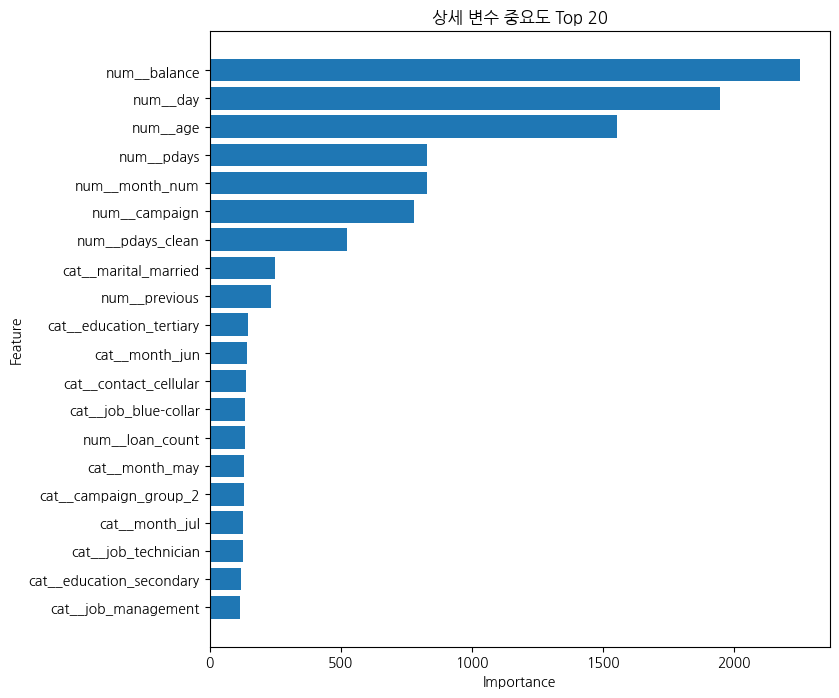

In [ ]:
top_feature_df = feature_importance_df.head(20).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 8))
plt.barh(top_feature_df['feature'], top_feature_df['importance'])
plt.title('상세 변수 중요도 Top 20')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

- 상위 변수는 balance, day, age, pdays, month_num, campaign 등이다.  
- 즉, 잔고, 연락 시점, 나이, 과거 캠페인 이력, 이번 캠페인 접촉 횟수가 예측에 큰 영향을 준 것으로 볼 수 있다.
- 특히 수치형 변수들이 상위에 많이 위치해 모델 예측에 큰 역할을 한 것으로 보인다.

**5-1-2. 원본 변수 단위 변수 중요도**

In [ ]:
raw_importance_rows = []

for raw_col in numeric_features + categorical_features:
    num_name = f'num__{raw_col}'
    cat_prefix = f'cat__{raw_col}_'

    matched = feature_importance_df[
        (feature_importance_df['feature'] == num_name) |
        (feature_importance_df['feature'].str.startswith(cat_prefix))
    ].copy()

    raw_importance_rows.append({
        'raw_feature': raw_col,
        'importance_sum': matched['importance'].sum(),
        'feature_count': len(matched)
    })

raw_importance_df = pd.DataFrame(raw_importance_rows)
raw_importance_df = raw_importance_df.sort_values('importance_sum', ascending=False).reset_index(drop=True)

display(raw_importance_df.head(20))

,raw_feature,importance_sum,feature_count
0,balance,2771,16
1,age,2243,17
2,day,1947,1
3,campaign,1201,12
4,month,1072,12
5,pdays,893,7
6,month_num,829,1
7,job,749,12
8,pdays_clean,524,1
9,marital,469,3


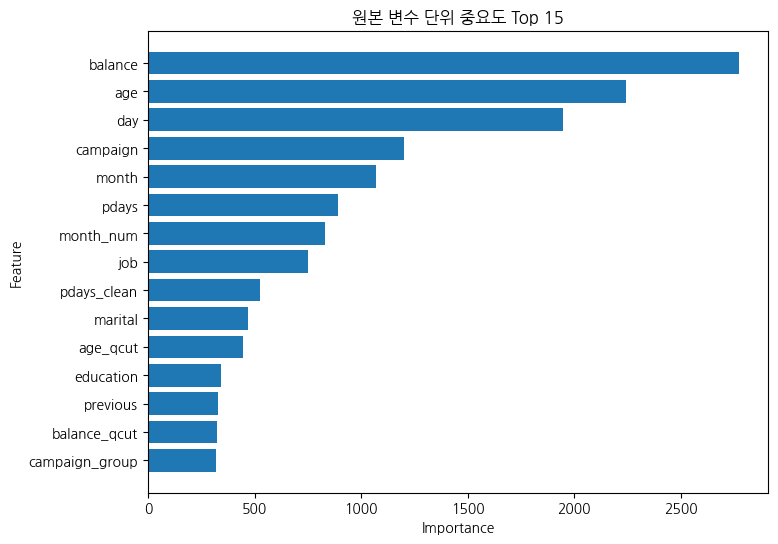

In [ ]:
top_raw_importance_df = raw_importance_df.head(15).sort_values('importance_sum', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_raw_importance_df['raw_feature'], top_raw_importance_df['importance_sum'])
plt.title('원본 변수 단위 중요도 Top 15')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

- 원본 변수 기준으로는 balance, age, day, campaign, month, pdays, job 등이 중요하게 나타났다.  
- EDA에서 확인한 캠페인 관련 변수와 고객 재무/인구통계 변수가 모델에서도 중요하게 쓰였음을 확인할 수 있다.

## 5-2. 실제값 vs 예측값 확인

In [ ]:
pred_check_df = X_test.copy()

pred_check_df['actual'] = y_test.values
pred_check_df['pred'] = final_pred
pred_check_df['pred_proba_yes'] = final_proba
pred_check_df['actual_label'] = pred_check_df['actual'].map({0: 'no', 1: 'yes'})
pred_check_df['pred_label'] = pred_check_df['pred'].map({0: 'no', 1: 'yes'})
pred_check_df['is_correct'] = pred_check_df['actual'] == pred_check_df['pred']

display(pred_check_df[['actual_label', 'pred_label', 'pred_proba_yes', 'is_correct']].head(20))

,actual_label,pred_label,pred_proba_yes,is_correct
41068,no,yes,0.501722,False
9197,no,no,0.060305,True
4127,no,no,0.097597,True
29861,no,no,0.210099,True
10271,no,no,0.126232,True
2789,no,no,0.056977,True
20614,yes,no,0.263200,False
23869,no,no,0.076985,True
24552,no,no,0.042360,True
22558,no,no,0.100963,True


In [ ]:
actual_pred_table = pd.crosstab(
    pred_check_df['actual_label'],
    pred_check_df['pred_label'],
    rownames=['Actual'],
    colnames=['Predicted']
)

display(actual_pred_table)

Predicted,no,yes
Actual,,
no,11218,754
yes,840,747


- 실제 비가입자 11,972명 중 11,218명을 비가입자로 맞췄고 754명은 가입자로 잘못 예측했다.  
- 실제 가입자 1,587명 중 747명을 가입자로 맞췄고 840명은 놓쳤다.

In [ ]:
actual_pred_rate_table = pd.crosstab(
    pred_check_df['actual_label'],
    pred_check_df['pred_label'],
    normalize='index'
)

display(actual_pred_rate_table)

pred_label,no,yes
actual_label,,
no,0.937020,0.062980
yes,0.529301,0.470699


- 비가입자는 약 93.7%를 정확히 비가입자로 맞췄고, 가입자는 약 47.1%를 가입자로 맞췄다.  
- 가입자의 절반 이상을 놓치지만, 불균형 데이터에서 Accuracy를 유지하면서 가입자 탐지를 개선한 결과로 볼 수 있다.

## 5-3. 예측 오차 확인

In [ ]:
error_df = pred_check_df[pred_check_df['is_correct'] == False].copy()

def get_error_type(row):
    if row['actual'] == 1 and row['pred'] == 0:
        return 'False Negative'
    elif row['actual'] == 0 and row['pred'] == 1:
        return 'False Positive'
    else:
        return 'Correct'

error_df['error_type'] = error_df.apply(get_error_type, axis=1)

print('전체 테스트 데이터 수:', len(pred_check_df))
print('오분류 데이터 수:', len(error_df))
print('오분류율:', round(len(error_df) / len(pred_check_df), 4))

display(error_df['error_type'].value_counts())

전체 테스트 데이터 수: 13559
오분류 데이터 수: 1594
오분류율: 0.1176


,count
error_type,
False Negative,840
False Positive,754


- 전체 테스트 데이터 13,559건 중 오분류는 1,594건이며 오분류율은 약 11.8%이다.  
- False Negative는 840건, False Positive는 754건으로 가입자를 놓친 오류가 조금 더 많다.

In [ ]:
error_type_df = error_df['error_type'].value_counts().reset_index()
error_type_df.columns = ['error_type', 'count']
error_type_df['ratio'] = error_type_df['count'] / len(error_df)

display(error_type_df)

,error_type,count,ratio
0,False Negative,840,0.526976
1,False Positive,754,0.473024


- 오분류 중 False Negative가 약 52.7%, False Positive가 약 47.3%이다.  
- 즉, 현재 모델의 오류는 두 유형이 비교적 비슷하지만, 가입자를 놓치는 문제가 조금 더 크다.

## 5-4. 오차 분포 시각화

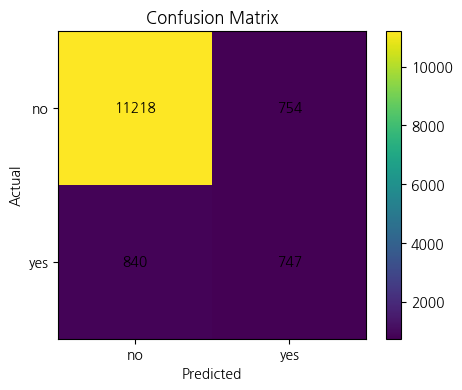

In [ ]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['no', 'yes'])
plt.yticks([0, 1], ['no', 'yes'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

- 모델이 비가입자는 매우 잘 맞추지만, 가입자는 여전히 일부 놓친다.  

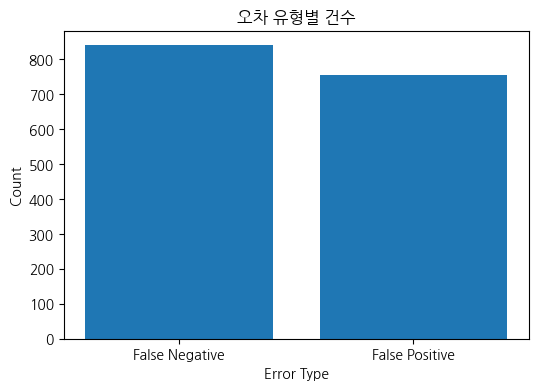

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(error_type_df['error_type'], error_type_df['count'])
plt.title('오차 유형별 건수')
plt.xlabel('Error Type')
plt.ylabel('Count')
plt.show()

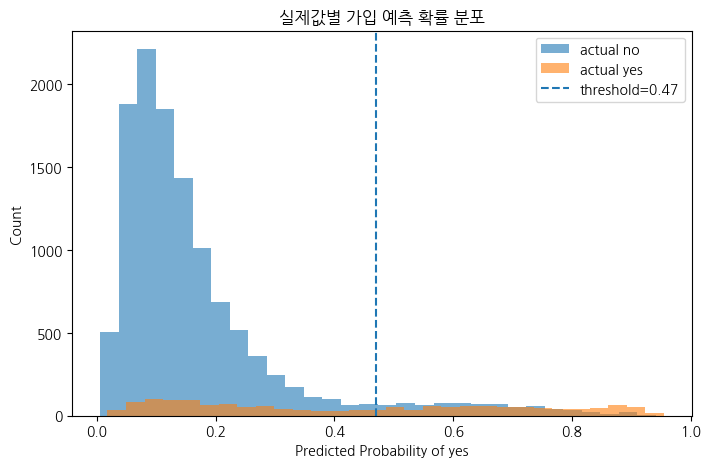

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(pred_check_df[pred_check_df['actual'] == 0]['pred_proba_yes'], bins=30, alpha=0.6, label='actual no')
plt.hist(pred_check_df[pred_check_df['actual'] == 1]['pred_proba_yes'], bins=30, alpha=0.6, label='actual yes')
plt.axvline(final_threshold, linestyle='--', label=f'threshold={final_threshold:.2f}')
plt.title('실제값별 가입 예측 확률 분포')
plt.xlabel('Predicted Probability of yes')
plt.ylabel('Count')
plt.legend()
plt.show()

## 5-5. 실제값 대비 오차 확인

In [ ]:
actual_error_summary = pred_check_df.groupby('actual_label').agg(
    total_count=('actual_label', 'count'),
    correct_count=('is_correct', 'sum'),
    avg_proba_yes=('pred_proba_yes', 'mean')
).reset_index()

actual_error_summary['error_count'] = actual_error_summary['total_count'] - actual_error_summary['correct_count']
actual_error_summary['accuracy_by_actual'] = actual_error_summary['correct_count'] / actual_error_summary['total_count']
actual_error_summary['error_rate_by_actual'] = actual_error_summary['error_count'] / actual_error_summary['total_count']

display(actual_error_summary)

,actual_label,total_count,correct_count,avg_proba_yes,error_count,accuracy_by_actual,error_rate_by_actual
0,no,11972,11218,0.168490,754,0.937020,0.062980
1,yes,1587,747,0.439319,840,0.470699,0.529301


- 비가입자 클래스 정확도는 약 93.7%로 높지만, 가입자 클래스 정확도는 약 47.1%이다.  
- 모델이 비가입자를 훨씬 안정적으로 예측하며, 가입자 탐지는 상대적으로 어려운 문제임을 확인할 수 있다.

In [ ]:
yes_actual_df = pred_check_df[pred_check_df['actual'] == 1].copy()

yes_miss_count = ((yes_actual_df['actual'] == 1) & (yes_actual_df['pred'] == 0)).sum()
yes_total_count = len(yes_actual_df)

print('실제 가입자 수:', yes_total_count)
print('가입자 중 놓친 수:', yes_miss_count)
print('가입자 미탐지율:', round(yes_miss_count / yes_total_count, 4))
print('가입자 탐지율:', round(1 - yes_miss_count / yes_total_count, 4))

실제 가입자 수: 1587
가입자 중 놓친 수: 840
가입자 미탐지율: 0.5293
가입자 탐지율: 0.4707


- 실제 가입자 1,587명 중 840명을 놓쳤고, 가입자 미탐지율은 약 52.9%이다.  
- 반대로 가입자 탐지율은 약 47.1%로, 최종 모델이 가입자의 절반 가까이를 잡아냈다고 볼 수 있다.

In [ ]:
no_actual_df = pred_check_df[pred_check_df['actual'] == 0].copy()

no_false_alarm_count = ((no_actual_df['actual'] == 0) & (no_actual_df['pred'] == 1)).sum()
no_total_count = len(no_actual_df)

print('실제 비가입자 수:', no_total_count)
print('비가입자 중 가입자로 잘못 예측한 수:', no_false_alarm_count)
print('비가입자 오탐율:', round(no_false_alarm_count / no_total_count, 4))

실제 비가입자 수: 11972
비가입자 중 가입자로 잘못 예측한 수: 754
비가입자 오탐율: 0.063


- 실제 비가입자 11,972명 중 754명을 가입자로 잘못 예측했으며, 비가입자 오탐율은 약 6.3%이다.  
- 즉, 비가입자에게 불필요하게 가입 가능성이 높다고 판단한 비율은 비교적 낮다.

## 5-6. 오차가 큰 데이터 확인

In [ ]:
pred_check_df['pred_confidence'] = pred_check_df['pred_proba_yes'].apply(
    lambda x: x if x >= final_threshold else 1 - x
)

error_df = pred_check_df[pred_check_df['is_correct'] == False].copy()

error_df['error_type'] = error_df.apply(get_error_type, axis=1)
error_df['pred_confidence'] = error_df['pred_proba_yes'].apply(
    lambda x: x if x >= final_threshold else 1 - x
)

high_conf_error_df = error_df.sort_values('pred_confidence', ascending=False)

display(
    high_conf_error_df[
        ['actual_label', 'pred_label', 'pred_proba_yes', 'pred_confidence', 'error_type',
         'age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
         'contact', 'campaign', 'pdays', 'previous', 'poutcome']
    ].head(20)
)

,actual_label,pred_label,pred_proba_yes,pred_confidence,error_type,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome
2053,yes,no,0.017995,0.982005,False Negative,45,blue-collar,married,primary,101,yes,no,unknown,5,-1,0,unknown
26910,yes,no,0.023211,0.976789,False Negative,50,blue-collar,married,primary,12519,yes,no,cellular,3,34,1,failure
28204,yes,no,0.028201,0.971799,False Negative,53,blue-collar,married,primary,-462,no,no,cellular,1,-1,0,unknown
38709,yes,no,0.030106,0.969894,False Negative,35,blue-collar,married,secondary,205,yes,yes,cellular,7,312,1,failure
37740,yes,no,0.030644,0.969356,False Negative,41,blue-collar,married,secondary,580,yes,no,cellular,1,363,1,failure
3323,yes,no,0.030979,0.969021,False Negative,49,unknown,married,primary,341,yes,yes,unknown,2,-1,0,unknown
39235,yes,no,0.033034,0.966966,False Negative,34,blue-collar,married,primary,-1,yes,no,cellular,6,355,1,other
168,yes,no,0.034943,0.965057,False Negative,54,admin.,married,tertiary,184,no,no,unknown,2,-1,0,unknown
6003,yes,no,0.035414,0.964586,False Negative,59,services,married,secondary,-22,yes,no,unknown,3,-1,0,unknown
8758,yes,no,0.039984,0.960016,False Negative,38,blue-collar,married,primary,5839,yes,no,unknown,2,-1,0,unknown


In [ ]:
false_negative_df = error_df[error_df['error_type'] == 'False Negative'].copy()

display(
    false_negative_df[
        ['actual_label', 'pred_label', 'pred_proba_yes',
         'age', 'job', 'marital', 'education', 'balance',
         'housing', 'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome']
    ].sort_values('pred_proba_yes').head(20)
)

,actual_label,pred_label,pred_proba_yes,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome
2053,yes,no,0.017995,45,blue-collar,married,primary,101,yes,no,unknown,5,-1,0,unknown
26910,yes,no,0.023211,50,blue-collar,married,primary,12519,yes,no,cellular,3,34,1,failure
28204,yes,no,0.028201,53,blue-collar,married,primary,-462,no,no,cellular,1,-1,0,unknown
38709,yes,no,0.030106,35,blue-collar,married,secondary,205,yes,yes,cellular,7,312,1,failure
37740,yes,no,0.030644,41,blue-collar,married,secondary,580,yes,no,cellular,1,363,1,failure
3323,yes,no,0.030979,49,unknown,married,primary,341,yes,yes,unknown,2,-1,0,unknown
39235,yes,no,0.033034,34,blue-collar,married,primary,-1,yes,no,cellular,6,355,1,other
168,yes,no,0.034943,54,admin.,married,tertiary,184,no,no,unknown,2,-1,0,unknown
6003,yes,no,0.035414,59,services,married,secondary,-22,yes,no,unknown,3,-1,0,unknown
8758,yes,no,0.039984,38,blue-collar,married,primary,5839,yes,no,unknown,2,-1,0,unknown


In [ ]:
false_positive_df = error_df[error_df['error_type'] == 'False Positive'].copy()

display(
    false_positive_df[
        ['actual_label', 'pred_label', 'pred_proba_yes',
         'age', 'job', 'marital', 'education', 'balance',
         'housing', 'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome']
    ].sort_values('pred_proba_yes', ascending=False).head(20)
)

,actual_label,pred_label,pred_proba_yes,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome
42253,no,yes,0.940894,46,management,married,tertiary,2671,no,no,cellular,3,91,4,success
44496,no,yes,0.940433,55,technician,married,secondary,10185,no,no,cellular,1,180,4,success
43257,no,yes,0.916087,79,retired,married,primary,3025,no,no,telephone,1,90,6,success
44067,no,yes,0.916025,29,management,single,unknown,560,no,no,cellular,1,92,2,success
43916,no,yes,0.912625,27,management,single,tertiary,2786,no,no,cellular,2,377,3,success
45082,no,yes,0.911104,44,technician,single,unknown,11115,no,no,cellular,1,185,4,success
43006,no,yes,0.907318,36,blue-collar,divorced,secondary,2843,no,no,cellular,1,182,1,success
40612,no,yes,0.905850,47,management,married,tertiary,699,no,no,cellular,3,97,2,success
42470,no,yes,0.903132,41,self-employed,single,tertiary,10346,no,no,cellular,1,182,3,success
44977,no,yes,0.902893,43,admin.,single,secondary,386,no,no,cellular,1,92,4,success


**그룹별 오차 패턴 확인**

In [ ]:
def error_rate_by_group(df, group_col):
    temp = df.groupby(group_col).agg(
        total_count=(group_col, 'count'),
        error_count=('is_correct', lambda x: (~x).sum()),
        avg_proba_yes=('pred_proba_yes', 'mean')
    ).reset_index()

    temp['error_rate'] = temp['error_count'] / temp['total_count']
    return temp.sort_values(['error_rate', 'total_count'], ascending=False)

- 특정 그룹별로 전체 건수, 오분류 건수, 평균 가입 예측 확률, 오분류율을 계산하는 함수를 정의한다.

In [ ]:
check_cols = [
    'job', 'marital', 'education', 'contact', 'poutcome',
    'age_group', 'balance_group', 'campaign_group', 'pdays_group',
    'previous_group', 'housing', 'loan', 'month'
]

for col in check_cols:
    if col in pred_check_df.columns:
        print(f'\n[{col}] 그룹별 오차율')
        display(error_rate_by_group(pred_check_df, col).head(10))


[job] 그룹별 오차율


,job,total_count,error_count,avg_proba_yes,error_rate
8,student,306,95,0.404263,0.310458
5,retired,696,179,0.336017,0.257184
10,unemployed,345,57,0.242262,0.165217
4,management,2865,385,0.225783,0.134380
6,self-employed,484,62,0.206338,0.128099
0,admin.,1532,194,0.206196,0.126632
11,unknown,72,9,0.186787,0.125000
9,technician,2325,243,0.201223,0.104516
3,housemaid,337,30,0.153058,0.089021
2,entrepreneur,454,37,0.163105,0.081498



[marital] 그룹별 오차율


,marital,total_count,error_count,avg_proba_yes,error_rate
2,single,3837,593,0.256012,0.154548
0,divorced,1542,167,0.198285,0.108301
1,married,8180,834,0.174363,0.101956



[education] 그룹별 오차율


...

,housing,total_count,error_count,avg_proba_yes,error_rate
0,no,6122,1041,0.269413,0.170042
1,yes,7437,553,0.143205,0.074358



[loan] 그룹별 오차율


,loan,total_count,error_count,avg_proba_yes,error_rate
0,no,11394,1455,0.212595,0.127699
1,yes,2165,139,0.134896,0.064203



[month] 그룹별 오차율


,month,total_count,error_count,avg_proba_yes,error_rate
2,dec,51,26,0.666380,0.509804
10,oct,208,89,0.598000,0.427885
7,mar,141,59,0.670886,0.418440
11,sep,199,76,0.594090,0.381910
0,apr,856,192,0.297544,0.224299
3,feb,825,127,0.271990,0.153939
6,jun,1625,201,0.173109,0.123692
1,aug,1866,203,0.202836,0.108789
4,jan,420,45,0.191045,0.107143
9,nov,1209,120,0.178018,0.099256


In [ ]:
def false_negative_rate_by_group(df, group_col):
    yes_df = df[df['actual'] == 1].copy()

    temp = yes_df.groupby(group_col).agg(
        actual_yes_count=(group_col, 'count'),
        missed_yes_count=('pred', lambda x: (x == 0).sum()),
        avg_proba_yes=('pred_proba_yes', 'mean')
    ).reset_index()

    temp['false_negative_rate'] = temp['missed_yes_count'] / temp['actual_yes_count']
    return temp.sort_values(['false_negative_rate', 'actual_yes_count'], ascending=False)

for col in check_cols:
    if col in pred_check_df.columns:
        print(f'\n[{col}] 실제 가입자 미탐지율')
        display(false_negative_rate_by_group(pred_check_df, col).head(10))


[job] 실제 가입자 미탐지율


,job,actual_yes_count,missed_yes_count,avg_proba_yes,false_negative_rate
1,blue-collar,221,163,0.311926,0.737557
2,entrepreneur,35,23,0.346709,0.657143
3,housemaid,36,22,0.396746,0.611111
7,services,102,62,0.387174,0.607843
10,unemployed,58,32,0.440541,0.551724
0,admin.,177,94,0.444027,0.531073
9,technician,265,140,0.442071,0.528302
4,management,380,194,0.463750,0.510526
6,self-employed,61,31,0.416463,0.508197
11,unknown,7,3,0.510969,0.428571



[marital] 실제 가입자 미탐지율


,marital,actual_yes_count,missed_yes_count,avg_proba_yes,false_negative_rate
0,divorced,178,107,0.393753,0.601124
1,married,871,471,0.429457,0.540758
2,single,538,262,0.470359,0.486989



[education] 실제 가입자 미탐지율


...

,housing,actual_yes_count,missed_yes_count,avg_proba_yes,false_negative_rate
1,yes,564,430,0.294751,0.762411
0,no,1023,410,0.519021,0.400782



[loan] 실제 가입자 미탐지율


,loan,actual_yes_count,missed_yes_count,avg_proba_yes,false_negative_rate
1,yes,131,106,0.261044,0.809160
0,no,1456,734,0.455358,0.504121



[month] 실제 가입자 미탐지율


,month,actual_yes_count,missed_yes_count,avg_proba_yes,false_negative_rate
8,may,291,230,0.285062,0.790378
5,jul,170,126,0.335595,0.741176
1,aug,201,138,0.383930,0.686567
9,nov,126,81,0.370210,0.642857
6,jun,162,84,0.397604,0.518519
4,jan,39,18,0.444378,0.461538
3,feb,128,58,0.525913,0.453125
0,apr,175,71,0.496018,0.405714
2,dec,23,3,0.662963,0.130435
11,sep,98,12,0.674605,0.122449


- blue-collar, entrepreneur, housemaid 등 일부 직업군에서 실제 가입자를 놓치는 비율이 높게 나타난다.

## 5-7. 최종 결과 요약

In [ ]:
final_summary = pd.DataFrame({
    '항목': [
        '최종 모델',
        '불균형 처리 방식',
        'Threshold',
        'Accuracy',
        '가입자 Precision',
        '가입자 Recall',
        '가입자 F1-score',
        '비가입자 F1-score',
        '심화 기준 충족 여부'
    ],
    '값': [
        'LightGBM Weight + Threshold',
        f'class_weight={{0: 1, 1: {best_lgbm_weight}}}',
        round(final_threshold, 3),
        round(final_score['accuracy'], 4),
        round(final_score['yes_precision'], 4),
        round(final_score['yes_recall'], 4),
        round(final_score['f1_yes'], 4),
        round(final_score['f1_no'], 4),
        '충족' if (final_score['accuracy'] >= 0.88 and final_score['f1_yes'] >= 0.45) else '미충족'
    ]
})

display(final_summary)

,항목,값
0,최종 모델,LightGBM Weight + Threshold
1,불균형 처리 방식,"class_weight={0: 1, 1: 2.5}"
2,Threshold,0.47
3,Accuracy,0.8824
4,가입자 Precision,0.4977
5,가입자 Recall,0.4707
6,가입자 F1-score,0.4838
7,비가입자 F1-score,0.9337
8,심화 기준 충족 여부,충족
